## ASR Tutorial with SLR80 Dataset

**Prepared by:** Ye Kyaw Thu, Language Understanding Lab., Myanmar  
**Last Updated Date:** 10 June 2026  
*For AI Engineering (Fundamental) class students*  

In [1]:
%pwd

'/mnt/disk1/ye/exp/asr_tts_SLR80'

In [3]:
!cat download_dataset.sh

#!/bin/bash

mkdir -p ./data/slr80/wavs
cd ./data/slr80

# Download TSV manifest
wget https://www.openslr.org/resources/80/line_index_female.tsv

# Download audio (948 MB)
wget https://www.openslr.org/resources/80/my_mm_female.zip
unzip my_mm_female.zip
# Audio files land in  ./wavs/  automatically


## Download SLR80 Dataset

In [5]:
!time ./download_dataset.sh

--2026-06-09 08:31:44--  https://www.openslr.org/resources/80/line_index_female.tsv
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 541101 (528K) [text/tab-separated-values]
Saving to: ‘line_index_female.tsv’

line_index_female.t 100%[===================>] 528.42K   444KB/s    in 1.2s    

2026-06-09 08:31:46 (444 KB/s) - ‘line_index_female.tsv’ saved [541101/541101]

--2026-06-09 08:31:46--  https://www.openslr.org/resources/80/my_mm_female.zip
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 948181015 (904M) [application/zip]
Saving to: ‘my_mm_female.zip’

my_mm_female.zip    100%[===================>] 904.26M  13.5MB/s    in 69s     

2026-06-09 08:32:56 (13.1 MB/s) - ‘my_mm_female.zip’ save

## Install Python dependencies

In [6]:
!time pip install -r requirements.txt

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [7]:
!time pip install -r requirements.txt --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.4.1 which is incompatible.
sentence-transformers 5.0.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.7.0 which is incompatible.

real	0m2.323s
user	0m0.844s
sys	0m0.066s


## Verify Installation

In [23]:
!python myanmar_asr.py --check_deps

2026-06-09 18:52:19  [INFO    ]  Myanmar ASR Tutorial  —  SLR80 Burmese Speech Corpus
2026-06-09 18:52:19  [INFO    ]  Checking dependencies ...
2026-06-09 18:52:39  [INFO    ]  TensorFlow version 2.19.0 available.
2026-06-09 18:52:39  [INFO    ]  All dependencies satisfied ✓


In [24]:
!python myanmar_tts.py --check_deps

2026-06-09 18:52:49  [INFO    ]  Myanmar TTS Tutorial  —  SLR80 Burmese Speech Corpus
2026-06-09 18:52:49  [INFO    ]  Checking dependencies ...
2026-06-09 18:52:50  [INFO    ]  All dependencies satisfied ✓


## Verify Data Folder

In [25]:
!tree ./data/ | head -n 30

./data/
└── slr80
    ├── bur_0366_0045318711.wav
    ├── bur_0366_0096392289.wav
    ├── bur_0366_0178258874.wav
    ├── bur_0366_0235517782.wav
    ├── bur_0366_0432235369.wav
    ├── bur_0366_0445549145.wav
    ├── bur_0366_0446483510.wav
    ├── bur_0366_0469985799.wav
    ├── bur_0366_0476333076.wav
    ├── bur_0366_0627382718.wav
    ├── bur_0366_0703709004.wav
    ├── bur_0366_0704688929.wav
    ├── bur_0366_1036375267.wav
    ├── bur_0366_1097534424.wav
    ├── bur_0366_1144117715.wav
    ├── bur_0366_1164293966.wav
    ├── bur_0366_1226374978.wav
    ├── bur_0366_1255274707.wav
    ├── bur_0366_1492243214.wav
    ├── bur_0366_1619909007.wav
    ├── bur_0366_1646531960.wav
    ├── bur_0366_1823369788.wav
    ├── bur_0366_1911642006.wav
    ├── bur_0366_2002523206.wav
    ├── bur_0366_2104254986.wav
    ├── bur_0366_2141001583.wav
    ├── bur_0366_2324179810.wav
    ├── bur_0366_2373091322.wav


## Steps 

လုပ်ဆောင်သွားရမယ့် အဆင့်တွေက အောက်ပါအတိုင်းပါ။  

# Step 1: Prep (this will now correctly find your flat .wav files)
python myanmar_asr.py --stage prep --data_dir ./data/slr80 --output_dir ./asr_output

# Verify JSON is non-empty before training
head -c 200 ./asr_output/train.json

# Step 2: Train on your RTX 3090 Ti
python myanmar_asr.py --stage train \
  --output_dir ./asr_output \
  --epochs 20 --lr 1e-4 --batch_size 8 --grad_accum 2 --fp16 \
  --early_stop_patience 3

# Or run all stages at once
python myanmar_asr.py --stage all --data_dir ./data/slr80 --output_dir ./asr_output \
  --epochs 20 --lr 1e-4 --batch_size 8 --fp16



## Step-1: Data Preparation for ASR

In [33]:
!time python myanmar_asr.py --stage prep \
  --data_dir  ./data/slr80 \
  --output_dir ./asr_output \
  --train_ratio 0.80 \
  --dev_ratio   0.10

2026-06-09 19:14:46  [INFO    ]  Myanmar ASR Tutorial  —  SLR80 Burmese Speech Corpus
2026-06-09 19:14:46  [INFO    ]  Stage: prep   Seed: 42
2026-06-09 19:14:47  [INFO    ]  ── Stage: Data Preparation ─────────────────────────────
2026-06-09 19:14:47  [INFO    ]  Audio found flat in: data/slr80/  (2530 wav files)
2026-06-09 19:14:47  [INFO    ]  TSV parse: 2530 valid  (0 missing audio, 0 malformed lines)
2026-06-09 19:14:47  [INFO    ]    train:  2024 utterances  →  asr_output/train.json
2026-06-09 19:14:47  [INFO    ]    dev  :   253 utterances  →  asr_output/dev.json
2026-06-09 19:14:47  [INFO    ]    test :   253 utterances  →  asr_output/test.json
2026-06-09 19:14:47  [INFO    ]  Myanmar vocab: 64 tokens  →  asr_output/myanmar_vocab.json
  (includes [PAD]=0, [UNK]=1, | =word-boundary, + 61 unique characters)
2026-06-09 19:14:47  [INFO    ]  Data preparation complete.
2026-06-09 19:14:47  [INFO    ]  All stages complete.

real	0m1.010s
user	0m3.272s
sys	0m0.163s


## Check Index Files  

SLR80 dataset ထဲမှာပါတဲ့ index ဖိုင်တွေကို အရင်ဆုံး လေ့လာကြည့်ရအောင်။  

In [21]:
!head ./data/slr80/line_index_female.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


In [22]:
!head ./data/slr80/line_index.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


### Check the asr_output Folder  

အထက်က run ထားတဲ့ python command က တကယ်တမ်း အဆင်ပြေပြေနဲ့ အလုပ်လုပ်သွားသလား ဆိုတာကို confirmation လုပ်ကြရအောင်။  

In [34]:
!tree ./asr_output

./asr_output
├── dev.json
├── myanmar_vocab.json
├── test.json
└── train.json

1 directory, 4 files


In [35]:
!wc ./asr_output/*.json

  1266   4005  75398 ./asr_output/dev.json
    65    130    824 ./asr_output/myanmar_vocab.json
  1266   4043  76210 ./asr_output/test.json
 10121  32138 604549 ./asr_output/train.json
 12718  40316 756981 total


ပြင်ဆင်ပြီး ရလာတဲ့ json ဖိုင်တွေရဲ့ format ကို လေ့လာကြည့်ကြရအောင်။  

In [37]:
!head -n 30 ./asr_output/train.json 

[
  {
    "id": "bur_8266_7413365509",
    "wav": "data/slr80/bur_8266_7413365509.wav",
    "text": "ဥပမာ မိုးဟေကို ဆိုရင် ဆောင်းဟေကို နာမည် ကို ဆင်တူ ပေးထားတာမျိုး ပေါ့"
  },
  {
    "id": "bur_7865_2573585785",
    "wav": "data/slr80/bur_7865_2573585785.wav",
    "text": "ဒါပေမဲ့ ဒီ ကျောက် က ရာသက်ပန် မကုန်အောင် ထွက်နေမှာ မဟုတ်ဘူး"
  },
  {
    "id": "bur_5189_3215659791",
    "wav": "data/slr80/bur_5189_3215659791.wav",
    "text": "ကိုကျော်သူ မမေသန်းနု ဒေါ်အေးအေးသင်းတို့ ပါတယ်"
  },
  {
    "id": "bur_0644_5980380162",
    "wav": "data/slr80/bur_0644_5980380162.wav",
    "text": "အမှန်တော့ မှတ်တမ်း ကို ဖလင် နဲ့ ရိုက် ပြီး ပြတဲ့ ရုပ်ရှင် ပါ"
  },
  {
    "id": "bur_5932_9903725735",
    "wav": "data/slr80/bur_5932_9903725735.wav",
    "text": "ကျနော် က ကျော်ထွဋ်ဆွေတို့ ဂျောက်ဂျက်တို့ နဲ့တော့ သီချင်းတွေ ဆိုခဲ့တာ အောင်မြင်တယ်"
  },
  {
    "id": "bur_5932_6467856225",
    "wav": "data/slr80/bur_5932_6467856225.wav",
    "text": "ရုပ်ရှင်ကားကြီးတွေ ရိုက်ရင် ဖလင် က တအား ကုန်တယ်"


In [38]:
!head -n 30 ./asr_output/dev.json

[
  {
    "id": "bur_8266_0769213652",
    "wav": "data/slr80/bur_8266_0769213652.wav",
    "text": "ဂိုက်ပဲ့ လို့ မယူချင် ပေမယ့် သူတို့ ဇွတ်အတင်း ပြော တော့ ယူရတာပေါ့ ဗျာ"
  },
  {
    "id": "bur_5362_1624026876",
    "wav": "data/slr80/bur_5362_1624026876.wav",
    "text": "ကဏန်း ကို ခြင် က မည်သည့် နေရာ အား ကိုက်မည်နည်း ဟု မေးစရာ ရှိသည်"
  },
  {
    "id": "bur_0644_5910308187",
    "wav": "data/slr80/bur_0644_5910308187.wav",
    "text": "ကျနော် ရန်ကုန် ကနေ ထားဝယ် ကို ကားလမ်း ကနေ သွားကြည့်တဲ့ အခါ စုစုပေါင်း ဆယ့်ရှစ်နာရီ ကြာပါတယ်"
  },
  {
    "id": "bur_5932_2661985373",
    "wav": "data/slr80/bur_5932_2661985373.wav",
    "text": "မယ်တော် ဆေးခန်း ကို ဆစ်ဒနီ ငြိမ်းချမ်းရေး ဆုရှင် ဒေါက်တာ စင်သီယာမောင် ဦးစီး ဖွင့်လှစ်ထားခြင်း ဖြစ်သည်"
  },
  {
    "id": "bur_7543_4004069718",
    "wav": "data/slr80/bur_7543_4004069718.wav",
    "text": "မြန်မာ ဘောလုံးသမားတွေ ဟာ စိုးရိမ်စိတ် များလွန်းတာ ကြောင့် သရေကျသွားတာ ဖြစ်တယ် လို့ အကဲခတ်တွေ က ပြောပါတယ်"
  },
  {
    "id": "bur_5189_3234127984",
   

In [39]:
!head -n 30 ./asr_output/test.json

[
  {
    "id": "bur_8266_0671510151",
    "wav": "data/slr80/bur_8266_0671510151.wav",
    "text": "ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး"
  },
  {
    "id": "bur_4632_1346598943",
    "wav": "data/slr80/bur_4632_1346598943.wav",
    "text": "နောက်ပိုင်း ၌ စော်ဘွားများ ကိုယ်တိုင် အာဏာ စွန့်လိုက်ရသည့် အဖြစ်သို့ ရောက်ရှိခဲ့သည်"
  },
  {
    "id": "bur_5362_5005233013",
    "wav": "data/slr80/bur_5362_5005233013.wav",
    "text": "မှတ်ထားခဲ့ ပြီး ကျောင်း ပြန် ရောက် မှ အတွေးလေး ကို အခြေခံ ပြီး ရေးခဲ့တာ"
  },
  {
    "id": "bur_5189_6294156159",
    "wav": "data/slr80/bur_5189_6294156159.wav",
    "text": "ပြုပြင်ပြောင်းလဲရေး ဆိုတာ အပြော နဲ့တင် မပြီးပါဘူး"
  },
  {
    "id": "bur_0366_4012759492",
    "wav": "data/slr80/bur_0366_4012759492.wav",
    "text": "ကမ္ဘာ တိုက်ကြီး ခြောက်တိုက် မှ အသင်း ခုနစ်သင်း ၏ ပွဲစဉ်များ ကို မော်ရိုကို ရှိ မြို့နှစ်မြို့ တွင် ကျင်းပသွားမည် ဖြစ်သည်"
  },
  {
    "id": "bur_5362_7281857191",
    "wav": "data/slr80/bur_5362_7281857191.wav",
    "text

**Vocab ဖိုင်ကိုလည်း လေ့လာကြည့်ကြရအောင်**

In [41]:
!cat ./asr_output/myanmar_vocab.json

{
  "[PAD]": 0,
  "[UNK]": 1,
  "|": 2,
  "?": 3,
  "က": 4,
  "ခ": 5,
  "ဂ": 6,
  "ဃ": 7,
  "င": 8,
  "စ": 9,
  "ဆ": 10,
  "ဇ": 11,
  "ဈ": 12,
  "ဉ": 13,
  "ည": 14,
  "ဋ": 15,
  "ဌ": 16,
  "ဍ": 17,
  "ဏ": 18,
  "တ": 19,
  "ထ": 20,
  "ဒ": 21,
  "ဓ": 22,
  "န": 23,
  "ပ": 24,
  "ဖ": 25,
  "ဗ": 26,
  "ဘ": 27,
  "မ": 28,
  "ယ": 29,
  "ရ": 30,
  "လ": 31,
  "ဝ": 32,
  "သ": 33,
  "ဟ": 34,
  "ဠ": 35,
  "အ": 36,
  "ဤ": 37,
  "ဥ": 38,
  "ဦ": 39,
  "ဧ": 40,
  "ဩ": 41,
  "ါ": 42,
  "ာ": 43,
  "ိ": 44,
  "ီ": 45,
  "ု": 46,
  "ူ": 47,
  "ေ": 48,
  "ဲ": 49,
  "ံ": 50,
  "့": 51,
  "း": 52,
  "္": 53,
  "်": 54,
  "ျ": 55,
  "ြ": 56,
  "ွ": 57,
  "ှ": 58,
  "ဿ": 59,
  "၌": 60,
  "၍": 61,
  "၎": 62,
  "၏": 63
}

##  Step-2: Training (fine-tuning Wav2Vec2)

*Full training with GPU* ကို မလုပ်ခင်မှာ လက်ရှိ GPU က အားရဲ့လား၊ တစ်ယောက်ယောက်က သုံးနေသလား ဆိုတာကို confirmation လုပ်သင့်ပါတယ်။  

In [1]:
!nvidia-smi

Thu Jun 11 02:40:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090 Ti     Off |   00000000:01:00.0  On |                  Off |
|  0%   41C    P8             25W /  480W |      80MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Debugging

လက်ရှိ စက်ထဲက transformers version က မြင့်နေတာမို့ `processor.tokenizer.batch_decode` အပိုင်းမှာ error တက်နေတယ်။   

In [50]:
!cat ./fix_asr.py

# Fix 1: make_compute_metrics — robust decode that handles both old and new transformers
# Fix 2: make_ctc_collator — use feature_extractor.pad directly (more robust in 5.x)
# Fix 3: add --predict_with_generate=False hint, and log sample predictions each epoch

with open('myanmar_asr.py', encoding='utf-8') as f:
    src = f.read()

# ── Fix make_ctc_collator ────────────────────────────────────────────────────
old_collator = '''def make_ctc_collator(processor):
    """
    Pad variable-length input_values and labels in each batch.
    Labels are padded with -100 so that CTC loss ignores padding positions.
    """
    import torch

    def collate(features: List[Dict]) -> Dict:
        # ── Pad audio ──────────────────────────────────────────────────────
        inp_list = [{"input_values": f["input_values"]} for f in features]
        batch    = processor.pad(inp_list, padding=True, return_tensors="pt")

        # ── Pad labels  ────────────────────────────────────────────────────
    

In [53]:
!time python myanmar_asr.py --stage train \
  --output_dir ./asr_output \
  --model_name facebook/wav2vec2-base \
  --epochs 20 \
  --lr 1e-4 \
  --batch_size 8 \
  --grad_accum 2 \
  --fp16 \
  --early_stop_patience 5

2026-06-11 22:27:23  [INFO    ]  Myanmar ASR Tutorial  —  SLR80 Burmese Speech Corpus
2026-06-11 22:27:23  [INFO    ]  Stage: train   Seed: 42
2026-06-11 22:27:24  [INFO    ]  ── Stage: Training ─────────────────────────────────────
2026-06-11 22:27:26  [INFO    ]  TensorFlow version 2.19.0 available.
2026-06-11 22:27:26  [INFO    ]  Train: 2024  Dev: 253
2026-06-11 22:27:26  [INFO    ]  HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-06-11 22:27:26  [INFO    ]  HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-11 22:27:27  [INFO    ]  HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/preprocessor_config.json "HTTP/1.1 200 OK"
2026-06-11 22:27:27  [INFO    ]  Myanmar processor saved  →  asr_output/myanmar_processor
2026-06-11 22:27:

## Checking Model Folder

မော်ဒယ် ဆောက်ပြီးသွားတိုင်းမှာ တချက်တော့ ထွက်လာတဲ့ output folder ကို ဝင်ကြည့်တာ၊ မော်ဒယ်ဖိုင်တွေကို ဝင်ကြည့်တာ လုပ်ကြပါ။  

In [54]:
!tree ./asr_output/

./asr_output/
├── asr_eval_report.md
├── asr_test_results.json
├── best_model
│   ├── added_tokens.json
│   ├── config.json
│   ├── model.safetensors
│   ├── preprocessor_config.json
│   ├── processor_config.json
│   ├── tokenizer_config.json
│   ├── training_args.bin
│   └── vocab.json
├── checkpoints
│   ├── checkpoint-2286
│   │   ├── config.json
│   │   ├── model.safetensors
│   │   ├── optimizer.pt
│   │   ├── preprocessor_config.json
│   │   ├── rng_state.pth
│   │   ├── scaler.pt
│   │   ├── scheduler.pt
│   │   ├── trainer_state.json
│   │   └── training_args.bin
│   ├── checkpoint-2413
│   │   ├── config.json
│   │   ├── model.safetensors
│   │   ├── optimizer.pt
│   │   ├── preprocessor_config.json
│   │   ├── rng_state.pth
│   │   ├── scaler.pt
│   │   ├── scheduler.pt
│   │   ├── trainer_state.json
│   │   └── training_args.bin
│   └── checkpoint-2540
│       ├── config.json
│       ├── model.safetensors
│       ├── optimizer.pt
│       ├── preprocessor_config.json
│       

## Check Learning Curve

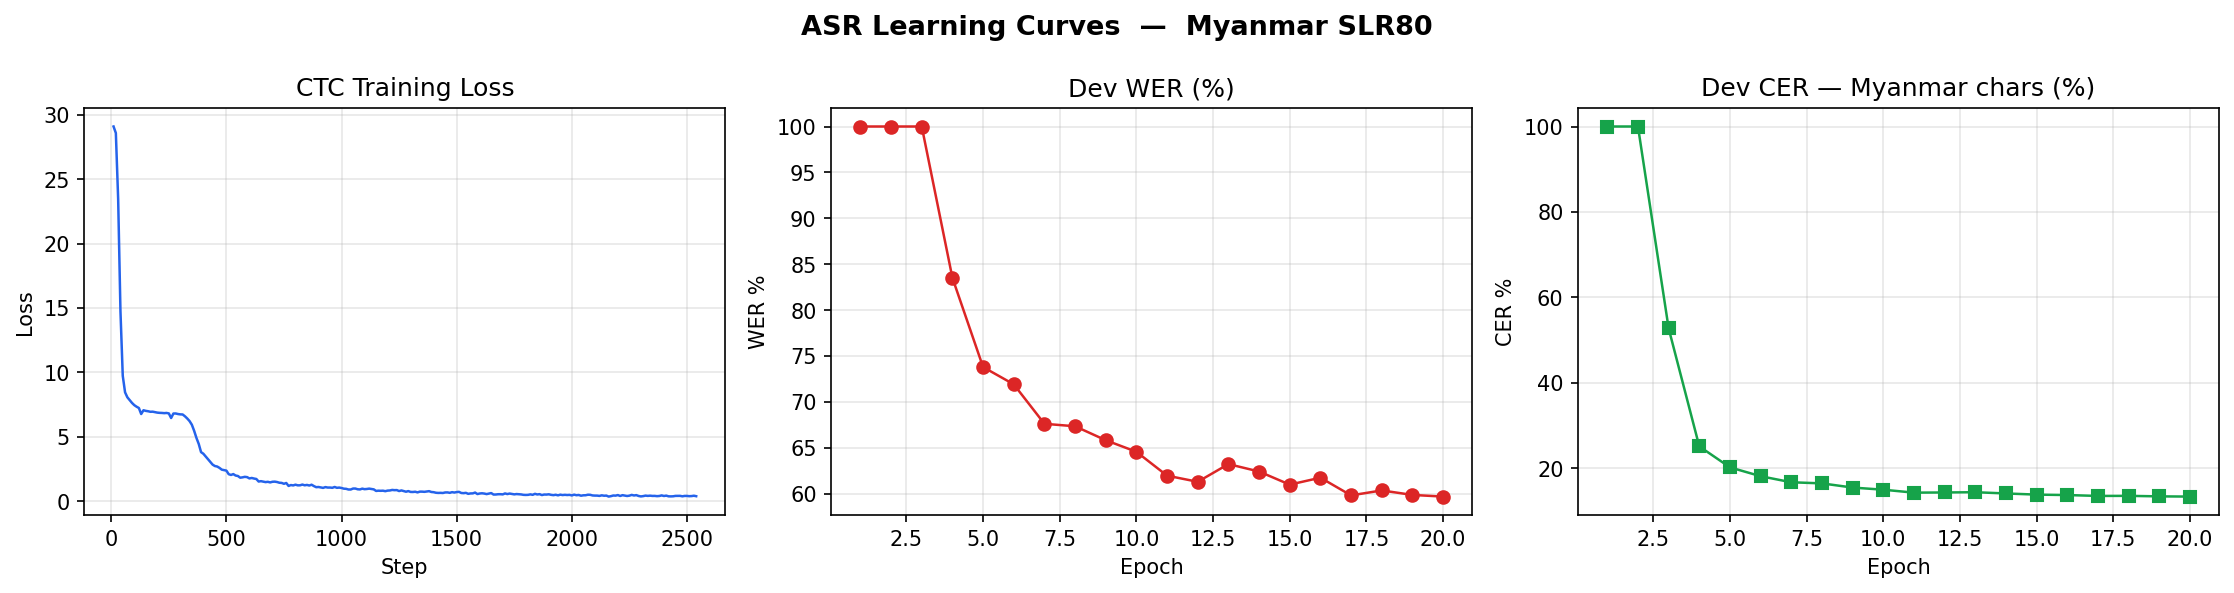

In [55]:
from IPython.display import Image

# Adjust size by setting the width (maintains aspect ratio if height is omitted)
Image(filename='./asr_output/learning_curve_asr.png', width=1200)

## Config File

In [56]:
!cat ./asr_output/best_model/config.json

{
  "activation_dropout": 0.0,
  "adapter_attn_dim": null,
  "adapter_kernel_size": 3,
  "adapter_stride": 2,
  "add_adapter": false,
  "apply_spec_augment": true,
  "architectures": [
    "Wav2Vec2ForCTC"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 1,
  "classifier_proj_size": 256,
  "codevector_dim": 256,
  "contrastive_logits_temperature": 0.1,
  "conv_bias": false,
  "conv_dim": [
    512,
    512,
    512,
    512,
    512,
    512,
    512
  ],
  "conv_kernel": [
    10,
    3,
    3,
    3,
    3,
    2,
    2
  ],
  "conv_stride": [
    5,
    2,
    2,
    2,
    2,
    2,
    2
  ],
  "ctc_loss_reduction": "mean",
  "ctc_zero_infinity": false,
  "diversity_loss_weight": 0.1,
  "do_stable_layer_norm": false,
  "dtype": "float32",
  "eos_token_id": 2,
  "feat_extract_activation": "gelu",
  "feat_extract_norm": "group",
  "feat_proj_dropout": 0.1,
  "feat_quantizer_dropout": 0.0,
  "final_dropout": 0.0,
  "freeze_feat_extract_train": true,
  "hidden_act": "gelu",
  "hidde

## Let's See Other Configuration Files

In [57]:
!cat ./asr_output/best_model/preprocessor_config.json

{
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}


In [58]:
!cat ./asr_output/best_model/tokenizer_config.json

{
  "added_tokens_decoder": {
    "0": {
      "content": "[PAD]",
      "lstrip": true,
      "normalized": false,
      "rstrip": true,
      "single_word": false,
      "special": false
    },
    "1": {
      "content": "[UNK]",
      "lstrip": true,
      "normalized": false,
      "rstrip": true,
      "single_word": false,
      "special": false
    },
    "2": {
      "content": "|",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "64": {
      "content": "<s>",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    },
    "65": {
      "content": "</s>",
      "lstrip": false,
      "normalized": false,
      "rstrip": false,
      "single_word": false,
      "special": true
    }
  },
  "backend": "custom",
  "bos_token": "<s>",
  "do_lower_case": false,
  "eos_token": "</s>",
  "model_max_length": 1000000000000000019884

In [59]:
!cat ./asr_output/best_model/added_tokens.json

{
  "</s>": 65,
  "<s>": 64
}


In [60]:
!cat ./asr_output/best_model/processor_config.json

{
  "feature_extractor": {
    "do_normalize": true,
    "feature_extractor_type": "Wav2Vec2FeatureExtractor",
    "feature_size": 1,
    "padding_side": "right",
    "padding_value": 0.0,
    "return_attention_mask": true,
    "sampling_rate": 16000
  },
  "processor_class": "Wav2Vec2Processor"
}


In [61]:
!cat ./asr_output/best_model/vocab.json

{
  "?": 3,
  "[PAD]": 0,
  "[UNK]": 1,
  "|": 2,
  "က": 4,
  "ခ": 5,
  "ဂ": 6,
  "ဃ": 7,
  "င": 8,
  "စ": 9,
  "ဆ": 10,
  "ဇ": 11,
  "ဈ": 12,
  "ဉ": 13,
  "ည": 14,
  "ဋ": 15,
  "ဌ": 16,
  "ဍ": 17,
  "ဏ": 18,
  "တ": 19,
  "ထ": 20,
  "ဒ": 21,
  "ဓ": 22,
  "န": 23,
  "ပ": 24,
  "ဖ": 25,
  "ဗ": 26,
  "ဘ": 27,
  "မ": 28,
  "ယ": 29,
  "ရ": 30,
  "လ": 31,
  "ဝ": 32,
  "သ": 33,
  "ဟ": 34,
  "ဠ": 35,
  "အ": 36,
  "ဤ": 37,
  "ဥ": 38,
  "ဦ": 39,
  "ဧ": 40,
  "ဩ": 41,
  "ါ": 42,
  "ာ": 43,
  "ိ": 44,
  "ီ": 45,
  "ု": 46,
  "ူ": 47,
  "ေ": 48,
  "ဲ": 49,
  "ံ": 50,
  "့": 51,
  "း": 52,
  "္": 53,
  "်": 54,
  "ျ": 55,
  "ြ": 56,
  "ွ": 57,
  "ှ": 58,
  "ဿ": 59,
  "၌": 60,
  "၍": 61,
  "၎": 62,
  "၏": 63
}


## Call --help

လက်ရှိ သုံးခဲ့တဲ့ myanmar_asr.py ကုဒ်ဗားရှင်းရဲ့ --help ကို ခေါ်ကြည့်ရအောင်။  

In [1]:
!python ./myanmar_asr.py --help

usage: myanmar_asr.py [-h] [--stage {prep,train,eval,all}] [--check_deps]
                      [--data_dir DATA_DIR] [--tsv_file TSV_FILE]
                      [--output_dir OUTPUT_DIR] [--train_ratio TRAIN_RATIO]
                      [--dev_ratio DEV_RATIO] [--max_samples MAX_SAMPLES]
                      [--max_duration MAX_DURATION] [--model_name MODEL_NAME]
                      [--freeze_feature_encoder] [--no_freeze_feature_encoder]
                      [--epochs EPOCHS] [--lr LR] [--batch_size BATCH_SIZE]
                      [--eval_batch_size EVAL_BATCH_SIZE]
                      [--grad_accum GRAD_ACCUM] [--warmup_ratio WARMUP_RATIO]
                      [--weight_decay WEIGHT_DECAY] [--fp16]
                      [--early_stop_patience EARLY_STOP_PATIENCE]
                      [--num_workers NUM_WORKERS] [--log_file LOG_FILE]
                      [--log_steps LOG_STEPS] [--tensorboard] [--verbose]
                      [--seed SEED]

Myanmar ASR tutorial — SLR80 + 

## Step-3: Evaluation

လက်ရှိ အချိန်ထိ ရခဲ့တဲ့ CER တန်ဖိုးတွေက validation dataset နဲ့ learn လုပ်သွားရင်းနဲ့ ရခဲ့တဲ့ ASR result ပါ။ Experiment အနေနဲ့ တကယ်တမ်း ပိုစိတ်ဝင်စားတဲ့ ရလဒ်ကတော့ training လုပ်စဉ်မှာ မပါတဲ့ (ဖယ်ထားခဲ့တဲ့) ဒေတာဖြစ်တဲ့ test data နဲ့ ASR လုပ်ကြည့်ပြီး ရလာတဲ့ ရလဒ်ပါ။  

In [63]:
%pwd

'/mnt/disk1/ye/exp/asr_tts_SLR80'

In [64]:
!time python myanmar_asr.py --stage eval --output_dir ./asr_output

2026-06-11 22:39:05  [INFO    ]  Myanmar ASR Tutorial  —  SLR80 Burmese Speech Corpus
2026-06-11 22:39:05  [INFO    ]  Stage: eval   Seed: 42
2026-06-11 22:39:05  [INFO    ]  ── Stage: Evaluation ───────────────────────────────────
2026-06-11 22:39:07  [INFO    ]  Loading model from asr_output/best_model
Loading weights: 100%|█████████████████████| 213/213 [00:00<00:00, 19893.71it/s]
2026-06-11 22:39:07  [INFO    ]  Device: cuda
2026-06-11 22:39:07  [INFO    ]  Evaluating on 253 test utterances ...
2026-06-11 22:39:09  [INFO    ]    Decoded 100/253 ...
2026-06-11 22:39:10  [INFO    ]    Decoded 200/253 ...
2026-06-11 22:39:11  [INFO    ]  Decoded 253  (0 failed)
2026-06-11 22:39:11  [INFO    ]  
2026-06-11 22:39:11  [INFO    ]  =================================================================
2026-06-11 22:39:11  [INFO    ]    ASR EVALUATION RESULTS  —  Myanmar SLR80 test set
2026-06-11 22:39:11  [INFO    ]  =================================================================
2026-06-11 2

## Let's Read the Evaluation Report

Testing ရလဒ်အနေနဲ့က CER = 13.83% မို့လို့ ကောင်းတယ်လို့ ပြောလို့ ရပါတယ်။  
အထက်မှာ မြင်ရတဲ့ အမှား ဥပမာတွေက Top-5 worst utterances by CER (အမှားတွေထဲကမှ အဆိုးရွားဆုံး ၅ခု) ကို ဆွဲထုတ်ပြထားတာပါ။  
Testing လုပ်ခဲ့တဲ့ စာကြောင်းတိုင်းအတွက် လက်ရှိ ဆောက်ထားတဲ့ ASR model က ဘယ်လိုအခြေအနေရှိသလဲ ဆိုတာကို အသေးစိတ် လေ့လာကြည့်ကြရအောင်ပါ။  

In [65]:
from IPython.display import display, Markdown

# Open and beautifully render your markdown file
with open("asr_output/asr_eval_report.md", "r", encoding="utf-8") as f:
    display(Markdown(f.read()))

# ASR Evaluation Report — Myanmar SLR80

## Results

| Metric | Value |
|--------|-------|
| **WER** | 58.19% |
| **CER (Myanmar)** | 13.29% |
| Test utterances decoded | 253 |
| Total words | 2,270 |
| Total characters | 17,808 |
| Substitutions | 1,172 |
| Deletions | 617 |
| Insertions | 578 |
| Failed decodes | 0 |

## Model
- Base checkpoint: `facebook/wav2vec2-base`
- Tokeniser: Custom Myanmar character vocabulary (built from training set)
- Fine-tuned on: SLR80 Myanmar Female Speech Corpus (CC BY-SA 4.0)

## Metric notes
- **CER** is the primary metric for Myanmar. Space usage is inconsistent
  in Myanmar text, so WER is less reliable.
- CER = (Substitutions + Deletions + Insertions) / Total reference characters
- "|" in hypotheses represents the word-boundary token (maps back to space).


## Let's Read the Whole Testing Result

In [66]:
!ls ./asr_output/asr_test_results.json -lh

-rw-rw-r-- 1 ye ye 132K Jun 11 22:39 ./asr_output/asr_test_results.json


In [67]:
import json
from IPython.display import JSON

# Load your JSON file
with open('./asr_output/asr_test_results.json', 'r') as f:
    data = json.load(f)

# Display as an interactive widget
JSON(data)

<IPython.core.display.JSON object>

## Printing Whole Test Result 

Interactive mode နဲ့ ကြည့်လို့ရကြောင်း အထက်မှာ လုပ်ပြခဲ့တာပါ။ ပုံမှန်အတိုင်း cat command နဲ့ ရိုက်ထုတ်ပြီး ကြည့်လည်း ရပါတယ်။ ဒါပေမဲ့ Jupyter Lab မှာက အရောင်ဘာညာနဲ့ ပြလို့ ရတာမို့ အောက်ပါအတိုင်း code ရေးပြီး ရိုက်ထုတ်ရင် ဖတ်ရတာ ပိုအဆင်ပြေတာပေါ့။ ASR error တွေကို အသေးစိတ် လေ့လာကြည့်ဖို့ တိုက်တွန်းပါတယ်။   


In [68]:
import json
from IPython.display import Markdown, display

# 1. Load the JSON file safely with UTF-8 encoding
with open('./asr_output/asr_test_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Convert to formatted string (CRITICAL: ensure_ascii=False)
# This keeps Myanmar text readable instead of converting it to \u1000 codes
pretty_json = json.dumps(data, indent=4, ensure_ascii=False)

# 3. Render as a syntax-highlighted Markdown code block
display(Markdown(f"```json\n{pretty_json}\n```"))

```json
{
    "summary": {
        "wer": {
            "wer": 0.5819,
            "wer_pct": 58.19,
            "total_words": 2270
        },
        "cer": {
            "cer": 0.1329,
            "cer_pct": 13.29,
            "total_chars": 17808,
            "substitutions": 1172,
            "deletions": 617,
            "insertions": 578
        },
        "n_decoded": 253,
        "n_failed": 0
    },
    "utterances": [
        {
            "id": "bur_3260_3575875839",
            "reference": "ကလေး ကလည်း စာအုပ်ထဲ မှာ မှင်နီရာ ဗရပွ နဲ့မို့ မျက်နှာလေး ငယ်လို့",
            "hypothesis": "ကလေး ကလည်း ဆောက်ထဲ မှာ မိစနေယာ ဘယ်တာပွား နဲ့ မှု့ မြန်နာလင်း နယ်လို့",
            "cer_pct": 39.06,
            "wer_pct": 77.78
        },
        {
            "id": "bur_7712_7875320422",
            "reference": "စန္ဒာကေတို့ အိုမီဂါတို့ လိုက် လုပ်ကြသည်",
            "hypothesis": "ရော စ်တာကေးတို့ ဝန်းမီ ကတို့ လိုက် လုပ်ကြသည်",
            "cer_pct": 35.9,
            "wer_pct": 100.0
        },
        {
            "id": "bur_9135_4649108338",
            "reference": "ကရင် ပြည်နယ် မှာတော့ နေရောင် မမြင်ရဘဲ အုံ့မှိုင်းတဲ့ ရာသီဥတု အပြင် မိုးရွာ ပြီး အရမ်း အေးနေတယ်",
            "hypothesis": "ကငရင်း ပြည်နယ် မာတော့ နေယောက် မမီ်းယ ပဲ အုမ်မိုင်းနေရာ သည်ဦုတု့ အမြင် မိုးရပြီး အရိုင်းအေးနေတယ်",
            "cer_pct": 34.04,
            "wer_pct": 91.67
        },
        {
            "id": "bur_0366_7564025797",
            "reference": "ထို အဆင့်များ ခွင့်ပြု လျှင် ပုံနှိပ်စက် တင် ၍ ပုံနှိပ်ရသည်",
            "hypothesis": "ဒဝိုစစ် များခွင့်ပြို ရျှင် ပုံနှိစ့်စပက်တင်တွေ ပုံနှစ့်ရသည်",
            "cer_pct": 33.9,
            "wer_pct": 100.0
        },
        {
            "id": "bur_0366_5222335298",
            "reference": "ကျုပ် တပည့်တွေ က ကျုပ် ကြိုက်တတ်မှန်း သိ လို့ ဝှိုက်လေဘယ် နဲ့ ကန်တော့နေကျ",
            "hypothesis": "ကျိုပတပေ့တွေ က ကျုပ် ကျိုက်တက်မှတ်သီ လို ဝိုက်လှေပဲ မြယ် ကတော့နေကျ",
            "cer_pct": 31.51,
            "wer_pct": 80.0
        },
        {
            "id": "bur_4632_2867701564",
            "reference": "အထူးသဖြင့် အဖြစ်ပျက်တွေ လူတွေ ရဲ့ နာမည်တွေ ကို မေ့တတ်ပါတယ်",
            "hypothesis": "အထိုးသဖြင့် အဖြစ်ပြစ် အတွေ့ လူတွေ ရဲ့နာမယ်တွေ ဝိေတ်တပ်ပါတယ်ော",
            "cer_pct": 31.03,
            "wer_pct": 100.0
        },
        {
            "id": "bur_5903_2679256085",
            "reference": "ကထိန် ၏ အဓိပ္ပာယ် မှာ မြဲမြဲခိုင်ခံ့ခြင်း ဟု ရပါသည်",
            "hypothesis": "ကထိန် ၏ေ ဒိပ် ဘဲ မှာ မြပ်းမြဲ ခိုင်ခံ့ကြေး ဟု ရပါသည်",
            "cer_pct": 29.41,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5903_6154152891",
            "reference": "ကဗျာ ပါ စကားလုံးတွေ က ရိုးရိုး ဗျည်း နှင့် ရိုးရိုး သရတွေ ချည်း",
            "hypothesis": "ကဗျာ ပာ စာကာလုံးတွေ က ယိေးရိုး ပြီး နှင့် ယွေးရိုး သာတတွေ ကြီး",
            "cer_pct": 28.57,
            "wer_pct": 70.0
        },
        {
            "id": "bur_6118_3583100525",
            "reference": "ကလေး ကို လည်ပင်းနာခြင်း သက်သာစေရန် ပလုတ်ကျင်းခိုင်းပါ",
            "hypothesis": "ကလေး ကို လယ်ဘင်းတာချဲ သတ်သာ စာရန် ပလုပ် ချင့်ခိုင်းပါ",
            "cer_pct": 28.3,
            "wer_pct": 100.0
        },
        {
            "id": "bur_9762_0622607604",
            "reference": "ကလေး က ရုပ်မြင်သံကြား ကြော်ငြာ တွင် ပြသသည့် ဂျေဒိုးနတ် ကို ပူဆာသည်",
            "hypothesis": "ကလေး က ရုပ်မြင်သန်ကြား ကြောင်းရာ တွင် ပြသားသည့် ချေတို့ နပ်ကိယ္ပူးစားသည်",
            "cer_pct": 27.27,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5903_5410633005",
            "reference": "ကုလား ဗမာ အဓိကရုဏ်းတွေ ရဲ့ အဆက် အဖြစ် ကော်သူလေး မွတ်စလင် လွတ်မြောက်ရေး တပ် ပေါ်ခဲ့တယ်",
            "hypothesis": "ကလားဘမ အဒီ ကရုံးတွေ ရဲ့ အစက် အဖြစ် ကော်သူလိန်း မှုတ် စလျင်း နွတ်မြောက် ရေး တတ်ပေါခဲ့တယ်",
            "cer_pct": 27.06,
            "wer_pct": 90.91
        },
        {
            "id": "bur_9135_4837224148",
            "reference": "နေ့စဉ် မှန်မှန် စားပေး ပါက အသားအရေ က ဖြည်းဖြည်းချင်း ပိုမို လှပလာပါလိမ့်မယ်",
            "hypothesis": "နေ့စင် မတ်မယ့် စားပစ်ပါက အသားရည် က ဖြည်းဖြီးချင်း ဖို့မှန လှဘါလာပါလိုမ့်မယ်",
            "cer_pct": 26.67,
            "wer_pct": 88.89
        },
        {
            "id": "bur_0366_9457406767",
            "reference": "ဆေးရုံ မှာ နေတုန်း က ကိုယ့်ဘာသာ ကိုယ့်လူနာ နဲ့ နပန်းလုံး ပို တောင် ပျော်သေး",
            "hypothesis": "ဆေးရုံဝါ နေ တုန်းက ကိုယ့် ဘာသာ ကိုယ့်လူန နှင့် နာပမ်း လုံး ပိုးတောင်း ပြောသည်",
            "cer_pct": 26.67,
            "wer_pct": 100.0
        },
        {
            "id": "bur_8698_1292184594",
            "reference": "မြင့်မြတ် အထဲ ဝင်သွားသည် နှင့် အသည်းအသန် ပါပဲ",
            "hypothesis": "မြင့်မြျက့် အထညဲးဝန်သွားသည် နှင့် အသဲး အသံ မါပဲ",
            "cer_pct": 26.67,
            "wer_pct": 100.0
        },
        {
            "id": "bur_4409_8854799992",
            "reference": "ထို အမယ်အို ၏ လက် ထဲ တွင် မုန့် အနည်းငယ် နှင့် ငှက်ပျောသီး ထည့်ထားသည့် ကြွပ်ကြွပ်အိတ်ထုတ်လေး ကို ကိုင်ထားသည်",
            "hypothesis": "ထိုအမည်ို ၏ လက်ထည်း တွင် ဘုန့် အနည်းငယ် နှင့် ငှပြောသိ့် ထည်ထား သည့် တူချု့အိတ်ထုတ်လညး ကို ကိုင်ထားသည်",
            "cer_pct": 25.0,
            "wer_pct": 64.29
        },
        {
            "id": "bur_7447_6269904644",
            "reference": "ရမ်ဆာ ရေတိမ် ဒေသ အဖြစ် မိုးယွန်းကြီး အင်း တောရိုင်း တိရစ္ဆာန် ဘေးမဲ့တော ကို သတ်မှတ်ခဲ့သည်",
            "hypothesis": "ရမ်ဆာရေ တိန်ဒေသ အဖြစ် မူးရွန်းကြီးအင် တော်ထမ်း တိေတ္စယ် ပေးမဲ့တောကို သတ်မှန်းခဲ့သည်",
            "cer_pct": 24.72,
            "wer_pct": 90.91
        },
        {
            "id": "bur_0644_8958691208",
            "reference": "သန်းရွှေ မသေသေးလို့ နေမှပေါ့ အချစ် တစ်ပွဲ စစ်ပွဲ တစ်ရာ",
            "hypothesis": "သန်းရွှေရာ မသေသေး လို့ နေမှာပေါ့ ရှစ်တပွဲ စစ်ပွဲတရာ",
            "cer_pct": 24.07,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7543_4216935346",
            "reference": "ကား စတေကာ ကမ်ပိန်း အတွက် ဖေ့စ်ဘွတ် မှ တစ်ဆင့် ဖိတ်ခေါ်မှုများ ပြုလုပ်ခဲ့သည်",
            "hypothesis": "ကားစ်တေကာ ကန်ပိန်း အတွက် ဖေ့ပွတ် မှာ တဆင့် အဖေ့ခုန်များ ပြုလုပ်ခဲ့သည်",
            "cer_pct": 24.0,
            "wer_pct": 77.78
        },
        {
            "id": "bur_8266_2116349035",
            "reference": "ကလေး က မုန့်စား ပြီးပြီးချင်း ပဲ ဗိုက်တွေ အရမ်း နာလာ လို့ ဆေးရုံ ကို အရေးပေါ် ပို့လိုက်ရတယ် တဲ့လေ",
            "hypothesis": "ကလေး က မုန့္ဆာပြီးပြီးချင်း မပိုက်တွေ အရမ်းနာလား လို့ စေးရင် ကို အရေးပေါ့် ပို လာရတယ်တယ် လေ",
            "cer_pct": 23.71,
            "wer_pct": 78.57
        },
        {
            "id": "bur_9135_0228958418",
            "reference": "မတ္တရာ မြို့နယ် ကြက် မွေးမြူရေး ခြံ တစ်ခု ၌ ယခင် သီတင်းပတ် က တွေ့ရစဉ် ဖြစ်သည်",
            "hypothesis": "မတ်တရာ မြို့နယ် ကျ်မေး မြည်ရေး ချန် တစ်ခု န ယခင် သတင်း မက္က တွေ့ရစင် ဖြစ်သည်",
            "cer_pct": 23.38,
            "wer_pct": 66.67
        },
        {
            "id": "bur_4409_4786417368",
            "reference": "ဆရာမောင်ဝဏ္ဏ နှင့် ဆရာသုမောင်တို့ ခုနှစ်စဉ် အလွမ်း အကယ်ဒမီ ထူးချွန်ဆု ရရှိသည်",
            "hypothesis": "ဆရာမဝမ္်တ နှင့် ဆရာသူ့မောင်တို့ ခဏပ်ဆင် အလွှမ်း အကယ်ဒမီ ထူးချွန်စို ရရှိသည်",
            "cer_pct": 23.38,
            "wer_pct": 62.5
        },
        {
            "id": "bur_5903_0142959833",
            "reference": "ထမင်းချိုင့် ကို လက် တဖက် က ဆွဲ တဖက် က လွယ်အိတ် ကို ဖိ ကိုင် ပြီး နံရံ မှာ မှီရပ် စီးနေတဲ့ လူငယ် တဦး ကို မေးကြည့်မိပါတယ်",
            "hypothesis": "ထမင်းညိုင့် ကို လက်ထပ်ဘက် က စွဲ တစ်ဖက် ကာ လွယ်ကို ဖြေကိုင် ပြီး နန်ရန် မား မှီရပ် စီးနေတဲ့ လူငယ့ တစ်ဦး ကို မေးကြည်းမိပါတယ်",
            "cer_pct": 23.33,
            "wer_pct": 71.43
        },
        {
            "id": "bur_3260_0486469440",
            "reference": "မန္တလေး ဆေးရုံကြီး မှာ ဒဏ်ရာရသူ တစ်ဦး မနေ့ည က အတွင်းလူနာ အဖြစ် ကုသမှု ခံယူနေရပါတယ်",
            "hypothesis": "မန္နလေး စတ်ယုံကြီး မှာ ဒန်ယာ ရသူ တစ်ဦး မနေညာ က အတွင်းလုနာ ဖြစ် ကိုးသားမှု ခံ့်ယူ နေရပါတယ်",
            "cer_pct": 23.17,
            "wer_pct": 90.91
        },
        {
            "id": "bur_3260_3574424458",
            "reference": "ဘာလို့လည်း ဆို အာဆီယံ ပွဲတော်တွေ တက်ရင် ဘရူနိုင်း နဲ့က မဆုံခဲ့ရဘူး",
            "hypothesis": "ဘာလို့လဲ ဆို အာစရန် ပွဲတော်တွေ တပ်ရင် ဘရူ နိုင်းနိင်း က မဆုံခဲ့ရဘူး",
            "cer_pct": 22.73,
            "wer_pct": 75.0
        },
        {
            "id": "bur_6884_2301767909",
            "reference": "မနက်ဖြန် ဘယ်လ်ဂျီယံ နဲ့ ကန်မယ့် အာဂျင်တီးနား ရဲ့ လီယွန်နယ်မက်ဆီ ပါ",
            "hypothesis": "မက်ပြန် ဘယ်ကြီ် ယ် နဲ့ ကန်မယ့် အာဂျင်တီးနား ရဲ့ လိ့်ယွန်နယ် မဆီပါ",
            "cer_pct": 22.73,
            "wer_pct": 62.5
        },
        {
            "id": "bur_9135_3939895939",
            "reference": "ရှပ်အင်္ကျီ နဲ့ ပုဂ္ဂိုလ် ကတော့ နာမည်ကြီး စာရေးဆရာ မောင်သော်က ပါပဲ",
            "hypothesis": "ရှက်အေနးနေ နဲ့ ပုတ္ကို ကတော့ နာမစ်ကြီး စာရေးဆရာ မောသောက ပါပဲ",
            "cer_pct": 22.73,
            "wer_pct": 50.0
        },
        {
            "id": "bur_6118_8725176532",
            "reference": "သံလွင် မြစ်ရေ မြင့်တက်လာတဲ့ အတွက် ဘားအံ နဲ့ ရွေဂွန် က မြစ်ကမ်း မြေနှိမ့်ပိုင်းတွေ မှာ ရေကြီးနေတယ်",
            "hypothesis": "သံပေမြည် မြင့်တက်လာတဲ့ အတွက် ဖက်အန်း တဲ့ ရွှေကုန် က မြစ်ကမ်း မြှေ်း နှိမ့်ပိုင်းတွေ မှာ ရေကြီးနေတယ်",
            "cer_pct": 22.68,
            "wer_pct": 58.33
        },
        {
            "id": "bur_0366_8886700590",
            "reference": "ကုန်းမြေ ဧရိယာ ခုနစ်ရာ့ ငါးဆယ် စတုရန်း ကီလိုမီတာ ပင် မပြည့်သော အပူပိုင်း ဒေသ မြို့နိုင်ဂံကလေး ၌ နေထိုင်သူ ငါး ဒသမ ငါး သန်း ရှိသည်",
            "hypothesis": "ကုမ်း မြိ အေရီးယာ ခုနှစ်ရပ့ ငါးဆယ် စ်တု ယိမ် ကီလိုမီတား ဘဲ မပြစ်သော အပူပိုင်း ဒေသ မြို့ နိုင်းခံ ကလေး န နေထိုင်သူ ငါး တာ္သမ ငါး သန်း ရှိသည်",
            "cer_pct": 22.48,
            "wer_pct": 77.78
        },
        {
            "id": "bur_4632_4919627184",
            "reference": "နှစ်ဆန်း တရက်နေ့ ရောက် မှသာ ပုံမှန် အတိုင်း ပြန်လည် ပြေးဆွဲမှာ ဖြစ်ပါတယ်",
            "hypothesis": "ညစ်ဆန်း တစ်ယပ်နေယောက်မှသာ ပုံဝန် အတိုင်း ပြန် လည်း ပြေးစွဲ မှာ ဖြစ်ပါတယ်",
            "cer_pct": 22.22,
            "wer_pct": 88.89
        },
        {
            "id": "bur_0366_3630723393",
            "reference": "ဂျော်ဒန် ဘုရင် အဘဒူလာ ကတော့ လေယာဉ်မှူး ကို သူရဲကောင်း အဖြစ် ချီးကျူးပြောဆိုခဲ့ ပြီး စည်းလုံးညီညွတ်ဖို့ ပြောဆိုခဲ့ပါတယ်",
            "hypothesis": "ကျော်တုန်ဘက်ရင် အပ့တူလာကတော့ လေယင်မှု ကို သူရွဲကား အဖြစ် ချီကျူး ပြောဆိုခဲ့ ပြီး စည်းလုပ် ည်ညွှန်ဖို့ ပြောဆိုခဲ့ပါတယ်",
            "cer_pct": 22.03,
            "wer_pct": 83.33
        },
        {
            "id": "bur_4632_9522852394",
            "reference": "ကိုကြံ့ က ပရိသတ် နဲ့ ငယ်ငယ် ကတည်းက မိသားစု လို ဖြစ်နေတာ",
            "hypothesis": "ကိုယ်ကျမ်း က ပရိသတ် နိင့် ငယ်ရယ် ကတည်းက မိသားစုလို ဖြ်နေတာ",
            "cer_pct": 21.82,
            "wer_pct": 66.67
        },
        {
            "id": "bur_6118_9379882482",
            "reference": "တာဝန်ရှိ ပုဂ္ဂိုလ်များ ကို ငိုကြွေး တင်ပြတော့ ပထမပတ် ထုတ်ခွင့် ရသွားခဲ့သည်",
            "hypothesis": "တာဝင်ရှိပုဒ် ကိုများ ကို ငကိုယ်ကတွေးတင်ပြ တော့ ပထမ ဘတ် ထုတ်ခွင့် ရသွားခဲ့သည်",
            "cer_pct": 21.62,
            "wer_pct": 75.0
        },
        {
            "id": "bur_6118_2971692109",
            "reference": "ထိုမှ မြန်မာ့ ဘောလုံး လောက သည် ခါးဆက်ပြတ်တဲ့ ဒဏ် မခံစားရတော့မှာ ဖြစ်သည်",
            "hypothesis": "ထိုမှ မြန်မ ပေါလုံလောက သည် ခါးစက် ပျတ်တဲ့တန်း မခံစားတော့ မှာ ဖြစ်သည်",
            "cer_pct": 21.13,
            "wer_pct": 77.78
        },
        {
            "id": "bur_5362_9540538345",
            "reference": "လျှပ်စစ်မီး မရတဲ့ အတွက် ဒေသ ဖွံ့ဖြိုးမှု လူနေမှု ဘဝ နိမ့်ကျတယ်",
            "hypothesis": "ျက်ဆစ် မီ်း မရတဲ့ အတွက် ဒေသး ဖွင့်မျိုး မှု လူနေမှု ဘဝ နိမ့်ကြတယ်",
            "cer_pct": 20.97,
            "wer_pct": 75.0
        },
        {
            "id": "bur_5903_1112856992",
            "reference": "ကုန်သွယ်ရေး ညွှန်ကြားမှု ဦးစီးဌာန ၏ ဖွဲ့စည်းပုံ အင်အား စာရင်း နှင့် အမည် စာရင်းများ ပြုစုခြင်း ထိန်းသိမ်းခြင်း",
            "hypothesis": "ကုန်သယ်ရေး ညွန်ကြားမှူးဦးစီး ထနဏ ၏ ဖွဲ့စည်းပုံ အင်ရားဆနှင့် အမည် ဆရင်းများ ပြုစုချင် ထိန်းသိန်ချင်း",
            "cer_pct": 20.91,
            "wer_pct": 75.0
        },
        {
            "id": "bur_9135_0380710259",
            "reference": "တခုခု ဆိုရင် ချွဲချင် လို့ရှိရင် ပို သိသာတယ်",
            "hypothesis": "တစ်ကုကု ဆိုရင် ခြွဲချင်လို့ ရှိရင်း ပို သိသားတယ်",
            "cer_pct": 20.45,
            "wer_pct": 66.67
        },
        {
            "id": "bur_6118_5540036267",
            "reference": "ရော့ကာကြီး ကိုလေးဖြူ လည်း ပါဝင် ကူညီခဲ့တယ် လို့ ရေမွန် ရဲ့ မိခင် ဒေါ်ခင်မြတ်မွန် ဆီက သိရပါတယ်",
            "hypothesis": "ပရော်ကာ၏း ကိုယ်လေးပြူလည်း ပါဝန် ကူညီခဲ့တယ် လို့ ရီမွနးရက် မိးခင် ဒေါ်ခင်မြက်မွန်ဆီ က သိရပါတယ်",
            "cer_pct": 20.43,
            "wer_pct": 75.0
        },
        {
            "id": "bur_9135_1396555784",
            "reference": "ဦးအောင်သောင်း ရဲ့ ဇနီး မှာ အထက်တန်းပြ ဆရာမ အငြိမ်းစား ဒေါ်ခင်ခင်ရီ ဖြစ်သည်",
            "hypothesis": "ဦးဝောင်သွာင်း ရဲ့် စနေီး မှာ အတက် တန်းပြဆရာမှ အည်းစား ဒေါ်ခင်ခင်ရီ်း ဖြစ်သည်",
            "cer_pct": 20.27,
            "wer_pct": 77.78
        },
        {
            "id": "bur_7543_1309131457",
            "reference": "ကျန်းမာရေး တွက် အားကစား လုပ်ရတာပေါ့",
            "hypothesis": "ကျန်းမာရေးအတွက် အာကးဖြား လကပ်ကတာ ပေါ့",
            "cer_pct": 20.0,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7447_9894427042",
            "reference": "ပြည်သူ ဆီက ငွေ ကောက် ပြီးမှ လုပ်ပေးနိုင်တာ က ချို့ငဲ့တဲ့ အသင်းအဖွဲ့ ရဲ့ လုပ်ရပ်မျိုးပါ",
            "hypothesis": "ပြည်သူ ဆီကက် ငွေ ကောက်ပြီး မှာ လုပ်ပေးနိုင်တာ က ချို့မြဲတဲ့ အတင်းဖွဲတဲ့် လွယ့ရပ်မျိုးပါ",
            "cer_pct": 19.77,
            "wer_pct": 63.64
        },
        {
            "id": "bur_0644_1822590471",
            "reference": "ကျန်ရှိသော ပေါ့ပါးသည့် ဝဥမှုန့်များ ကို တိရစ္ဆာန် အစာ အဖြစ် အသုံးပြုသည်",
            "hypothesis": "ကြန် ရှိသော ပေါ့်ပါသည့် ဝဦးမှန်များ ကို တရိစ်ဆန် အစား အဖြစ် အသုံး ပြုသည်",
            "cer_pct": 19.72,
            "wer_pct": 100.0
        },
        {
            "id": "bur_0366_3349257279",
            "reference": "ကိုငှက် က မလှမ်းမကမ်း က အိပ်ရာ တခု ပေါ် လဲလျောင်း ရင်း စာအုပ် တအုပ် ဖတ်နေချိန် ပေါ့",
            "hypothesis": "ကိုငှက် က မလမ်မကန်း က အဲရာ တခု ပါ လည်း လျောင်ရင် စာအုပ် တအုပ် ဖတ်နေချိမ် ပေါ့",
            "cer_pct": 19.28,
            "wer_pct": 46.15
        },
        {
            "id": "bur_5362_0645799570",
            "reference": "အုတ်တွင်း မှ ပဲခူးရိုးမ ကို ဖောက်ထားသည့် လမ်း ကျဉ်းကျဉ်းလေးသာ ရှိသည်",
            "hypothesis": "အုတ်တွင်း မှ ပဲ်ဂို ယို့မှ ကို ဖောက်ထားသည့် လမ်းချင်းချင်းလေးသာ ရှိသည်",
            "cer_pct": 19.12,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7712_6501496577",
            "reference": "အိမ် ခြံ မြေ ဈေး အဆမတန် တက်နေမှု ကို ဘယ်လို ပုံစံမျိုး နဲ့ ကုစားရမလဲ",
            "hypothesis": "အိမ်ချမ် မြေဇေး အစ မတန် တတ်နေမှူု ကို ဘယ်လို ပုံစန်မျိုး နဲ့ ခုစားရမလဲ",
            "cer_pct": 19.12,
            "wer_pct": 72.73
        },
        {
            "id": "bur_8698_6032131942",
            "reference": "ပုံမှန် ကမ္ဘာလှည့်ခ ရီးသည်တွေ လည်း လာကြမယ်",
            "hypothesis": "ပုံမှန် ကမ္ဘာ လည် ခရီးသွယတေ လည်း လာကြမယ်",
            "cer_pct": 19.05,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5903_8048046462",
            "reference": "ဒဏ်ခတ် ပိတ်ဆို့မှုတွေ ကြောင့် ကွန်မြူနစ် ကျူးဘား မှာ ဆင်းရဲတွင်း ပို နက်စေတာ မှန် ပေမယ့် ကက်စထရို အစိုးရ ကတော့ အာဏာမြဲနေခဲ့တယ်",
            "hypothesis": "ဒန်းခပတ် ပိတ်စုပးမှုတွေ ကြောင့် ကိုယမြိုနစ် ကျူးဘား မှာ ဆင်ရဲတွင်း ပို နပ့် တဆေရာ မှန်ပေမယ့် က္စရို အစိုးရ ကတော့ အာဏာမြဲနှေခဲ့တယ်",
            "cer_pct": 19.05,
            "wer_pct": 60.0
        },
        {
            "id": "bur_7543_7982948512",
            "reference": "ခြိုးခြံချွေတာ နေရတဲ့ ဘဝ ကို ကျော်လွန်အောင် ကျမ စွမ်းဆောင်ပေးလိုပါတယ်",
            "hypothesis": "ခထိုးကျန်ခြွေတာ နေရတဲ့ ဘဝ ကို ကျော်လုံးအောင် ကျွ်မ စွမ်းစောင်ပေးလို့ပါတယ်",
            "cer_pct": 18.84,
            "wer_pct": 57.14
        },
        {
            "id": "bur_9762_6066737770",
            "reference": "အမျိုးသားကြီး က အိုး ထည့်ဖုတ်ထားသော ကောက်ရိုး မီးခိုး တလူလူ ကို ငြှိမ်းသတ်ရင်း လှမ်းပြောသည်",
            "hypothesis": "အမျိုးသားကြီး က ဥိုးထည့် ဖုတ်ထားသော ကောက်ယရိုးမည် ကို တစလူ လူ ကို ငြိမ်းသိုပ်ရင်း လှမ်း ပြောသည်",
            "cer_pct": 18.68,
            "wer_pct": 90.0
        },
        {
            "id": "bur_3260_9594287851",
            "reference": "ရတဲ့ ငွေ နဲ့ အောက်ထပ် သံမံတလင်း ခင်းသင့်တယ်",
            "hypothesis": "ရတဲ့ ငွေနဲ့ အောက်ထပ် သတ်မန် သလင်း ခင်သင့်တယ်",
            "cer_pct": 18.6,
            "wer_pct": 83.33
        },
        {
            "id": "bur_0366_0235517782",
            "reference": "ဒါကြောင့် ကျွန်မတို့ အတူတကွ ဆုတောင်းကြပါမယ်",
            "hypothesis": "ဒါကျောက့် ကျမတို့ အတူ တကွ စုတောင်ကြပါမယ်",
            "cer_pct": 18.6,
            "wer_pct": 125.0
        },
        {
            "id": "bur_6118_1593706301",
            "reference": "ဥပမာ ကုန်သွယ်မှု ပမာဏတွေ က တစ်နေ့ ထက် တစ်နေ့ များလာတယ်",
            "hypothesis": "ဦပမာ ကုန်သွယ်မှု ဘမာနတွေ က တစနေ့ ထည့် တနေ အများလာတယ်",
            "cer_pct": 18.52,
            "wer_pct": 75.0
        },
        {
            "id": "bur_5903_8821638250",
            "reference": "ဒေါ်အောင်ဆန်းစုကြည် ၏ မြင်း ကို ကမ္ဘောဒီယား မြင်းစီးသမား က စီးနင်း ကာ ကမ္ဘောဒီးယား နိုင်ငံ ကိုယ်စားပြု ယှဉ်ပြိုင်ခဲ့သည်",
            "hypothesis": "ဒေါ်အောင်ဆမ်းစုကြည် အမြင့်း ကို ကမ်ပေါ်ဒီးယ မြင်းစီးသမ က စီးနငစ် ကာ ကမ္ဘေါ်ဒီးယး နိုင်ငံ ကိစားပြု ယှင်ပြိုင်ခဲ့သည်",
            "cer_pct": 18.49,
            "wer_pct": 69.23
        },
        {
            "id": "bur_6884_0332700106",
            "reference": "နိုဗဲလ် ဆု သမိုင်း တလျှောက် တွင် အသက် အငယ်ဆုံး ဆုရှင် တဦး ဖြစ်သည့် မာလာလာ သည် အသက် ဆယ့်ခုနစ်နှစ် သာ ရှိသေးသည်",
            "hypothesis": "နိုပယ်စု သမိုင်း တလျှောက် တွင် အသက့် နယ်ဆုံး ဆုရှင် တဦး ဖြစ်သည့် မှလာလာသည် အသက် ဇာတ်ခွန်နာ်နှစ့် သာ ရှိသည်သည်",
            "cer_pct": 18.35,
            "wer_pct": 50.0
        },
        {
            "id": "bur_6118_3575134588",
            "reference": "ထို့နောက် တွင် တော့ သူ့ ခြေလှမ်းများ က ရှေ့တည့်တည့် မှ လက်မှတ်ဂိတ် ဆီသို့ ဦးတည် သွားလေတော့သည်",
            "hypothesis": "ထို့နောက် တွင်း တော့ သူ့ ချေလှမ်းများ က ရှေ့တဲ့ထဲ မှ လက်မှဂိစ္စီသူု့ ဦးတည်သွားလေသော့သည်",
            "cer_pct": 18.28,
            "wer_pct": 58.33
        },
        {
            "id": "bur_7712_2316669271",
            "reference": "ကျေးဇူးတင်လွန်း လို့ ဆရာဗျိုင်း ကို ကချင်ပုဆိုး တစ်ထည် နဲ့ လက်အုပ်ချီ ကန်တော့သွားတယ်",
            "hypothesis": "ကျေးဇုးသင်လွမ်း လို့ ဆရာပြိုင်း ကို ကချင် ပုံ္စိုး တစထယ်နဲ့ လက်အုပ်ချီ ကတော့ သွားတယ်",
            "cer_pct": 17.86,
            "wer_pct": 77.78
        },
        {
            "id": "bur_5932_6249499378",
            "reference": "ထို ခေတ် ၌ ထွက်ပေါ်သော လူငယ် သုတစာပေ ဆိုင်ရာ စာအုပ်များ ထဲ မှ နဂါးနီ ထုတ် စာအုပ် နှစ်အုပ် ကို တင်ပြလိုပါသည်",
            "hypothesis": "ထို ခေတ် နိုက် ထွက် ပေါ်သော လူငယ် သူထ စာပေး ဆိုင်ရာ စားအး များ ထဲ မှ န္ကနီ ထုတ်စာ ုပ် နှစ်အုပ် ကို တင်ပြလိုပါသည်",
            "cer_pct": 17.76,
            "wer_pct": 62.5
        },
        {
            "id": "bur_3260_7968074993",
            "reference": "ပုဂံခေတ် လက်ရာ လောကနတ်ရုပ် ပါ အုတ်ခွက်များ နဲ့ ကြေးရုပ်များ ကိုတော့ တွေ့ခဲ့ရတယ်",
            "hypothesis": "ပကံ ခေတ် လပ်ရာ လောက နဲ့ ရုပ်ပါ ဦပ္်ခွက်များ နဲ့ ကျီးရုပ်များ ကိုတော့ တွေ့ခဲ့ရတယ်",
            "cer_pct": 17.72,
            "wer_pct": 88.89
        },
        {
            "id": "bur_7712_3755989323",
            "reference": "ကမ္ဘာ့ ဘီလီယံနာကြီး ဘီလ်ဂိတ် ကို အားကျကြပါစေ လို့ ဆုတောင်းလိုက်ပါတယ်",
            "hypothesis": "ကမ္ဘ့ ဘေလီယန်နာကြီး ဘေခိဲ့ ကို အားကြကြပါစေ လို့ စုတောင်းလိုက်ပါတယ်",
            "cer_pct": 17.65,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5189_0410339773",
            "reference": "ကျွန်တော် အရင် အင်တာဗျူး မှာ ဖြေခဲ့တာ ကို အဓိပ္ပာယ်ကောက် လွဲမှားခဲ့ကြပါတယ်",
            "hypothesis": "ကျနော် အရင် ပအင်တာပြု မှာ ဖြေခဲ့တာ ကို အထိပ်ပယ် ကောက် လွဲမားခဲ့ကြပါတယ်",
            "cer_pct": 17.57,
            "wer_pct": 62.5
        },
        {
            "id": "bur_0644_1756179118",
            "reference": "ကျွန်တော်တို့ မှာ ဆင် အဝှာ ဟို သတ္တဝါ မျှော်သလို ဟူသော စကားပုံ အတိုင်း ဖြစ်နေသည်",
            "hypothesis": "ကျနော်တို့ မှာ ဆင့် အဝှါ ဟိုသတောဝါ မျှောသလို ဟုသော စကပ်ပုံး တိုင်း ဖြစ်နေသည်",
            "cer_pct": 17.5,
            "wer_pct": 81.82
        },
        {
            "id": "bur_5903_7385192001",
            "reference": "တချို့ ဆို နာရေး ကား ကို စက် မနှိုးရဘူး ကား တွန်း ပြီး သွားရတယ်",
            "hypothesis": "တချို့ ဆို နားရေးကား ကို စက်မနို့ရဘူး ကားတွန်းမည် သွားရတယ်",
            "cer_pct": 17.46,
            "wer_pct": 63.64
        },
        {
            "id": "bur_4632_8239091817",
            "reference": "ကျနော်တို့ နဲ့အတူ တယ်လီနော် လုပ်ထုံးလုပ်ဟန်တွေ ကို ဖော်ဆောင်သွားမှာပါ",
            "hypothesis": "ကျနော်တို့ နဲ့အတူ တက်လီ နော့ လုပ် ထုန်းလုပ်ခို်တွေ ကို ခေါ် ဆောင်သွားမှာပါ",
            "cer_pct": 17.39,
            "wer_pct": 100.0
        },
        {
            "id": "bur_0644_0696534890",
            "reference": "အမေရိကန် ဆီက လေဆိပ် အသစ် တစ်ခု ရတာ တိုင်းပြည် အတွက် ဂုဏ်ယူစရာ ပါ",
            "hypothesis": "မေရိကန်ဆီ က လေစိပ်း အသစ် တခု အရတာ တိုင်းဖြည် အတွက် ဂုန် ယူစရာ ပါ",
            "cer_pct": 17.19,
            "wer_pct": 80.0
        },
        {
            "id": "bur_5903_7783797686",
            "reference": "ကျောင်းဝင်း ဝ မှ ကျောင်းကလေး ဆီသို့ ဗွက်များ တစွက်စွက် နင်းဖြတ်ရင်း လျှောက်သွားရသည်",
            "hypothesis": "ကျောင်းဝင်းဝါး မှ ကျောင်းကလေးစီသို့ ဘွများ တာစာပ်စွပ် နှင်းဖြတ်ရင် လျှောက်သွားရသည်",
            "cer_pct": 16.87,
            "wer_pct": 77.78
        },
        {
            "id": "bur_5932_9381752528",
            "reference": "ဖေဖော်ဝါရီ လ မှာ ဒုတိယ အကြိမ် ထပ် ရောင်းပေးမယ် လို့ ဆိုပါတယ်",
            "hypothesis": "ဖေဘွာ်ဒီ လ မှာ ဒုတိယ အကြင်း ထက်ရောင်းပေးမယ် လို့ ဆိုပါတယ်",
            "cer_pct": 16.67,
            "wer_pct": 44.44
        },
        {
            "id": "bur_5903_7739716351",
            "reference": "ကနီမြို့နယ် တရားသူကြီး ကိုလည်း စစ်အုန်းမယ်",
            "hypothesis": "ကဏနီ မြို့နယ့ တရားသူကြီး ကိုလည်း စစ်ဦးမယ်",
            "cer_pct": 16.67,
            "wer_pct": 75.0
        },
        {
            "id": "bur_5903_9851023224",
            "reference": "သို့သော်လည်း မသမမှုများ ထပ်တူ ရှိသည့် ရွေးကောက်ပွဲ ကိုမူ မသိကျိုးကျွန် ပြုခဲ့ကြလေသည်",
            "hypothesis": "သို့သော်လည်း မသမမှုများ ထပ် တို့ ရှိတူ ရွေး ကောက်ပွဲ ကိုမှူး မသီကျိုးကျွန့်ပြုခဲ့ကြလေသည်",
            "cer_pct": 16.67,
            "wer_pct": 87.5
        },
        {
            "id": "bur_7543_5879575054",
            "reference": "လူ မဝင်ရဲတော့တဲ့ အချိန် ကနေ ပြန် ပြီးတော့ ခေါင်းထောင်လာအောင် ဘယ်လိုမျိုး လုပ်ခဲ့ရသလဲ",
            "hypothesis": "လူမုံဝင်ရဲတိုတဲ့ အချိန် က နေ ပြန်ပြီးတော့ ခေါင်းထောင့်လောအောင် ဘယ်လို မြိုး လုပ်ခရသလဲ",
            "cer_pct": 16.67,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7543_2539851066",
            "reference": "ရခိုင် မိတ္ထီလာ ရှမ်း ပြည်နယ် လားရှိုး ပဲခူး တိုင်း ရန်ကုန် တိုင်း မှာ ဖြစ်ပွားခဲ့သည်",
            "hypothesis": "ယခိုင်း မိတ်ထိလာ ရှမ်း ပြည်ည် နယ် လားရှိုး ပခိုးအတိုင်း ယန်ကုံ တိုင်း မှာ ဖြစ်ပွားခဲ့သည်",
            "cer_pct": 16.47,
            "wer_pct": 63.64
        },
        {
            "id": "bur_4632_2139163076",
            "reference": "ရှိနေတဲ့ စိတ် တစ်ခု က ကိုယ့် အမျိုး ကို ကိုယ် ချစ်တဲ့ စိတ် ပေါ့နော်",
            "hypothesis": "ရှိနေတဲ့ စိတ်တကုူ က ကိုယ် မြျိုး ကိုယ် ကိုယ် ချစ်တဲ့ စိတ် ပေါ်နော်",
            "cer_pct": 16.42,
            "wer_pct": 54.55
        },
        {
            "id": "bur_4632_0862179513",
            "reference": "နောက်ပိုင်း တွင် အိုလံပစ် ပြိုင်ပွဲဝင် မှန်သမျှ ကိုယ်လုံးတီးများ ဖြင့်သာ ယှဉ်ပြိုင်ကြတော့သည်",
            "hypothesis": "နောက်ပိုင်း တွင် အိုးလမ်းပြစ် ပြိုင်မပွဲဝင် မှန်သာမျှ အစကိုလုံး တီးများ ဖြင့်သာ ရှစ်မြိုင်ကြတော့သည်",
            "cer_pct": 16.3,
            "wer_pct": 75.0
        },
        {
            "id": "bur_7543_7403020684",
            "reference": "ကင်ဘင်ဝူး ၏ သတို့သား သည် ကျော်ကြားသူ တစ်ဦး မဟုတ်ပါ",
            "hypothesis": "ကင်ဘင်ဝူး၏ သတို့ သား သည် ကျော်ကြား သူတိ့ မဟုတ်ပါ",
            "cer_pct": 16.0,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5362_1235523637",
            "reference": "ခိုင်ထူး နှင့် ကြည်လင်း ထိပ်တိုက် ရင်ဆိုင် မတွေ့ပါ",
            "hypothesis": "ခိုင်ထူးနှစ်ကြေလမ်း ထိပ်တိုက်ရင်ဆိုင် မတွေ့ပါ",
            "cer_pct": 16.0,
            "wer_pct": 83.33
        },
        {
            "id": "bur_3260_9380457333",
            "reference": "အရင်ဦးဆုံး ဖြေရှင်းနိုင်တဲ့ နည်းလမ်း က နယ်ကျော် ကျောင်းအပ်တာ ကို ထိထိရောက်ရောက် တားမြစ်ဖို့ ပဲ",
            "hypothesis": "အယင်ဦးဆုံး ဖြေရှင်းနိုင်နဲ့ နေလမ် က နယ်ကျော်ကျောင်း အပ်တာ ကို ထိတိယပ် ရောက် တာမြစ်ဖို့ ပဲ",
            "cer_pct": 15.96,
            "wer_pct": 80.0
        },
        {
            "id": "bur_3260_6114885291",
            "reference": "စာရေးဆရာ ရုပ်ရှင်ဒါရိုက်တာ မောင်ဝဏ္ဏ သည် စိန်ပေါ အထက်တန်းကျောင်း တွင် သူငယ်တန်း မှ အထက်တန်း အထိ ပညာ သင်ကြားခဲ့သည်",
            "hypothesis": "စာရီး ဆရာ ရုပ်ရှင်ထာရိုက်တာ မောင်ဝမ်္န သည် စိန် ပေါ အထက်တမ်း ကြောင်း တွင် သူငယ်တန်း မှ အထက်တမ်း ထိ တညာသငညားခဲ့သည်",
            "cer_pct": 15.93,
            "wer_pct": 92.31
        },
        {
            "id": "bur_4409_4910788690",
            "reference": "ဘဲများ တွင် ကျရောက်သော ပိုးမွှား ရောဂါများ မှာ ကပ်ပါးပိုး လှေး သံကောင်များ ဖြစ်သည်",
            "hypothesis": "ဘယ်များ တွင်း ကျယောက်သော ပိုးမှာ ရောဂါများ မှာ ကမ္ပာ ပို လှေ သံကောင်းများ ဖြစ်သည်",
            "cer_pct": 15.85,
            "wer_pct": 80.0
        },
        {
            "id": "bur_5932_3176720321",
            "reference": "မိုးယုစံ ကျန်းမာရေး လိုက်စားတာ တော့ သိပ် မရှိခဲ့ဘူး",
            "hypothesis": "မိုး ယူဆန် ကျမ်းမရေး လိုက်စားတာတော့ သိပ် မရှိခဲ့ဘူး",
            "cer_pct": 15.69,
            "wer_pct": 66.67
        },
        {
            "id": "bur_4409_0006279516",
            "reference": "အာဆင်နယ် အသင်း နှင့် ဘာမင်ဂမ် မြို့ က အက်စတန်ဗီလာ အသင်း တို့ ယှဉ်ပြိုင်ကြသော ပွဲ ဖြစ်ပါသည်",
            "hypothesis": "အာဆင် တယ် အသင်း နှင့် ဘာမင်ခံ်မြိုး က အပ်စတန် ဘီလာ အသင်းတို့ ယှင်ပြိုင်ကြသောမွဲဖြစ်ပါသည်",
            "cer_pct": 15.56,
            "wer_pct": 83.33
        },
        {
            "id": "bur_5903_7220176580",
            "reference": "ကျနော် အတည်ပြုချက် ယူချင်လို့ပါ ဆိုပြီး သွားမေးမိပြန်ပါတယ်",
            "hypothesis": "ကျန်ော် အတီ ပုကျပ် ယူချင်လို့ ပါ ဆိုပြီး သွားမေ့မိ ပြန်ပါတယ်",
            "cer_pct": 15.52,
            "wer_pct": 140.0
        },
        {
            "id": "bur_3260_8693428687",
            "reference": "အဲတော့ လုပ်ဖို့ကိုင်ဖို့ က အတော် အခက်အခဲ ရှိနေသည် ဟု သူ က ပြောသည်",
            "hypothesis": "အဲ့ဒော် လုပ်ဖိုယ့ကိုင်မို့ က အတော်ခခဲ ရှိနေသည် ဟု သူ က ပြောသည်",
            "cer_pct": 15.38,
            "wer_pct": 40.0
        },
        {
            "id": "bur_9135_3360641602",
            "reference": "ဘဝင် မကျရင် တော့ ဒါ ကို အပြေအလည် ညှိနှိုင်းရမယ်",
            "hypothesis": "ဘဝင မကျရင် တော့ ဒါ ကို အပြီီေ လည်း ညှိနိုင်ရမယ်",
            "cer_pct": 14.89,
            "wer_pct": 57.14
        },
        {
            "id": "bur_7543_1649681722",
            "reference": "ခံစားရတဲ့ ပီတိ က ဘာ နဲ့မှ ဝယ် လို့ မရတဲ့ ခံစားချက်ပေါ့",
            "hypothesis": "ခံစားရတဲ့ ပြီတိက ဘာနေ့ မှာ ဝယဲ လို့ မရတဲ့ ခံစားချက် ပေါ့",
            "cer_pct": 14.81,
            "wer_pct": 77.78
        },
        {
            "id": "bur_5903_4798082356",
            "reference": "ကိုယ်ဝန် က လရင့်နေ တော့ ခရီးတွေ သိပ်မထွက်ခိုင်းတော့ဘူး",
            "hypothesis": "ကိုန် က လယင့်နေတော့ ခီး တွေ သိပ် မထွက်ခိုင်းတော့ဘူး",
            "cer_pct": 14.81,
            "wer_pct": 100.0
        },
        {
            "id": "bur_8698_9182896338",
            "reference": "တိုင်းပြည် ဆူပူဖို့ အကျိုးယုတ်ဖို့ မည်သူမျှ မရည်ရွယ်ကြ",
            "hypothesis": "တိုင်း ပြည် ဆုပူဖို့ အကျိုးရုပ်ဖို့ မီသူမျှ မရည်တွယ်ကျ",
            "cer_pct": 14.81,
            "wer_pct": 120.0
        },
        {
            "id": "bur_7712_5027479357",
            "reference": "အဲဒီ စည်းကမ်း က ကျွန်ုပ်တို့ ကို ထမင်း မကျွေးဘူး",
            "hypothesis": "အဲဒီ စီကမ်း က ကျွနတုတ်တို့ ကို ထမေး မကျွေးဘူး",
            "cer_pct": 14.58,
            "wer_pct": 42.86
        },
        {
            "id": "bur_4632_1905302136",
            "reference": "ကချင် ဒေသ တွင် တဒုန်းဒုန်း နှင့် ပစ်နေဆဲ ဖြစ်သည်",
            "hypothesis": "ကချင် ဒေသ တွင် တတုန်းလုံး နှင့် ပြစ်နေဆယ် ဖြစ်သည်",
            "cer_pct": 14.58,
            "wer_pct": 28.57
        },
        {
            "id": "bur_7712_8624877004",
            "reference": "အထူးသဖြင့် မြို့လယ် နေရာများ တွင် ပိုမို ဈေးတက်လာခဲ့သည်",
            "hypothesis": "အထူ တဖြင့် မြို့ လည်း နေရာများ တွင် ပိုမို ဆေးသတ်လာခဲ့သည်",
            "cer_pct": 14.55,
            "wer_pct": 83.33
        },
        {
            "id": "bur_0644_9030765897",
            "reference": "ကလေးတွေ မုန့်ဝယ်စားရင်း လည်း ဂရုစိုက် ဝယ်ကြတာ တွေ့လာတယ်",
            "hypothesis": "ကလေးတွေ မဝယ်အစားရင် လည်း ဂယုစိုက် ဝယကြတာ တွေ့လာတယ်",
            "cer_pct": 14.55,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5903_1306128236",
            "reference": "စိုက်ပျိုးရေး ဦးစီးဌာန မှ ညွှန်ကြားရေးမှူးချုပ် ဦးကျော်ဝင်း က ပြောသည်",
            "hypothesis": "စာက်ပြိုးရေး ဦးစီး ထ္ဏ မှ ညွှင်ကြားရင်းမှူးချုပ် ဦးကျော်ဝင်း က ပြောသည်",
            "cer_pct": 14.49,
            "wer_pct": 57.14
        },
        {
            "id": "bur_0644_9526828871",
            "reference": "သူ့ ဘေးနား က ရဲမက် စစ်သည်တွေ ကလည်း အဲဒီ အချိန် မှာ ဘယ် ရောက်နေကြတုန်း",
            "hypothesis": "သူဘေးနား က ရဲမက် စစ်သေတွေ ကလည်း အဲဒီ့ အချိန် မှာ ဘယ်ရောက်နေကြတောန့်",
            "cer_pct": 14.49,
            "wer_pct": 54.55
        },
        {
            "id": "bur_8266_9584119981",
            "reference": "ရှင်လိင်ပြန်သော နေ့ ကို ကြုံတွေ့ဖူးသူများ မှာ ဗုဒ္ဓဘာသာဝင် အမျိုးသားများ သာ ဖြစ်မည်",
            "hypothesis": "ရှင်လှေ် ပြန်သောနှေ့ ကို ကြုံတွေ့ဘူးသူများ မှာ ပုဒ္ဒပာသာဝန် အမျိုးသွားများသာ ဖြစ်မည်",
            "cer_pct": 14.46,
            "wer_pct": 66.67
        },
        {
            "id": "bur_4632_7694478387",
            "reference": "လှိုင်းဘွဲ့ တွင် ရှင်သာမဏေ နှင့် ရဟန်းငယ်များ အား စာချကိုယ်တော် အဖြစ် သာသနာ့ တာဝန် ထမ်းရွက်ခဲ့သည်",
            "hypothesis": "လှိုင်းပွဲ့ တွင် ရှင်သာပနေ နှင့် ရဟန်းငယ်များ အား စာစကိုယ်တော် ဖြစ်သားသနး တာငဝန် ထန်း ရွပ်ခဲ့သည်",
            "cer_pct": 14.43,
            "wer_pct": 63.64
        },
        {
            "id": "bur_5189_6294156159",
            "reference": "ပြုပြင်ပြောင်းလဲရေး ဆိုတာ အပြော နဲ့တင် မပြီးပါဘူး",
            "hypothesis": "ပြုခင် ပြောင်းလည်းရေး ဆိုတာ အပျော နဲ့တင် မပြီးပါဘူး",
            "cer_pct": 14.29,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5903_6597989571",
            "reference": "မဖြစ်အောင် လည်း ထိန်းသိမ်းမယ့် အစီစဉ်တွေ ရှိပါတယ်",
            "hypothesis": "မဖြစ်ထောင် လည်း ထိန်းသိန်းမဲ့ အစီချင်တွေ ရှိပါတယ်",
            "cer_pct": 14.29,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5362_6157402083",
            "reference": "ဖေဖော်ဝါရီ လ က ကွာလာလမ်ပူ မြို့တော် မှာ ကား ကို သေနတ် သုံးချက် ထိမှန်ခဲ့ပါတယ်",
            "hypothesis": "ဖေဖဝါတွီ လ က ကွာလလန်ဖူ မြို့တော် မှာ ကား ကို သံ်နပ် သုံးချက် ထိမှန်ခဲ့ပါတယ်",
            "cer_pct": 14.29,
            "wer_pct": 27.27
        },
        {
            "id": "bur_6118_0702634925",
            "reference": "တိုင်းရဲမင်းကြီး အမိန့် နဲ့ ဖမ်းတာလား ရဲချုပ် အမိန့် နဲ့ ဖမ်းတာလား တော့ မသိဘူး",
            "hypothesis": "တိုင်းရင်ရဲမင်းကြီး အမိတ် နဲ့ ဖမ်းနာလား ရယ်ချုပ အမိနတ် နဲ့ ဖမ်းနာလား တော့ မသိဘူး",
            "cer_pct": 14.1,
            "wer_pct": 60.0
        },
        {
            "id": "bur_3260_4712936613",
            "reference": "ကချင် ပြည်နယ် တွင် ကြားဖြတ် ရွေးကောက်ပွဲ ကျင်းပမည့် မြို့နယ်များ မှာ မိုးကောင်း ဖားကန့် နှင့် ဗန်းမော်တို့ ဖြစ်သည်",
            "hypothesis": "ကချင် ပြည်နယ် တွင် ဂျားဖြက် ရေးခောက်ပွဲ ကျင်းပါမည မြို့နယ်များ မှာ မိုးကောင်း ဖကတ် နှင့် ပမော်တို့ ဖြစ်သည်",
            "cer_pct": 14.04,
            "wer_pct": 38.46
        },
        {
            "id": "bur_0366_0627382718",
            "reference": "ကချင် ပြည်နယ် နှင့် ဆက်လျက် ရှိသည့် ရှမ်းပြည်နယ် တစ်စိတ်တစ်ပိုင်း လည်း ပါဝင်သည်",
            "hypothesis": "ကချင် ပြည်နံ် နှင့် ဆက့်ရက် ရှိသည့် ရှမ်းပြည့်နယ် တစိုတ် တပိုင်း လည်း ပါဝင်သည်",
            "cer_pct": 13.92,
            "wer_pct": 55.56
        },
        {
            "id": "bur_6118_9275009451",
            "reference": "လုပ်ခဲ့ပြီးသား ကိစ္စတွေ ကို ကောင်းကောင်း ဆိုးဆိုး သယ်လာတာ နည်းတယ်",
            "hypothesis": "လုပ်ခဲ့ဘေီးသာ ကိစ္စတွေ ကို့ ကောင်းကောင်း ဆိုဆို သဲလာတာနည်းတယ်",
            "cer_pct": 13.85,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5903_6926198253",
            "reference": "အခြား ရိုးရာပွဲ တစ်ခု မှာ ဖုတ်ပွဲ ခေါ် သားသမီး ထွန်းကားပွဲ ရှိသည်",
            "hypothesis": "အခြား အရို့ရပွဲ တ်ကူ မှာ ဖုတ်ပွဲ ခေါ် သားသမီး ထွန်ကပွဲ ရှိသည်",
            "cer_pct": 13.85,
            "wer_pct": 33.33
        },
        {
            "id": "bur_8266_9587296892",
            "reference": "ကမ္ဘာကျော် ဝတ္ထုစာအုပ်ကြီး ကို ရေးသားခဲ့တဲ့ ဝတ္ထုရေးဆရာ တစ်ဦး ရဲ့ ဘဝ ဇာတ်ကြောင်း ဟာ ခံစားမှု ရသ ပေါင်းစုံ နဲ့ ပြွမ်းနေပါတယ်",
            "hypothesis": "ကမ္ဘာကျော် ဝတ္ထု စာအပ်ကြီး ကို ရေးသားခဲ့တဲ့ ဝတ္ခြူ ရေးဆရာတေက် ဦး ရဲ့ ဘဝစတ်ကြောင်း ဟာ ခံစားမှု ရသပေါင်းဆုံ နဲ့ ပြှန်းနေပါတယ်",
            "cer_pct": 13.82,
            "wer_pct": 66.67
        },
        {
            "id": "bur_0644_6016194553",
            "reference": "အထူးသဖြင့် နှုတ်ခမ်း အတွက် နေရောင်ကာ ခရင်မ်တွေ ရှိတတ်ပါတယ်",
            "hypothesis": "အထူးသဖြင့် နှစ်ခမ်း အတွက် နေရောင်းကား ခရင်နေ ရှိတတ်ပါတယ်",
            "cer_pct": 13.79,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7712_0571648656",
            "reference": "ကာတွန်း ဇာတ်လမ်းတွေ ထဲ မှာ ကြည့်ခဲ့ရသလို သူတို့ ရဲ့ လက်ဟန်ခြေဟန် လှုပ်ရှားပုံ အမူအရာတွေ က အစ ထပ်တူကျနေတာ",
            "hypothesis": "ကာသွမ်းစလမ်းတွေ ထဲ မှာ ကြည့်ခဲ့ရတလို သူတို့ ရဲ့ လက်ဟန်ခြေဟန်း လုပ်ရှားပုံ အမူရာတွေ က အစ ထပ်သူ ကြနေတာ",
            "cer_pct": 13.46,
            "wer_pct": 61.54
        },
        {
            "id": "bur_9135_0513315084",
            "reference": "အဲဒီ့ မှာ အရက် ပမာဏ လွန်ကဲတာ က အသက် အန္တရာယ် အထိ ဖြစ်သွားနိုင်ပါတယ်",
            "hypothesis": "အဲဒီ့ မှာ အရက် ပါမာန လုံဖြဲတာ က အသက် အနေရယ် အထိ ဖြစ်သွားနိုင်ပါတယ်",
            "cer_pct": 13.43,
            "wer_pct": 30.0
        },
        {
            "id": "bur_6118_8368859836",
            "reference": "ကျနော် ကိုယ်တိုင် အဲ့ဒီ လူ ကို သယ်လာ ပြီးတော့ ဆေးရုံ ကို ပို့ပေးတယ်",
            "hypothesis": "ကျွန်တော် ကိုယ်တိုင်း အဲဒီ လူ ကို သည်လာ ပြီးတော့ စေးရုံ ကို ဖို့ ပေးတယ်",
            "cer_pct": 13.43,
            "wer_pct": 70.0
        },
        {
            "id": "bur_0366_4012759492",
            "reference": "ကမ္ဘာ တိုက်ကြီး ခြောက်တိုက် မှ အသင်း ခုနစ်သင်း ၏ ပွဲစဉ်များ ကို မော်ရိုကို ရှိ မြို့နှစ်မြို့ တွင် ကျင်းပသွားမည် ဖြစ်သည်",
            "hypothesis": "ကမ္ဘာတိုက်ကြီး ခြောက်တိုင်း မှာ အသင်းခွုနှစသိန်း ၏ ပွဲဆင်များ ကို မိုရိုကို ရှိ မြို့ နှစ်မြို့ တွင် ကျင်းပသွားမည် ဖြစ်သည်",
            "cer_pct": 13.33,
            "wer_pct": 66.67
        },
        {
            "id": "bur_6118_9951970837",
            "reference": "ပြီးတော့ သူတို့ ကို သီးသန့် ခေါ်ထားတာ မရှိဘူး",
            "hypothesis": "ပြီးတော့ သူတို့ သိသန့် ခေါ်ထားတာ မရှိဘူး",
            "cer_pct": 13.33,
            "wer_pct": 33.33
        },
        {
            "id": "bur_4632_1346598943",
            "reference": "နောက်ပိုင်း ၌ စော်ဘွားများ ကိုယ်တိုင် အာဏာ စွန့်လိုက်ရသည့် အဖြစ်သို့ ရောက်ရှိခဲ့သည်",
            "hypothesis": "နောက်ပိုင်း ဏိုက် ဆေားပွားများ ကိုယ်တိုင် အာဏာ စွန်းလိုက်ရသည့် အဖြစ် သို့ ရောက်ရှိခဲ့သည်",
            "cer_pct": 13.25,
            "wer_pct": 62.5
        },
        {
            "id": "bur_6118_5198376956",
            "reference": "ထို အချိန် က သူ သည် တက္ကသိုလ် ပထမနှစ် စ တက်သော အချိန်",
            "hypothesis": "ထိုအချိန်း က သူ သည် တက္ကသိုလ် ဘထမ နှစ့် စတတ်သော အချိန်",
            "cer_pct": 13.21,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7543_5755074384",
            "reference": "ပုဂံ ရောက်ရင် အင်္ဂလိပ် လို မွှတ်နေအောင် ပြောတတ်တဲ့ ကလေးတွေ အများကြီး ကြုံတွေ့ရမှာပါ",
            "hypothesis": "ပကံ ရောက် ရင် အိမ်္ဂလိတ် လို မှတ်နေအောင် ပြောတတ်တဲ့် ကလေးတွီး အများကြီး တြုံတွေ့ရမှာပါ",
            "cer_pct": 13.1,
            "wer_pct": 88.89
        },
        {
            "id": "bur_5362_7502777045",
            "reference": "နှစ်လုံးပေါင်း သုံး မှ ထို အဓိပ္ပာယ် ပေါ်ပါသည်",
            "hypothesis": "နှစ်လုံး ပေါင်သုံး မှ ထို အထိပ်ပယ် ပေါ်ပါသည်",
            "cer_pct": 13.04,
            "wer_pct": 50.0
        },
        {
            "id": "bur_0366_7994585549",
            "reference": "ကဆုန် လ ကျတော့ မြိုင်မြို့ ရွှေမြင်တင် ဘုရားပွဲ လယ်တီ ကြက်မောက်ပွဲ စလင်း ဘုရားပွဲ လည်း ရှိတယ်",
            "hypothesis": "ကဆုန်လကျတော့ မြိုင်း မြို့ရွှေမြင့်တင်ဘုရားဘွဲ လယ်ဒီ ကျမောက်ပွဲ စလင်း ဘုရားပွဲ လည်း ရှိတယ်",
            "cer_pct": 12.9,
            "wer_pct": 66.67
        },
        {
            "id": "bur_0644_0631268664",
            "reference": "နိုင်ငံ တနိုင်ငံတည်း ကို တင်ပို့ရတဲ့ ဈေးကွက် ဟာ အင်မတန် ခက်တယ်",
            "hypothesis": "နိုင်ငံ တစ်နိုင်ငံနညဲး ကို တင်ပို့ ရတယ် ဇေးကွက် ဟာ အင်မတန် ခက်တယ်",
            "cer_pct": 12.9,
            "wer_pct": 50.0
        },
        {
            "id": "bur_3260_2088055046",
            "reference": "ဒါပေမဲ့ တွေ့နေရုံ နဲ့တော့ မပြီးသေးပါဘူး",
            "hypothesis": "ဒါပေမဲ့ တွေ့နေရုံ်တဲ့ တော့ မပီးစေးပါဘူး",
            "cer_pct": 12.82,
            "wer_pct": 75.0
        },
        {
            "id": "bur_7543_8797659354",
            "reference": "ပထမ ပွဲစဉ် တွင် တီမော အသင်း နှင့် ဟောင်ကောင် အသင်း တို့ ဂိုး မရှိ သရေကျသွားသည်",
            "hypothesis": "ပထမ ပွဲစဉ် တွင် တီမော အသင့်း နှင့် ဟောင်ကေါင်းသင်းတို့ ဂိုး မရှိသေ့အေကြသွားသည်",
            "cer_pct": 12.82,
            "wer_pct": 50.0
        },
        {
            "id": "bur_8266_7173600027",
            "reference": "သူတို့တွေ ပျော်နေတာ ကို မြင်ရ တော့ ပို ပျော်တယ်",
            "hypothesis": "သူတို့တွေ ပြောနေတာ ကို မြင်ရတော့ ပို့ ပြောတယ်",
            "cer_pct": 12.77,
            "wer_pct": 71.43
        },
        {
            "id": "bur_7712_4131205600",
            "reference": "မောင်ခင်မင် ဓနုဖြူတို့ နဲ့ အတူတူ ဆရာ ဦးအောင်သင်းတို့ ၏ ဟောပြောပွဲများ ပြုလုပ်ခဲ့ဖူးပါသည်",
            "hypothesis": "မောင်ခင်မေး ထနုဖြူထိုး နဲ့ အတူတူု ဆရာ ဦးအောင်သင်းတို့း ၏ ဟိုပြောပွဲများ ပြု လုပ်ခဲ့ဖဘူးပါသည်",
            "cer_pct": 12.5,
            "wer_pct": 77.78
        },
        {
            "id": "bur_6884_3557258280",
            "reference": "နေ့လယ်ပိုင်း နေရောင်ခြည် ကို ရှောင်ကြဉ်သင့်ပါတယ်",
            "hypothesis": "နေ့လည်ပိုင်း နေရောင်ကြီး ကို ရှောင်ကျင်သင့်ပါတယ်",
            "cer_pct": 12.5,
            "wer_pct": 75.0
        },
        {
            "id": "bur_8698_2425899543",
            "reference": "ကယ်လီဖိုးနီးယား ပြည်နယ် အုပ်ချုပ်ရေးမှူးဟောင်း အာနိုး မှာ ဖေ့စ်ဘွတ်ခ် တွင် အမေရိကန် အသင်း ဝတ်စုံ ကို ဝတ်ဆင်ထားသည့် ပုံ တင်ခဲ့သည်",
            "hypothesis": "ကကလီဖိုးနီးယား ပြည်နယ့် အုပ်ချုပ်ရေး မှူ ဟောင် အာနိုး မှာ ဖိတ္ဘုတ် တွင်း အမေရိကန် အသင်း ဝတ်ဆုံ ကို ဝတ်ဆင်ထားသည့် ပုံတင်ခဲ့သည်",
            "cer_pct": 12.5,
            "wer_pct": 71.43
        },
        {
            "id": "bur_6884_5132022486",
            "reference": "မြန်မာ့ ယဉ်ကျေးမှု အရ ရိုက်မပြသင့်တဲ့ အခန်းတွေ ကို ဖြုတ်ပေးဖို့ တောင်းဆိုခဲ့ပါတယ်",
            "hypothesis": "မြန်မ ရင်ကြီးမှု အရ ရိုက်မပြသင့်တဲ့ အခမ်းတွေ ကို ဖြုပ်ပေးကို တောင်းဆိုခဲ့ပါတယ်",
            "cer_pct": 12.35,
            "wer_pct": 50.0
        },
        {
            "id": "bur_3260_9281477845",
            "reference": "ခြေဖဝါးတော် နုနု ဇာတ်ကား က မြန်မာနိုင်ငံ ကို ဂုဏ်ယူစေခဲ့တယ် လို့ ဆိုပါတယ်",
            "hypothesis": "ချေပွါးတော့ နုနှု ဇာတ်ကား က မြန်မာ နိုင်ငံ ကို ခုံ္ယူစေခဲ့တယ် လို့ ဆိုပါတယ်",
            "cer_pct": 12.33,
            "wer_pct": 55.56
        },
        {
            "id": "bur_5189_5531907707",
            "reference": "ကျမ မော်ဒယ်လ် တယောက် အနေနဲ့ ရပ်တည်ချင်တယ်",
            "hypothesis": "ကျမ မော်ဒယ် တစ်ယောက် အနေနဲ့ ရပ်တညချင်တယ်",
            "cer_pct": 12.2,
            "wer_pct": 60.0
        },
        {
            "id": "bur_8266_7529608270",
            "reference": "ကျနော် သီလ ကို စောင့်ထိန်းချင် ပေမယ့် ငတ် တော့ ခိုးမိပါတယ်",
            "hypothesis": "ကျနော် သီလ ကို ဆောင်ထိန်းချင်ပေမယ့် ငပ်တော့ ဟုးမိပါတယ်",
            "cer_pct": 12.07,
            "wer_pct": 62.5
        },
        {
            "id": "bur_4409_6027946921",
            "reference": "ဒါ ကတော့ မိုးယု က ဆံပင် ပုံစံ ကို ဇာတ်လမ်း အရ ကာရိုက်တာ နဲ့ လိုက်အောင် လုပ်ဖြစ်တာပါ",
            "hypothesis": "ဒါ ကတော့ မိုးယူး က စပင်း ပုံစန် ကို ဇလမ်း အရ ကာရိုက်တာ နဲ့ လိုက်အောင် လုပ်ဖြစ်တာပါ",
            "cer_pct": 12.05,
            "wer_pct": 30.77
        },
        {
            "id": "bur_5932_2309296883",
            "reference": "ဘာ မျှော်လင့်ချက် မှ မထားဘဲ ခွဲတဲ့ အခါ တန်ဖိုးရှိတဲ့ ကျောက်ရိုင်းတုံးလေးတွေ ရခဲ့တယ်",
            "hypothesis": "ဘာ မျော်လင်းကျမ်း မှ မထားဘဲ ခွဲတဲ့ အခါ တန်ဖိုး ရှိတဲ့ ကြောက်ရိုင်းတုန်းလေးတွေ ရခဲ့တယ်",
            "cer_pct": 12.05,
            "wer_pct": 44.44
        },
        {
            "id": "bur_6118_1208762966",
            "reference": "မိုးညှင်း မြို့နယ် မှာ အရက် အမူးလွန်နေသော ဖခင် က သားလေး ကို သင်္ချိုင်းကုန်း သို့ ခေါ်သွား ပြီး ရိုက်သတ်ခဲ့သည့် သတင်း ဖြစ်သည်",
            "hypothesis": "မိုးညြှင်းမြို့နယ် မှာ အရပ်းအမူး လွှန့နေသော်းဖခင် က သားလေး ကို သေ်ညြိုင်းဂုန်း သို့ ခေါ်သွား ပြီး ရိုက်သတ်ခဲ့သည် သတင်း ဖြစ်သည်",
            "cer_pct": 12.0,
            "wer_pct": 43.75
        },
        {
            "id": "bur_7865_7359747042",
            "reference": "ကဆစ်သီး အကြောင်း သတိရစေမယ့် အကြောင်း ရွှေရိုး ခေါ် ဆာဂျော့စကော့ က ရေးခဲ့တယ်",
            "hypothesis": "ကစစ်သီး အကြောင်း သတိရ စေမယ့် အကြောင်း ရွှေရိုးခေါ်စာ ကျော့စ်ကော့် က ရေးခဲ့တယ်",
            "cer_pct": 12.0,
            "wer_pct": 66.67
        },
        {
            "id": "bur_7712_6394023285",
            "reference": "ငယ်ရွယ်သူများ စိတ်ကောက်နေသော ချစ်သူ ကို ချော့ ရင်း အချိန် ကုန်နေမည်",
            "hypothesis": "မြယ်ရွယ် သူများ စိတ်ကောက်နေတော့ ချစ်သူ ကို ချော်ရင်း အချိန် ကုန် နေမည်",
            "cer_pct": 11.94,
            "wer_pct": 87.5
        },
        {
            "id": "bur_7712_8961044235",
            "reference": "သတင်းစာ စက္ကူတွေ ကို နိုင်ငံခြား ကနေ ဒေါ်လာ နဲ့ သွင်းတာပေါ့",
            "hypothesis": "တတင်းစာ ဇာတ်ကူတွေ ကို နိုင်ငံခြား ကနေ ဒေါ်လာ နဲ့ တွင်းသာပေါ့",
            "cer_pct": 11.86,
            "wer_pct": 37.5
        },
        {
            "id": "bur_5362_1505212891",
            "reference": "ကျုပ်တို့ ငယ်တုန်း ကတော့ ရေ ဝင်ပေမယ့် ရွာ မပျက်ဘူး ရေတွေ ကလည်း ဗောင်းလန်နေတာ",
            "hypothesis": "ကျုပ်တို့ ငယ်တုန်း ကတော့ ရေဝင် ပေမဲ့ ရွာမပျတ်ဘူး ရေတွေ ကလည်း ဘေါင်းလန်လေတာ",
            "cer_pct": 11.84,
            "wer_pct": 50.0
        },
        {
            "id": "bur_6884_2925164845",
            "reference": "ဒေါ်ဆွေဇင်ထိုက် က လက်ရှိ အန်ဂျီအို တခု မှာ တာဝန် ယူနေ ပြီး သရုပ်ဆောင် အဖြစ် မတွေ့ရ တော့ ပါဘူး",
            "hypothesis": "ဒေါ်စွှေစင်ထိုက် က လက်ရှိ အန်ဒီ ကို တခု မှာ တာ ဝန် ယူနေ ပြီး သရုပ်ဆောင် အဖြေ် မတွေ့ရတော့ပါဘူး",
            "cer_pct": 11.83,
            "wer_pct": 64.29
        },
        {
            "id": "bur_2446_7284927245",
            "reference": "ဒီ နေ့ အထိ လည်း အမေစု နဲ့ မတွေ့ဖူးသေးတဲ့ သူတွေ ရှိသေးတုန်းပဲ",
            "hypothesis": "ဒီ နေ့ အထိ လည်း အမေဆု နဲ့ မတွေ့ဘူးသေးတဲ့ သူတွေ ရှိသေးတုန့် မယ်",
            "cer_pct": 11.67,
            "wer_pct": 44.44
        },
        {
            "id": "bur_7712_7015294160",
            "reference": "တပည့်တွေ က ဆရာဗျိုင်း ကို သူတို့ ထမင်းဘူး ထမင်းချိုင့် မှ တစ်ယောက် တစ်ဇွန်း ခွဲဝေ ကျွေး ကြပါတယ်",
            "hypothesis": "တပဲယ်တွေ က ဆရာပြိုင်း ကို သူတို့ ထမင်းဖူး ထမင်းချိုင်း မှ တစ်ယောက် တစ်ဆွန်း ခွဲဝေ တွေးကြပါတယ်",
            "cer_pct": 11.58,
            "wer_pct": 53.85
        },
        {
            "id": "bur_7543_7736998907",
            "reference": "မြန်မာ ဝတ်စုံ ဝတ် ပြီး အရံ လုပ်ပေးရတဲ့ အခါ မှာလည်း ကျေနပ်မိတယ်",
            "hypothesis": "ပြန်မှာ ဝတ်စုံ ဝတ် ပြီး အရန် လုပ်ပေးရးတဲ့အခါ မှာလည်း ကျေ်နပ်မိတယ်",
            "cer_pct": 11.29,
            "wer_pct": 55.56
        },
        {
            "id": "bur_5362_6830155942",
            "reference": "ကျောင်းသူဘဝ မှာတော့ ထရီဇာ့ မေမေ က ထရီဇာ့ ကို မုန့်ဖိုး မပေးဘူး",
            "hypothesis": "ကျောင်းသူ ဘဝ မှာတော့ ထရီစ မေမေ က ထရီစ ကို မုန့်ဖိုး မပေးဘူး",
            "cer_pct": 11.29,
            "wer_pct": 44.44
        },
        {
            "id": "bur_5932_1469607573",
            "reference": "ကိုယ့် ပြည်တွင်း မှာပဲ ကိုယ် နေချင်သပ ဆိုလည်း နေကြပေါ့",
            "hypothesis": "ကိုယ့ ပြည် တွင်း မှာပဲ ကိုနေချင်သပါ ဆိုလည်း နေကြပေါ့",
            "cer_pct": 11.11,
            "wer_pct": 71.43
        },
        {
            "id": "bur_7447_5796480670",
            "reference": "ဒီမှာ က တအား မအေးဘူး ဆိုတော့ ဆွယ်တာ ပါးပါးလေး နဲ့ ဆို ပို ပြီး သင့်တော်မယ် ထင်တယ်",
            "hypothesis": "ဒီမှာ က တအားမေအးဘူး ဆိုတော့ ဆယ်တာ ပါးပါး့ လေ့ နဲ့ ဆို ပို ပြီး သန်တော်မယ် ထင်တယ်",
            "cer_pct": 11.11,
            "wer_pct": 46.15
        },
        {
            "id": "bur_5932_7848856183",
            "reference": "ဤကား မြန်မာနိုင်ငံ တွင် ကိုယ်ပိုင် အားကစားရုံ မရှိရသည့် အကြောင်းအရင်း ပင် ဖြစ်သည်",
            "hypothesis": "အ၏ က မြန်မာ နိုင်ငံ တွင် ကိုယ်ပိုင် အားကစားရုံ မရှိရာ သည် အကြောင်းရင်း ပင် ဖြစ်သည်",
            "cer_pct": 11.11,
            "wer_pct": 77.78
        },
        {
            "id": "bur_7712_6518321090",
            "reference": "ရှန်ဟိုင်း ရုပ်ရှင်ပွဲတော် ကို အာရှ တစ်ခွင် က ရုပ်ရှင် အကျော်အမော်တွေ သာမက ဟောလိဝုဒ် အကျော်အမော်တွေ လည်း တက်ရောက်မှာ ဖြစ်ပါတယ်",
            "hypothesis": "ရှန်ဟိုင်း ရုပ်ရှင် ပွဲတော် ကို အာရှ တခွင် က ရုပ်ရှင် ကျော်မော်တွေတာ မက ဟောလိ ဝတ် ကျော်မော်တွေ လည်း တက်ရောက် မှာ ဖြစ်ပါတယ်",
            "cer_pct": 11.11,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5189_1860325081",
            "reference": "သန့်ရှင်း သပ်ရပ် ပြီး ကျန်းမာရေး နှင့် ညီညွတ်ခြင်း သည် ထမင်းဆိုင် တစ်ဆိုင် ၏ အဓိက အရည်အချင်း ဖြစ်သည်",
            "hypothesis": "သံ့ရှင်းသပ်ရက် ပြီး ကျမ်းမာရေး နှင့် ညီညွတ်ချင်း သည် ထမင်းဆိုင် တစ်ဆိုင် ၏ အထိကအရေချင်း ဖြစ်သည်",
            "cer_pct": 11.0,
            "wer_pct": 46.15
        },
        {
            "id": "bur_9762_4811821444",
            "reference": "ရှပ်စိမ်း ရှပ်နီ လို့တောင် ဘယ် ဆောင်းပါးရှင် ကမှ နာမည် မပေးသေးပါ",
            "hypothesis": "ရှက်စိမ်း ရှက်နီ လို့ တောင် ဘယ်ဆောင်းပရှင် ကမှ နာမင် မပေးသေးပါ",
            "cer_pct": 10.94,
            "wer_pct": 75.0
        },
        {
            "id": "bur_5189_8928070086",
            "reference": "တိုင်းပြည် ကောင်းကျိုး လည်း ဘား မှ မယ်မယ်ရရ မလုပ်ခဲ့ဘူး",
            "hypothesis": "တိုင်းပြည် ကောင်းကြို့ လည်း ဘာ မှ မငမယရရ မလုပ်ခဲ့ဘူး",
            "cer_pct": 10.91,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5932_6509616443",
            "reference": "ဒါ နဲ့ပဲ အိပ်မက်တွေ ပျက်ခဲ့ရတယ် ဟု သူ က ဆိုသည်",
            "hypothesis": "ဒါ နဲ့ ပဲ အိပ်မ္တွေ ပြတ်ခဲ့ရတယ် ဟု သူ က ဆိုသည်",
            "cer_pct": 10.87,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5903_6109751584",
            "reference": "ကလေးငယ် ကို နို့ချို တိုက်ကျွေးတာ က ရင်သား တစ်သျှူးတွေ လျော့ရဲမသွားစေပါဘူး",
            "hypothesis": "ကလေးငယ် ကို နိုးချို တိုက်ကျွေးတာ က ယင်သား တစ်ရှူးတွေ ရော်ရဲ မသွားစေပါဘူး",
            "cer_pct": 10.81,
            "wer_pct": 62.5
        },
        {
            "id": "bur_5903_5765913806",
            "reference": "ဝါဆို ကတော့ ဟိုလို အခန်းတွေ မရိုက်ဘူး လို့ ဆုံးဖြတ်ထားပါတယ် လို့ ပြောပါတယ်",
            "hypothesis": "ဝာဇို ကတော့ ဟုလို ဦးခမ်းတွေ မရိုက်ဘူး လို့ ဆုံးဖြျက်ထားပါတယ် လို့ ပြောပါတယ်",
            "cer_pct": 10.81,
            "wer_pct": 44.44
        },
        {
            "id": "bur_5903_5725697397",
            "reference": "နောက်ဆုံး လေးပွဲဆက် နိုင်ပွဲ ပျောက်ဆုံးနေ ပြီး ပွဲတိုင်း ဂိုး ပေးထားရပါတယ်",
            "hypothesis": "နောက်ဆုံး လေးပွဲစွပ် နိုင်ပွဲ ပျောက်ဆုံးနေသြည် ပွဲတိုင်း ဂိုးပေးထားရပါတယ်",
            "cer_pct": 10.81,
            "wer_pct": 62.5
        },
        {
            "id": "bur_4409_1936778288",
            "reference": "ကချင် က ငြိမ်းချမ်းရေး ယူခဲ့ တုန်းက ဧရာဝတီ ပါ ရေတိမ်နုလု ဖြစ်နေရပြီ",
            "hypothesis": "ကချင် က ငြိမ်းချမ်းရေး ယူခဲ့ တုန်းက အရာဝတီ ပါ ရှေ တယ်နုလူလု ဖြစ်နေရပြီ",
            "cer_pct": 10.45,
            "wer_pct": 33.33
        },
        {
            "id": "bur_7712_3238176373",
            "reference": "အထူးတဖြင့် ပူပြင်းတဲ့ ရက်တွေ မှာ လန်းဆန်းစေပါတယ်",
            "hypothesis": "အထူးတဖြင့် ပူပြင်းနဲ့ ရပ်တွေ မှာ လမ်းဆမ်းဆေပါတယ်",
            "cer_pct": 10.42,
            "wer_pct": 60.0
        },
        {
            "id": "bur_6884_3018868542",
            "reference": "အိုင်ဘီအမ် ဂျွန်ဆင်နှင့်ဂျွန်ဆင်တို့ လို ကုမ္ပဏီကြီးတွေ က ကိုယ့် ဝန်ထမ်းတွေ ကို စောင့်ရှောက်နေတယ်",
            "hypothesis": "အိုင်ဗီအန် ဂျွန်ဆင် နှင့် ကျွန်ဆင်တို့ လို ကုမ္ပဏီကြီးတွေ က ကိုယ့်ဝန်တွန်းတွေ ကို ဆောင့်ရှောက်နေတယ်",
            "cer_pct": 10.31,
            "wer_pct": 77.78
        },
        {
            "id": "bur_5932_5043123899",
            "reference": "ရာဧပရား ၏ နံနက်ခင်း သည် ထုံးစံ အတိုင်း နှင်းမိုးများ တဖွဲဖွဲ ကျနေသည်",
            "hypothesis": "ရာအေပရား ၏ နာနက်ခင် သည် ထုံးစံ အတိုင်း နှင့်းမိုးများ တဖွဲးဖွဲ ကြနေသည်",
            "cer_pct": 10.29,
            "wer_pct": 55.56
        },
        {
            "id": "bur_7712_8550140065",
            "reference": "အခု ကတော့ ပြည်သူ့ ဝန်ဆောင်မှု ကိုပါ ထည့် စဉ်းစား ပြီး ဦးတည် လုပ်လာတာ",
            "hypothesis": "အခု ကတော့ ပြည်သူ့ ဝင်ဆောင်မှု ကိုပါ ထည့စင်းစား ပြီး မူးသည် လုပ်လာတာ",
            "cer_pct": 10.29,
            "wer_pct": 40.0
        },
        {
            "id": "bur_0644_6209518475",
            "reference": "ကျမ ရန်ကုန် တက္ကသိုလ် မှာ ပညာ သင်နေဆဲပါ",
            "hypothesis": "ကျမ အရန်ငုန် တက္ကသိုလ် မှာ ပညာသင်နေဆဲ ပါ",
            "cer_pct": 10.26,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5932_3843046570",
            "reference": "ယခင် တစ်ရက် ကပင် မီတာ ကျသင့်နှုန်းများ ကို တိုးမြှင့်လိုက်ကြောင်း သတင်းပါလာသည်",
            "hypothesis": "ယခင် တရပ် ကပင် မိတာ ကျသင့် နှုန်များ ကို တိုးမြှင့်းလိုက်ကြောင့်း သတင်းပါလာသည်",
            "cer_pct": 10.26,
            "wer_pct": 62.5
        },
        {
            "id": "bur_3260_7526681454",
            "reference": "တက္ကသိုလ် အဆင့် တွင်လည်း ရှိတ်စပီးယား ကို မူရင်း အတိုင်း သင်ခဲ့ဖူးသူ ရှိကြောင်း သိရပါသည်",
            "hypothesis": "တက္ကသိုလ် အဆင့် တွင် လည်း ရှိ္စပီးယား ကို မူယင်း အတိုင်သင်းခဲ့ဘူးတူ ရှိကြောင်း သိရပါသည်",
            "cer_pct": 10.23,
            "wer_pct": 60.0
        },
        {
            "id": "bur_7865_7671749981",
            "reference": "ပြောရရင် ဘဏ်လုပ်ငန်း အထိုက်အလျောက် တိုးတက်ခဲ့တာပါ",
            "hypothesis": "ပြောရရင် ဘယ်လုပ်ငန်း အထိုက် လူယောက် တိုးတပ်ခဲ့တာပါ",
            "cer_pct": 10.2,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7712_2275998497",
            "reference": "တိုင်းရင်းသား ဒေသတွေ မှာ လူ့အခွင့်အရေး ချိုးဖောက်မှုတွေ ဆက် ရှိနေဆဲပဲ",
            "hypothesis": "တိုင်းရင်းသား ဒေဒတွေ မှာ လူ့အခွင့်ရေး ချိုးဖောက်မှုတွေ ဆက်ရှိနေဆယ်း ပဲ",
            "cer_pct": 10.14,
            "wer_pct": 57.14
        },
        {
            "id": "bur_8266_5108046521",
            "reference": "ဒီ ပွဲ ကို စီစဉ်ပေးတဲ့ သူ က ဦးပီးပေါ် ပါ",
            "hypothesis": "ဒီပွဲ ကို စီစဉ်ပေးတဲ့ သူ က ဦးပြီးပေါ့ပါ",
            "cer_pct": 10.0,
            "wer_pct": 50.0
        },
        {
            "id": "bur_3260_8853590661",
            "reference": "မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်",
            "hypothesis": "မတ်မီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရားကုန်တော် ကိုပဲ ဒေါာက်လျှောက် ရွတနေခဲ့ပါတယ်",
            "cer_pct": 9.88,
            "wer_pct": 55.56
        },
        {
            "id": "bur_5903_3712954765",
            "reference": "ကလေး စာကြည့်တိုက် ဆိုတာ ကတော့ ကြား တောင်မှ မကြားဖူးတဲ့ အရာ ပါ",
            "hypothesis": "ကလေး စာကြည်တိုက် ဆိုတာ ကတော့ ကြားထောင် မှာ မကြားဖူးတဲ့ အရာပါ",
            "cer_pct": 9.84,
            "wer_pct": 55.56
        },
        {
            "id": "bur_5903_9053992454",
            "reference": "ကျနော်တို့ နိုင်ငံ ရဲ့ ပြောင်းလဲတိုးတက်လာတဲ့ အခြေအနေ အပေါ် မှာ မပျက်စီးစေချင်ပါဘူး",
            "hypothesis": "ကျနော်တို့ နိုင်ငံရင်း ပြောင်း လဲတို့တက်လာတဲ့ အခြေအနေ အပေါ် မှာ မပျက်စီးစေကျင်းပါဘူး",
            "cer_pct": 9.76,
            "wer_pct": 50.0
        },
        {
            "id": "bur_2446_8758097452",
            "reference": "လူမုဖူလုံရေး ဥပဒေသစ် တွင် တစ်နှစ် အထိ တိုးမြှင့် သတ်မှတ်ထားသည်",
            "hypothesis": "လူမှု ဖူလုံရေး ဥပဒေသစ် တွင် တစ်နှစ်အထိ တိုးမြန့်သတ်မှတ်ထားသည်",
            "cer_pct": 9.68,
            "wer_pct": 85.71
        },
        {
            "id": "bur_5903_6903891423",
            "reference": "ကျွန်တော်တို့ ထက် ကြီးသူများ တွင်လည်း ဘမြင့်တို့ မေမြင့်တို့ မေနွဲ့တို့ ရှိပါသေးသည်",
            "hypothesis": "ကျနော်တို့ ထပ် ကြီးသူများ တွင် လည်း ဘားမြင့်တို့ မေမြင့်တို့ မေနွဲတို့ ရှိပါသေးသည်",
            "cer_pct": 9.64,
            "wer_pct": 75.0
        },
        {
            "id": "bur_5362_8411288253",
            "reference": "ကလေးဝ ဟာ ရေဘေးဒဏ် ခံခဲ့ရတာ တစ်လ ဝန်းကျင်လောက် ပဲ ရှိသေးတာ မှာ အခု တခါ ထပ် ပြီး ရေကြီး လာပြန်တာ ဖြစ်ပါတယ်",
            "hypothesis": "ကလေးဝ ဟာ ရေဘေးတန် ခံခဲ့ရတာ တလ ဝန်းချင်လောက်ပဲ ရှိသေးတာ မှာ အခု တစခါ ထက် ပြီး ရေကျြီးလာပြန်တာ ဖြစ်ပါတယ်",
            "cer_pct": 9.62,
            "wer_pct": 50.0
        },
        {
            "id": "bur_3260_5171089226",
            "reference": "ဦးဝီရသူ ကို ငပေါကြီး လိုတော့ ဘယ်သူမှ ထင်မှာ မဟုတ်ဘူး",
            "hypothesis": "ဦးဝေတသူ ကို ငပောကြီး လို့ တော့ ဘယ်သူမှ ထင်မှာ မဟုတ်ဘူး",
            "cer_pct": 9.62,
            "wer_pct": 57.14
        },
        {
            "id": "bur_7712_2372556093",
            "reference": "အာဂျင်တီးနား က ပါရာဂွေး အသင်း နဲ့ တုန်းက ကစားတဲ့ ခြေမျိုး နဲ့ ဆိုရင် ချီလီ ကို အနိုင်ရ ပြီး ဖလား ရသွားမယ်",
            "hypothesis": "အာကျေသီးနား က ပါဒာကွေး အသင်း နဲ့ သုန်းက ကစားတဲ့ ခြေမျိုးနဲ ဆိုရင် ချီလီ ကို အနိုင်ရ ပြီး ဖလားရသွားမယ်",
            "cer_pct": 9.52,
            "wer_pct": 43.75
        },
        {
            "id": "bur_5362_6807683568",
            "reference": "ဒီ ကို ရောက်သွားတာ နဲ့ သိပ် မကြာဘူး ဝတာပဲ သူတို့ ဆီမှာ က နွေရာသီ ရောက်နေပြီ",
            "hypothesis": "ဒီ ကို ရောက်သွားတာနဲ့ သိပ် မကြာဘူး ဝတာပဲ သူတို့ စီ မှာ က မေရာသညး ရောက်နေပြီ",
            "cer_pct": 9.33,
            "wer_pct": 41.67
        },
        {
            "id": "bur_8266_4346019107",
            "reference": "တကယ်လို့ ဘယ်အိမ်တွေ ကျနော် ရောင်းခဲ့သလဲ ဆိုတာ သိချင်ရင် သွားကြည့်နိုင်ပါတယ်",
            "hypothesis": "ဒကယ် လို့ဘဲ အိမ်တွင် ကျနော် ရောင်းခဲ့သလဲ ဆိုတာ သိချင်ရင် သွားကြည့်နိုင်ပါတယ်",
            "cer_pct": 9.33,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5362_6541053815",
            "reference": "အုပ်စုဖွင့်ပွဲ မှာ နယ်သာလန် ဟာ စပိန် နဲ့ ယှဉ်ပြိုင်ရမှာ ဖြစ်ပါတယ်",
            "hypothesis": "အုပ်စု ဖွင့်ပွဲ မှာ နည်သာလမ် ဟာ စ်ပိန် နဲ့ ယှင်ပြိုင်ရ မှာ ဖြစ်ပါတယ်",
            "cer_pct": 9.23,
            "wer_pct": 75.0
        },
        {
            "id": "bur_8698_5332870218",
            "reference": "အခြားသော ဌာနများ ကို တတ်သိကျွမ်းကျင်လူများ နှင့် ချက်ခြင်း အစားထိုးသင့်ပါသည်",
            "hypothesis": "အခြားသော ထာနများ ကို တပ်သိ ကျွမ်းကျင်လူများ နှင့် ရှက်ချင်း အဆားထိုးသင့်ပါသည်",
            "cer_pct": 9.21,
            "wer_pct": 71.43
        },
        {
            "id": "bur_5903_3716507940",
            "reference": "မီးရထား ဝန်ကြီး ကလည်း တိုင်းရင်းသား လက်နက်ကိုင် အဖွဲ့တွေ နဲ့ ငြိမ်းချမ်းရေး ဆွေးနွေးတာပဲ",
            "hypothesis": "မိယက်ထား ဝန်ကြီး ကလည်း တိုင်းရင်းသား လက်နက်ကိုင် အဖွဲ့တွေ နဲ့ ငရိမ်းချမ်း ရေးဆွေးနေးတာပဲ",
            "cer_pct": 9.09,
            "wer_pct": 33.33
        },
        {
            "id": "bur_7712_3105321951",
            "reference": "ဒီ နေ့ နှင့် ဆိုလျှင် ရန်ကုန်ဆေးရုံကြီး သို့ သူ ရောက်နေသည် မှာ နှစ်ရက် ရှိပြီ",
            "hypothesis": "ဒီ နေ့နဲ့ ဆိုလင် ရန်ကုန်ဆေးရုံကြီး သို့ သူ ရောက်နေသည် မှာ နှစ်ရပ် ရှိပြီ",
            "cer_pct": 9.09,
            "wer_pct": 36.36
        },
        {
            "id": "bur_7712_9308318074",
            "reference": "ဘယ် အချိန် အထိ ဒီ အလုပ် ကို ဆက်လုပ်သွားမှာလဲ",
            "hypothesis": "ဘယ်ချိန် ထိ ဒီ လုပ် ကို ဆက်လုပ်သွားမှာလဲ",
            "cer_pct": 9.09,
            "wer_pct": 57.14
        },
        {
            "id": "bur_8698_2583113467",
            "reference": "အခု တလော လူတွေ ကလည်း တိုင်းလုံးကျော် ကိုပဲ အာရုံစိုက်နေ သလို ပဲဗျာ",
            "hypothesis": "အခု တလော် လူတွေ ကလည်း တိုင်းလုံးကျော် ကိုပဲ အာရုံဆုင်နေသလို ပဲ ဗျာ",
            "cer_pct": 9.09,
            "wer_pct": 44.44
        },
        {
            "id": "bur_5932_8627443863",
            "reference": "အရင် နှစ် က တောင်ကုတ် မြို့ မှာ ကုလားတွေ ကို သတ်ခဲ့သူတွေ ကရော အပြစ် မရှိဘူးလား",
            "hypothesis": "အရင် နှစ် ကာ တောင့်ကုန်း မြို့ မှာ ကလားတွေ ကို သပ်ခဲ့သူတွေ ကရော အပစ် မရှိဘူးလား",
            "cer_pct": 8.97,
            "wer_pct": 41.67
        },
        {
            "id": "bur_5362_3498202959",
            "reference": "ကမ္ဘာကျော် မျက်လှည့်ဆရာကြီး ဒိုင်နမို ရဲ့ မျက်လှည့်ပညာတွေ ကို စကြည့်ဖြစ်ခဲ့တယ်",
            "hypothesis": "ကမ္ဘာကျော် မြက်လှည့ ဆရာကြီး ဒိုင်တမို ရဲ့ မြက်လှည့် ပညာတွေ ကို ဆ ကြည့်ဖြစ်ခဲ့တယ်",
            "cer_pct": 8.97,
            "wer_pct": 100.0
        },
        {
            "id": "bur_7712_0802303524",
            "reference": "ဂစ်တာသမားတွေ က တယောက် ကို သီချင်း နှစ်ပုဒ်စီ တီးသွားတာပါ",
            "hypothesis": "ဂစ္သာသမားတွေ က တစ်ယောက် ကို သီချင်း နှစ်ပုဒ်စီ သီးသွားတာပါ",
            "cer_pct": 8.93,
            "wer_pct": 42.86
        },
        {
            "id": "bur_3260_3327916895",
            "reference": "ဓာတ်ပုံ ထဲ က သူ့ နံဘေး မှာ ရပ်နေသူ ကတော့ လူကြိုက်များ ကျော်ကြားတဲ့ ရုပ်ရှင် သရုပ်ဆောင် ခင်သီတာထွန်း ပါ",
            "hypothesis": "ဒာတ်ပုံ် နဲ က သူ့ နှပေး မှာ ရပ်နေသူ ကတော့ လူကျိုက်များ ကျော်ကြားတဲ့ ရုပ်ရှင် သရုပ်ဆောင် ခင်သီတာ ထွန်းမါ",
            "cer_pct": 8.82,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5932_7681192102",
            "reference": "ကျွန်မတို့ တုန်းက လည်း ထို သင်ခန်းစာများ ကိုပဲ သင်ခဲ့ရသည်",
            "hypothesis": "ကျမတို့ တုန်းကလည်း ထိုသင်ခန်းစာများ ကိုပဲ သင်ခဲ့ရသည်",
            "cer_pct": 8.77,
            "wer_pct": 71.43
        },
        {
            "id": "bur_4632_4228957350",
            "reference": "အခု ချိန် မှာ အစိုးရသစ် တက်လာတာ သုံးနှစ်ရှိပြီ",
            "hypothesis": "အခု အချိန် မှာ အစိုးရသစ် တက်လာတာ သုံးနှင့် ရှိပြီ",
            "cer_pct": 8.7,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5189_9867817567",
            "reference": "သေဆုံးသွားသည့် ကျောင်းသူကလေး တွက် အသံတိတ် ဆုတောင်းပွဲ ကျင်းပရန် စုဝေးနေကြသော နယူးဒေလီ မြို့သူမြို့သားများ",
            "hypothesis": "သေဆုံ်းသွားသိ့် ကျောင်းသူကလေး အတွက် အသံတိပ် စုတောင်းပွဲ ကျင်းပရန် စုဝေးနေကြသော နယူးဒယ်လီး မြို့သူမြိုးသားများ",
            "cer_pct": 8.57,
            "wer_pct": 66.67
        },
        {
            "id": "bur_5362_7557861325",
            "reference": "လက်ထဲ တွင် ပါသော တစ်နေ့ စရိတ် နှင့် ဝယ်ခြမ်းရမည့် ဟင်းစား ကို တော်တော် စဉ်းစားရသည်",
            "hypothesis": "လက်ထဲးတွင် ပါသော် တစ်နေ့ စရိုပ် နှင့် ဝယ်ချမ်း ရမည့် ဟင်းစား ကို တော်တော်စဉ်းစားရသည်",
            "cer_pct": 8.54,
            "wer_pct": 72.73
        },
        {
            "id": "bur_7865_9191506807",
            "reference": "ကလေးတွေ ကို ဆေးတိုက်တဲ့ အခါ အထူးသဖြင့် ပဋိဇီဝ ပိုးသတ်ဆေးတွေ ကို တိုက်တဲ့ အခါ ဆရာဝန် ညွှန်ကြား မှသာ တိုက်ပါ",
            "hypothesis": "ကလေးတွေ ကို စစ်တိုက်တဲ့ အခါ အထုသဖြင့် ပဒိဇီဝ ပိုးသတ်ဆေးတွေ ကို တိုက်တဲ့ အခါ ဆရာဝင် ညွှန်ကြးမှသာ တိုက်ပါ",
            "cer_pct": 8.49,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5362_5005233013",
            "reference": "မှတ်ထားခဲ့ ပြီး ကျောင်း ပြန် ရောက် မှ အတွေးလေး ကို အခြေခံ ပြီး ရေးခဲ့တာ",
            "hypothesis": "မှတ်ထားခဲ့ ပြီး ကျောင်းပြန်ရောက်မှ အတွေးလေး ကို အခြေအခံ် ပြီး ရေခဲ့တာ",
            "cer_pct": 8.45,
            "wer_pct": 54.55
        },
        {
            "id": "bur_5903_5269895062",
            "reference": "ငရဲမင်းကြီး က သူတော်ကောင်းများ ကို နတ်ပြည် တင်မည့် သဘော ဟု ပင် ထင်မိသည်",
            "hypothesis": "ငရဲမင်းကြီး က သူတော်ကောင်းများ ကို နက်ပြည်တင်မိ သဘော ဟုပင် ထင်မိသည်",
            "cer_pct": 8.45,
            "wer_pct": 40.0
        },
        {
            "id": "bur_5932_9911919125",
            "reference": "စတာတွေ ကို ဒီ တပတ် ဧရာဝတီ ဖိုရမ် မှာ ဝင်ရောက် ဆွေးနွေးဖို့ ဖိတ်ခေါ်ပါတယ်",
            "hypothesis": "ဆတာတွေ ကို ဒီ တပတ် အရာဝတီ ဖိုထန်း မှာ ဝင်ရောက်ဆွေးနွေးဖို့ ဖိတ်ခေါ်ပါတယ်",
            "cer_pct": 8.33,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5903_7560121300",
            "reference": "အစိုးရ လုပ်တယ် ဆိုတာမျိုး စွပ်စွဲကြတာ လည်း အခြေအမြစ် မရှိဘူး",
            "hypothesis": "အဆိုးရ လုပ်တယ် ဆိုတာမျိုး စွေ်စွဲကြတာလည်း အခြေအမြင့် မရှိဘူး",
            "cer_pct": 8.33,
            "wer_pct": 57.14
        },
        {
            "id": "bur_3260_1939213623",
            "reference": "ရန်ကုန် မြို့ မှာ လမ်းဘေး စားသောက်ဆိုင်တွေ ကလည်း မြို့နယ်တိုင်း လိုလို မှာ တွေ့ရပါတယ်",
            "hypothesis": "ရန်ဂုန် မြို့ မှာ လမ်ပေး စ သောက်ဆိုင်တွေ ကလည်း မြို့နယ်တိုင်း လို့ လို မှာ တွေ့ရပါတယ်",
            "cer_pct": 8.24,
            "wer_pct": 60.0
        },
        {
            "id": "bur_5362_8327824821",
            "reference": "သူ အခု လို ပြန်ကောင်းလာတာ ကလည်း သူ့ ကုသိုလ်ကံ ပါပဲ",
            "hypothesis": "သူ အခု လို ပြန် ကောင်းလာတာ ကလည်း သူ့ ကုသိုလ် ကန် ပါပဲ",
            "cer_pct": 8.0,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5903_3959787551",
            "reference": "သန်းရွှေ က ခုချိန် ဆို မင်း အစ်မတွေ အမေတွေ ကိုတောင် ဆော်နေလောက်ပီ",
            "hypothesis": "သန်း ရွှေ က ခုချိန် ဆို မင်း အမတွေ အမေးတွေ ကိုတောင် ဆော်နေလောက်ပြီ",
            "cer_pct": 7.69,
            "wer_pct": 55.56
        },
        {
            "id": "bur_6118_1703825153",
            "reference": "သွား တစ်သက်တာ ခိုင်မြဲဖို့ ဆိုရင် သွားဆေးခန်း ကို သွားပြဖို့ ကလည်း အရေးပါပါတယ်",
            "hypothesis": "သွား သတ်သတ်တာ ခိုင်ပြဲဖို့ ဆိုရင် သွားစေးခန့်း ကို သွားပြဖို့ ကလည်း အရေးပါပါတယ်",
            "cer_pct": 7.69,
            "wer_pct": 33.33
        },
        {
            "id": "bur_4632_0444758916",
            "reference": "ရေစိုရင် သွားပြီလေ ဟု ကုန်ခြောက် ရောင်းသူ ဒေါ်နန်းမေ က ရှင်းပြသည်",
            "hypothesis": "ရေ ဆိုရင် သွားပြီလေ ဟု ကုန်းခြောက် ရောင်းသူ ဒေါ်န်းမြ က ရှင်းပြသည်",
            "cer_pct": 7.69,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5932_2611748221",
            "reference": "ဒုတိယ တစ်ခါ လည်း နှစ်ခါ ပဲ ရှိသေးတယ် ဆိုပြီး သတို့သမီး အရံ လုပ်တယ်",
            "hypothesis": "ဒုတိယ တစ်ခါ လည်း နှစ်ခါ ဘဲ ရှိသေးတယ် ဆိုပြီး သူတိုးသမီး အရန် လုပ်တယ်",
            "cer_pct": 7.58,
            "wer_pct": 30.0
        },
        {
            "id": "bur_4632_9542462968",
            "reference": "စိန်ဌေး ရုပ်ရှင် ထုတ်လုပ်ရေး က ထုတ်လုပ်ခဲ့တဲ့ ဇာတ်ကားသစ် ဖြစ်ပါတယ်",
            "hypothesis": "စိန်ထေရုပ်ရှင် ထုတ်လုပ်ရေး က ထုတ်လုပ်ခဲ့တဲ့ ဇစာစ်ကားသစ် ဖြစ်ပါတယ်",
            "cer_pct": 7.58,
            "wer_pct": 42.86
        },
        {
            "id": "bur_7712_2730183819",
            "reference": "ဘယ်လို ပဲ ဖြစ်ဖြစ် ကိုယ့် အိမ် က ကိုယ့် အိမ် ပါပဲ လို့ သူ က ဆိုတယ်",
            "hypothesis": "ဘယ်လိုပဲ ဖြစ်ဖြစ် ကိုယ့်အိမ် ကါ ကိုယ်အိမ် ပါပဲ လို့ သူ က ဆိုတယ်",
            "cer_pct": 7.58,
            "wer_pct": 53.85
        },
        {
            "id": "bur_5362_7281857191",
            "reference": "လက်ရှိ တည်ဆဲ ဥပဒေ အရ တော့ ကျနော်တို့ ရင်ဆိုင်ကြရမှာပဲ",
            "hypothesis": "လက်ရှိ တီ ဆဲ ဦပဒေ အရ တော့ ကျနော်တို့ ယင်ဆိုင်ကြရမှာပဲ",
            "cer_pct": 7.55,
            "wer_pct": 57.14
        },
        {
            "id": "bur_5932_3147702339",
            "reference": "သမီးများ ၏ ဂီတ အပေါ် စိတ်ဝင်စားမှု ကို ကျေနပ်နေသည့် အဆိုတော် ဂရေဟမ်",
            "hypothesis": "သမီးများ ၏ ဂီတာ အပေါ် စိတ်ဝင်စားမှု ကို ကျေနဲ့်နေသည့် အဆိုတော် ဂရဟန်",
            "cer_pct": 7.46,
            "wer_pct": 33.33
        },
        {
            "id": "bur_8266_4818528387",
            "reference": "လာပြ တုန်းကတော့ ကျနော်တို့ လက်ခုပ်တီး ပြီး အားပေးခဲ့တာ",
            "hypothesis": "လပြ တုန်းကတော့ ကျနော်တို့ လကခုပ်တည် ပြီး အားပေးခဲ့တာ",
            "cer_pct": 7.41,
            "wer_pct": 33.33
        },
        {
            "id": "bur_5362_2636351700",
            "reference": "ကျနော် ဆိုရင် စပါး တာဝန်မကျေမှု ဖြစ်ခဲ့ လို့ ဘိုကလေး မြို့နယ် မှာ ထောင်ကျခဲ့ပါတယ်",
            "hypothesis": "ကျနတော် ဆိုရင် စပား တာဝင်မကျေမှု ဖြစ်ခဲ့ လို့ ဗို်ကလေး မြို့နယ် မှ ထောင်ကျခဲ့ပါတယ်",
            "cer_pct": 7.41,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5362_3656986746",
            "reference": "ဘုရား ရုပ်တု ထုရင် လိုအပ်ရင် ခြေထောက်တွေ ဘာတွေ နဲ့ ညှပ် ပြီး ထုရတာပဲ",
            "hypothesis": "ဘုရားရုပ်တု ထု ရင် လိုအပ်ရင် ချထောက်တွေ ဘာတွေ နဲ့ ညှက် ပြီး ထုရတာပဲ",
            "cer_pct": 7.35,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7865_6745727271",
            "reference": "မဟန်မှန်း သိ လို့ သူတို့ လည်း ထွက်သွားတယ်",
            "hypothesis": "မဟန်မန်း သည် လို့ သူတို့ လည်း ထွက်သွားတယ်",
            "cer_pct": 7.32,
            "wer_pct": 33.33
        },
        {
            "id": "bur_7712_7485180472",
            "reference": "ကချင် ပြည်နယ် အတွင်း မြေမြုပ်မှိုင်း နင်းမိ သဖြင့် ကလေး တဦး သေဆုံးသည်",
            "hypothesis": "ကချင် ပြည်နယ် အတွင် မြေမြှုပ်မှိုင်း နေးမိ သဖြင့် ကလေး သဦး သေဆုံးသည်",
            "cer_pct": 7.25,
            "wer_pct": 44.44
        },
        {
            "id": "bur_0644_2455453464",
            "reference": "ပြောရရင် ဒီ ညှိနှိုင်းဆွေးနွေးမှုတွေ ဆက် ပြီး ရှိနေဦးမယ် ဆိုတဲ့ သဘောပါ",
            "hypothesis": "ပြောရရင် ဒီ ညီနိုင်းဆွေးနွေးမှုတွေ ဆက်ပြီး ရှိနေ ဦးမယ် ဆိုတဲ့ သဘောပါ",
            "cer_pct": 7.14,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7712_9908803640",
            "reference": "ဘုရားသုံးဆူ က ပြင်ဆင်မှုတွေ လုပ် ပြီး နေပြီ မဖွင့်သေးဘူး",
            "hypothesis": "ဘုရားသုံးစူ က ပြင်ဆင်မှုတွေ လုပ်ပြီးနေပြီး မဖွင့်သေးဘူး",
            "cer_pct": 7.14,
            "wer_pct": 57.14
        },
        {
            "id": "bur_7865_3065045577",
            "reference": "အင်ဒိုနီးရှား မှာ ပါတိတ် က အကောင်းဆုံး ဖြစ် လို့ ပါတိတ် ပဲ လိုချင်ပါတယ်",
            "hypothesis": "အင်ဒိုနီးရှား မှာ ပါတိတ် က အကောင်းဆုံး ဖြစ် လို့ ပါတိပ်ဖယ် လို့ချင်ပါတယ်",
            "cer_pct": 7.04,
            "wer_pct": 30.0
        },
        {
            "id": "bur_5932_0589746425",
            "reference": "တောတွေ ကုန် ပြီး တောင်တွေ ကတုန်း ဖြစ်သွားတာ တောင် ဒေသခံတွေ က မွဲနေတုံးပဲ",
            "hypothesis": "တောတွေ ကုန် ပြီး ကောင်တွေ ကတုန်း ဖြစ်သွားတာ တောင် ဒီသခံတွေ က မွဲနေ တုန်းပဲ",
            "cer_pct": 6.94,
            "wer_pct": 40.0
        },
        {
            "id": "bur_5932_6213666303",
            "reference": "ခု ချိန် တော့ စာအုပ် အငှားဆိုင်တွေ နည်းလာတယ်",
            "hypothesis": "ခု အချိန် တော့ စာအုပ် အငါးဆိုင်တွေ နည်းလာတယ်",
            "cer_pct": 6.82,
            "wer_pct": 33.33
        },
        {
            "id": "bur_0644_7324764887",
            "reference": "ဖားကန့် က အဝင်များ တော့ ဒီမှာ အရောင်းအဝယ် ပြတ်သလို ဖြစ်နေတာ",
            "hypothesis": "ဖားကန် က အဝင်များ တော့ ဒီ မှာ အရောင်းအုးဝယ် ပြတ်သလို ဖြစ်နေတာ",
            "cer_pct": 6.78,
            "wer_pct": 50.0
        },
        {
            "id": "bur_3260_7896391923",
            "reference": "ဆိုနီ ကုမ္ပဏီ ကို ဆိုင်ဘာတိုက်ခိုက်မှု ပြုလုပ်ခဲ့တာ နဲ့ မဆိုင်ဘူး ဆိုတဲ့ ပြောဆိုချက် ကို ပယ်ချလိုက်ပါတယ်",
            "hypothesis": "ဆိုနီ ကုမ္ပနီ ကို စိုက်ပာ တိုက်ခိုက်မှု ပြုလုပ်ခဲ့တာ နဲ့ မဆိုင်မူး ဆိုတယဲ့ ပြောဆိုချက် ကို ပယ်ချလိုက်ပါတယ်",
            "cer_pct": 6.73,
            "wer_pct": 45.45
        },
        {
            "id": "bur_7712_6285877116",
            "reference": "ဒီကနေ့ အထိ အမေ ရုပ်ရှင်ရိုက်တယ် သီချင်းဆိုတယ်",
            "hypothesis": "ဒီ ကနေ့ အထိ အမေ ရုပ်ရှင် ရိုက်တယ် သီချင်း ဆိုတယ်",
            "cer_pct": 6.67,
            "wer_pct": 120.0
        },
        {
            "id": "bur_5932_1961144624",
            "reference": "ဒါပေမဲ့ အရင် လိုမျိုး ကားရိုက် ရရင် ပြီးရော ဆိုတာမျိုးတော့ မဖြစ်ချင်တော့ဘူး",
            "hypothesis": "ဒါပေမဲ့ အရင် လိုမျိုး ကားရိုက်ရရင် ပြီးယော ဆိုတာ အမျိုး တော့ မဖြစ်ချင်တော့ဘူး",
            "cer_pct": 6.67,
            "wer_pct": 62.5
        },
        {
            "id": "bur_5189_1500250622",
            "reference": "ကိုယ့် ရဲ့ မဲစာရင်း ပါ မပါ အပြင် မှာ သွားရောက် စစ်ဆေးဖို့ သာ လမ်းညွှန်ပါတယ်",
            "hypothesis": "ကို့် ရဲ့ မဲစရင်း ပါင်မပါ အပြင် မှာ သွားရောက် စစ်ဆေးဖို့ သာ လမ်းညွှန့်ပါတယ်",
            "cer_pct": 6.67,
            "wer_pct": 45.45
        },
        {
            "id": "bur_0366_5276116038",
            "reference": "ငြိမ်းချမ်းရေး အတွက် အပစ် ရပ်ရုံ ပဲ ရှိသေးတယ်",
            "hypothesis": "ယိမ်းချမ်းရေး အတွက် အပစ်ရပ်ရုံ ပဲ ရှိသေးတယ်",
            "cer_pct": 6.67,
            "wer_pct": 50.0
        },
        {
            "id": "bur_4632_2835370518",
            "reference": "ပရိသတ်တွေ တောင်းဆို လို့ ထပ် ပြီး ပြသနေတာပါ ဟု ယင်း က ပြောသည်",
            "hypothesis": "ပရိသတ် တွေ တောင်း ဆိုလို့ ထပ် ပြီး ပြသနေတာပါ ဟု ရင်း က ပြောသည်",
            "cer_pct": 6.56,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5932_3157432517",
            "reference": "အဲ့ဒါကြောင့် အလုပ် က ပင်ပန်း လို့ ဖြစ်တာ လို့ ဆရာဝန် က ပြောတယ်",
            "hypothesis": "အဲ့ဒါကြောင့် အလုပ် က ပမန်း လို့ ဖြစ်တာ လို့ ဆရာဝင် က ပြောတယ်",
            "cer_pct": 6.45,
            "wer_pct": 20.0
        },
        {
            "id": "bur_3260_4581293306",
            "reference": "တိုင်းရင်းသား လက်နက်ကိုင်တွေ က ပြောတယ် ပေးချင် ရင် လွယ်လွယ်လေး ပါ",
            "hypothesis": "တိုင်းရင်းသား လက်နက် ကိုင်တွေ က ပြောတယ် ပေးချငရင် လွယ်လွယ် လေး ပါ",
            "cer_pct": 6.15,
            "wer_pct": 62.5
        },
        {
            "id": "bur_5362_9507140670",
            "reference": "တက်တူး ဆိုတာ ကိုယ့်ဟာကိုယ် မှန်ကြည့်ဖို့ မဟုတ်ဘူး",
            "hypothesis": "တက်တူး ဆိုတာ ကိုယ့်ဟာ ကို မှန်ကြည့်ဖို့ မဟုတ်ဘူး",
            "cer_pct": 6.12,
            "wer_pct": 40.0
        },
        {
            "id": "bur_6118_6780425302",
            "reference": "မဲဆွယ် တုန်း က ပြောထားတဲ့ အတိုင်း တကယ် လုပ်ပေးမယ့်သူ ပဲ လိုချင်တယ်",
            "hypothesis": "မဲစွယ် တုန်း က ပြောထားတဲ့ တိုင်း တကယ် လုပ်ပေးမယ့် သူ ပဲ လို့ချင်တယ်",
            "cer_pct": 6.06,
            "wer_pct": 55.56
        },
        {
            "id": "bur_0644_9830035436",
            "reference": "အဖွား ကတော့ ခုထိ တရားသဘော အရိပ်လေး မသမ်းလောက်သေးဘူး",
            "hypothesis": "အဘွား ကတော့ ခု ထိ တရားသဘော အရိပ်လေး မသန်းလောက်သေးဘူး",
            "cer_pct": 5.88,
            "wer_pct": 66.67
        },
        {
            "id": "bur_6884_9689157160",
            "reference": "မန္တလေး ရဲ့ တောင်ဘက် ကနေ စ ပြီးတော့ ရန်ကုန် အထိ ပေါ့",
            "hypothesis": "မန္တလေး ရဲ့ တောင်ဘက် ကနေ စ ပြီးတော့ ရန်ကေု် အထိပေါ့",
            "cer_pct": 5.77,
            "wer_pct": 33.33
        },
        {
            "id": "bur_8698_7648870072",
            "reference": "ဒီ နှစ် ထဲ မှာ ကမ္ဘာ့ ဘောလုံး အဖွဲ့ချုပ် ဖီဖာ တွေ့ကြုံခဲ့တဲ့ အပြောင်းအလဲတွေ က များပါတယ်",
            "hypothesis": "ဒီ နှစ် ထဲ မှာ ကမ္ဘာ့ ဘောလုံး ဖွဲ့ချုပ် ဖီဘါ တွေ့ကျုံခဲ့တဲ့ အပြောင်းလဲတွေ က များပါတယ်",
            "cer_pct": 5.75,
            "wer_pct": 33.33
        },
        {
            "id": "bur_5362_4477915995",
            "reference": "ဒါတွေ ဟာ မူကြိုကျောင်းများ ကနေ မဖြစ်မနေ လုပ် ကို လုပ်ပေးရမယ့် အရာတွေ ပါ",
            "hypothesis": "ဒါရေ ဟာ မူကြိုး ကျောင်းများ ကနေ မဖြစ်မနေ လုပ် ကို လုပ်ပေးရမယ့် အရာတွေ ပါ",
            "cer_pct": 5.63,
            "wer_pct": 30.0
        },
        {
            "id": "bur_7712_7554748707",
            "reference": "အမျိုးသမီးတွေ က အမျိုးသမီးတွေ ကို ဂုဏ်ပြုတဲ့ ဟာ က မင်္ဂလာ သိပ် ရှိပါတယ်",
            "hypothesis": "အမျိုးသမီးတွေ က အမျိုးသမီးတွေ ကို ဂုန်ပြုတဲ ဟာ က မင်္ကလာ သိပ်ရှိပါတယ်",
            "cer_pct": 5.63,
            "wer_pct": 40.0
        },
        {
            "id": "bur_5189_3092299790",
            "reference": "နောက်ပိုင်း နှစ်သိန်း သုံးသိန်း ထိ ချေးမယ် လို့ ကြားတယ်",
            "hypothesis": "နောက်ပိုင်း နှစ်သိန်း သုံးသိမ်းထိ ခြေးမယ် လို့ ကြားတယ်",
            "cer_pct": 5.45,
            "wer_pct": 42.86
        },
        {
            "id": "bur_5189_9682393280",
            "reference": "တရားပွဲ ပြီး ကတည်းက ကျနော်တို့ မြို့ က လူတွေ ရန်လို လာကြတယ်",
            "hypothesis": "တရားပွဲ့ ပြညး ကတည်းက ကျနော်တို့ မြို့ က လူတွေ ရန်လိုလာကြတယ်",
            "cer_pct": 5.08,
            "wer_pct": 44.44
        },
        {
            "id": "bur_9135_5647933809",
            "reference": "ဒီ အနုပညာ ဆိုတာ က ဘဝ အာမခံချက် မရှိဘူးလေ",
            "hypothesis": "ဒီ အနုပညာ ဆိုတာ က ဘေါ အာမခံချက် မရှိဘူးလေ",
            "cer_pct": 5.0,
            "wer_pct": 14.29
        },
        {
            "id": "bur_7865_5338914884",
            "reference": "မိုးတွင်း ကျတော့ မိုးရေခံ ပြီး သုံးကြ တော့ သိပ် ပြဿနာ မရှိဘူး",
            "hypothesis": "မိုးတွင်း ကျတော့ မိုးရေခံ ပြီး သုံးကြတော့ သိပ်ပြသနာ မရှိဘူး",
            "cer_pct": 4.92,
            "wer_pct": 44.44
        },
        {
            "id": "bur_5189_2595460631",
            "reference": "ဒီ ကာလ အတွင်း တော့ အန်ကယ်တို့ ပဲ လက်လှမ်း မမီသလား တော့ မသိဘူး",
            "hypothesis": "ဒီ ကာလ အတွင်း တော့ အန်ကယ်တို့ ပဲ လက်လမ်း မမိ သလား တော့ မသိဘူး",
            "cer_pct": 4.92,
            "wer_pct": 30.0
        },
        {
            "id": "bur_7447_1077589200",
            "reference": "အားပေးမှု ကတော့ အတူတူ ပါပဲ လို့ ပြောပါတယ်",
            "hypothesis": "အားပေီးမှု ကတော့ အတူတူ ပါ ပဲ လို့ ပြောပါတယ်",
            "cer_pct": 4.88,
            "wer_pct": 50.0
        },
        {
            "id": "bur_3260_8063154851",
            "reference": "ဒီ ခေါင်းစဉ် အောက် ကနေ သွား ပြီးတော့ ပုံစံတွေ ကွဲသွားကြတာ ပေါ့",
            "hypothesis": "ျီ ခေါင်းစင် အောက် ကနေ သွား ပြီးတော့ ပုံစံတွေ ကွဲသွားကြတာပေါ့",
            "cer_pct": 4.84,
            "wer_pct": 44.44
        },
        {
            "id": "bur_3260_7413103234",
            "reference": "မြန်မာ အသင်း ရဲ့ အုပ်ချုပ်သူ အဖြစ် ငွေခေတ် လက်ရွေးစင် ဦးသန်းတိုးအောင် က တာဝန် ယူခဲ့ပါတယ်",
            "hypothesis": "မြန်မာ အသင်း ရဲ့ ဥုပ်ချုပ်သူ အဖြစ့် ငွေခေတ် လကပ် ရွေးစင် ဦးသန်းတိုးအောင် က တာဝန် ယူခဲ့ပါတယ်",
            "cer_pct": 4.55,
            "wer_pct": 36.36
        },
        {
            "id": "bur_4409_7539467068",
            "reference": "ကျန်တာ ကတော့ နောက် မှ အသေးစိတ် ထုတ်ပြန်ပါမယ်",
            "hypothesis": "ကျန်တာ ကတော့ နောက်မှ အသေစိတ် ထုတ်ပြန်ပါမယ်",
            "cer_pct": 4.55,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5362_1403296681",
            "reference": "စီးပွားရေး အရ လည်း အမြဲ မတည်ငြိမ်ဘူး ပေါ့နော်",
            "hypothesis": "စီးပွားရေး အရ လည်း အမြဲမတည်အငြိမ်ဘူး ပေါ့နော်",
            "cer_pct": 4.44,
            "wer_pct": 33.33
        },
        {
            "id": "bur_8266_9753453292",
            "reference": "ဦးချန်ဟိန်း က လူတော်တွေ ကို သိတဲ့ အမြင်ရှိတယ်",
            "hypothesis": "ဦးချန်ဟန်း က လူတော်တွေ ကို သိတဲ့ အမြင် ရှိတယ်",
            "cer_pct": 4.44,
            "wer_pct": 50.0
        },
        {
            "id": "bur_5362_5216380771",
            "reference": "မဲစာရင်း နှင့် ပတ်သက် ၍ လှိုင် မြို့နယ် နှင့် မြို့နယ် အချို့ ကို ကွင်းဆင်း လေ့လာခဲ့ကြောင်း",
            "hypothesis": "မဲစင်းရင်း နှင့် ပတ်သက် ၍ လှိုင် မြို့ နယ် နှင့် မြို့နယ် အချို့ ကို ကွင်းဆင်း လေ့လာခဲ့ကြောင်း",
            "cer_pct": 4.4,
            "wer_pct": 25.0
        },
        {
            "id": "bur_7712_9232697967",
            "reference": "တချို့ ကလည်းပဲ တွက်ချက် ပြီးတော့ မှန်း ပြီးတော့ လုပ်နေကြတာ လည်း ရှိတယ်",
            "hypothesis": "သတချို့ ကလည်ပဲ သွက်ချက် ပြီးတော့ မှန်း ပြီးတော့ လုပ်နေကြတာ လည်း ရှိတယ်",
            "cer_pct": 4.29,
            "wer_pct": 33.33
        },
        {
            "id": "bur_4632_0669372791",
            "reference": "အဲဒီတော့ အဖြေ ကိုတော့ ကျမတို့ စောင့်ကြည့်ရမှာပေါ့",
            "hypothesis": "အဲဒီ့တော့ အဖြေ ကိုတော့ ကျမတို့ ဆောင့်ကြည့်ရမှာပေါ့",
            "cer_pct": 4.08,
            "wer_pct": 40.0
        },
        {
            "id": "bur_7712_3446032073",
            "reference": "တိုင်းရင်းသား မဟုတ်တဲ့ နိုင်ငံသားတွေ ကို ကျတော့ နိုင်ငံသား အခွင့်အရေး ပေးတယ်",
            "hypothesis": "သိုင်းရင်းသား မဟုတ်တဲ့ နိုင်ငံသားတွေ ကို ကျတော့ နိုင်င်သား အခွင့် အရေး ပေးတယ်",
            "cer_pct": 3.95,
            "wer_pct": 50.0
        },
        {
            "id": "bur_7712_3034231543",
            "reference": "ဖြစ်ပွားခဲ့တဲ့ အကြမ်းဖက်မှုတွေ အကြောင်း ပြန် အစ မဖော်တော့ပါဘူး",
            "hypothesis": "ဖြစ်ပွားခဲ့တဲ့ အကြမ်းဖတ်မှုတွေ အကြောင်း ပြန့် အစ မဖော်တော့ပါဘူး",
            "cer_pct": 3.23,
            "wer_pct": 33.33
        },
        {
            "id": "bur_5903_5506591898",
            "reference": "သူတို့ ကလေးတွေ ကလည်း လျှောက်သွားရင်း နဲ့ လမ်းပေါ် မှာ အဖွဲ့တွေ ဖြစ်လာတယ်",
            "hypothesis": "သူတို့ ကလေးတွေ ကလည်း လှောက်သွားရင်း နဲ့ လမ်းပေါ် မှ အဖွဲ့တွေ ဖြစ်လာတယ်",
            "cer_pct": 2.78,
            "wer_pct": 22.22
        },
        {
            "id": "bur_3260_2458528742",
            "reference": "အနုပညာ က တော်တော်လေး ကို လုပ်ယူရမှာ ပေါ့",
            "hypothesis": "အနုပညာ က တော်တော်လေး ကို လုပ်ယူရမှာပေါ့",
            "cer_pct": 2.5,
            "wer_pct": 33.33
        },
        {
            "id": "bur_5932_2084742139",
            "reference": "တလေးတစား နဲ့ ဆိုချင်တဲ့ စိတ် နဲ့ ဆိုတာပါ",
            "hypothesis": "တလေး တစား နဲ့ ဆိုချင်တဲ့ စိတ် နဲ့ ဆိုတာပါ",
            "cer_pct": 2.5,
            "wer_pct": 33.33
        },
        {
            "id": "bur_5362_5931094986",
            "reference": "ခမ်းနား ရင် ခမ်းနား သလောက် ပိုက်ဆံ ကုန်တဲ့ အတွက် ပိုက်ဆံ ရှိ မှပဲ မင်္ဂလာ ဆောင်ကြပါ",
            "hypothesis": "ခမ်းနားရင် ခမ်းနား သလောက် ပိုက်ဆံ ကုန်တဲ့ အတွက် ပိုက်ဆံ ရှိ မှာပဲ မင်္ဂလာ ဆောင်ကြပါ",
            "cer_pct": 2.41,
            "wer_pct": 25.0
        },
        {
            "id": "bur_7712_8677078108",
            "reference": "အဲဒီ မှာ စ ပြီး ကျနော် တော်တော် ပြောဖြစ်တယ်",
            "hypothesis": "အဲဒီ မှာ စာ ပြီး ကျနော် တော်တော် ပြောဖြစ်တယ်",
            "cer_pct": 2.33,
            "wer_pct": 14.29
        },
        {
            "id": "bur_8266_0671510151",
            "reference": "ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး",
            "hypothesis": "ကောလင်း မြို့နယ် ရေကြီးတာ က ဆယ်ကျိုး လို့ မဟုတ်ဘူး",
            "cer_pct": 2.0,
            "wer_pct": 14.29
        },
        {
            "id": "bur_7712_2792768315",
            "reference": "ဒါပေမဲ့ ဒုတိယ အကြိမ် မှာတော့ ကျမတို့ ကံကောင်းပါတယ်",
            "hypothesis": "ဒါပေမဲ့ ဒုတိယ အကြိမ် မှာတော့ ကျမတို့ ကနံကောင်းပါတယ်",
            "cer_pct": 2.0,
            "wer_pct": 16.67
        },
        {
            "id": "bur_0644_0757163714",
            "reference": "ကျနော်တို့ က မြန်မာပြည် က ခွဲထွက်မယ် ဆိုတာလည်း မဟုတ်ဘူး",
            "hypothesis": "ကျနော်တို့ က မြန်မာပြည် က ခွဲထွက်မယ် ဆိုတာ လည်း မဟုတ်ဘူး",
            "cer_pct": 1.82,
            "wer_pct": 28.57
        },
        {
            "id": "bur_5932_0509223437",
            "reference": "ကျနော် ဟာ ဘယ်တော့မှ မလိမ်ညာတဲ့ သူ ပါ လို့လည်း ပြောခဲ့တယ်",
            "hypothesis": "ကျွနော် ဟာ ဘယ်တော့မှ မလိမ်ညာတဲ့ သူ ပါ လို့လည်း ပြောခဲ့တယ်",
            "cer_pct": 1.79,
            "wer_pct": 12.5
        },
        {
            "id": "bur_7543_8168354038",
            "reference": "အစ်မတို့ ဘဝ ထဲ မှာ အဲဒါ ဆိုရင် သားသမီး လေးယောက် ဖြစ်လာမယ် ပေါ့",
            "hypothesis": "အစ်မတို့ ဘဝ ထဲ မှာ အဲဒါ ဆိုရင် သားသမီး လေးယောက် ဖြစ်လာမယ်ပေါ့",
            "cer_pct": 1.61,
            "wer_pct": 20.0
        },
        {
            "id": "bur_7712_9300006049",
            "reference": "တကယ်တော့ ဒီ နေရာတွေ က အခမ်းအနားတွေ ကျင်းပဖို့ သီးသန့် ဆောက်ထားတာပါ",
            "hypothesis": "တကယ်တော့ ဒီ နေရာတွေ က အခမ်းအနားတွေ ကျင်းပါဖို့ သီးသန့် ဆောက်ထားတာပါ",
            "cer_pct": 1.52,
            "wer_pct": 12.5
        },
        {
            "id": "bur_7712_2519503124",
            "reference": "ဗိုလ်ချုပ် စောဌေးမောင် နဲ့ နောက်လိုက် တချို့ ခွဲထွက် တည်ထောင်ထားတဲ့ လက်နက်ကိုင် အဖွဲ့ငယ်လေး ဖြစ်ပါတယ်",
            "hypothesis": "ဗိုလ်ချုပ် စောထေးမောင် နဲ့ နောက်လိုက် တချို့ ခွဲထွက် တည်ထောင်ထားတဲ့ လက်နက်ကိုင် အဖွဲ့ငယ်လေး ဖြစ်ပါတယ်",
            "cer_pct": 0.99,
            "wer_pct": 10.0
        },
        {
            "id": "bur_5362_9597186665",
            "reference": "ဒီလို စာကြောင်းတွေ ဟာ ပွိုင့်တွေ ပါတဲ့ စာကြောင်းတွေ ပါ",
            "hypothesis": "ဒီလို စာကြောင်းတွေ ဟာ ပွိုင့်တွေ ပါတဲ့ စာကြောင်းတွေ ပါ",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_7712_4898633486",
            "reference": "ရတဲ့ အချိန် မှာ ကျမ ကို အိမ် က လက်ခံလာတယ်",
            "hypothesis": "ရတဲ့ အချိန် မှာ ကျမ ကို အိမ် က လက်ခံလာတယ်",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        },
        {
            "id": "bur_3260_0144235108",
            "reference": "မကြာခင် နှစ်ပိုင်း မှာ သူတို့တွေ ထိုးဖောက်လာလိမ့်မယ်",
            "hypothesis": "မကြာခင် နှစ်ပိုင်း မှာ သူတို့တွေ ထိုးဖောက်လာလိမ့်မယ်",
            "cer_pct": 0.0,
            "wer_pct": 0.0
        }
    ]
}
```

## Extract Reference and Hypothesis

ထုံးစံအတိုင်း WER ရလဒ်တွေကို အသေးစိတ် လေ့လာချင်လို့ အထက်ပါ json ဖိုင်ကနေ reference နဲ့ hypothesis စာကြောင်းတွေကိုပဲ ဆွဲထုတ်လိုက်ပြီး ဖိုင်သပ်သပ် သိမ်းဆည်းပါမယ်။  

In [69]:
%pwd

'/mnt/disk1/ye/exp/asr_tts_SLR80'

In [70]:
from IPython.display import Code

Code(filename='./scripts/extract_texts.py', language='python')

import argparse
import json
import sys

def extract_parallel_texts(json_path, ref_path, hyp_path):
    """
    Extracts reference and hypothesis texts from a JSON file 
    and saves them as parallel plain text files.
    """
    try:
        # Load the JSON data with UTF-8 encoding
        with open(json_path, 'r', encoding='utf-8') as j_file:
            data = json.load(j_file)
    except FileNotFoundError:
        print(f"Error: The file '{json_path}' was not found.")
        sys.exit(1)
    except json.JSONDecodeError:
        print(f"Error: The file '{json_path}' does not contain valid JSON.")
        sys.exit(1)

    # Get the utterances list, default to empty list if key doesn't exist
    utterances = data.get("utterances", [])
    
    if not utterances:
        print("Warning: No utterances found in the JSON file.")
    
    references = []
    hypotheses = []

    # Extract the specific fields
    for utt in utterances:
        # Use .get() to avoid KeyError if a field is missing, default to empty string
        references.append(utt.get("reference", ""))
        hypotheses.append(utt.get("hypothesis", ""))

    # Sanity check to ensure parallel alignment
    if len(references) != len(hypotheses):
        print("Error: Mismatch in the number of references and hypotheses.")
        sys.exit(1)

    # Write references to file
    with open(ref_path, 'w', encoding='utf-8') as r_file:
        r_file.write('\n'.join(references))

    # Write hypotheses to file
    with open(hyp_path, 'w', encoding='utf-8') as h_file:
        h_file.write('\n'.join(hypotheses))

    print(f"Successfully extracted {len(references)} parallel sentences.")
    print(f"Reference file saved to: {ref_path}")
    print(f"Hypothesis file saved to: {hyp_path}")

def main():
    # Set up argument parser
    parser = argparse.ArgumentParser(
        description="Extract reference and hypothesis texts from a JSON file into parallel plain text files."
    )
    
    # Define command line arguments
    parser.add_argument(
        '-j', '--json_file', 
        required=True, 
        help="Path to the input JSON file."
    )
    parser.add_argument(
        '-r', '--reference_file', 
        required=True, 
        help="Path to save the extracted reference text (e.g., ref.txt)."
    )
    parser.add_argument(
        '-H', '--hypothesis_file', 
        required=True, 
        help="Path to save the extracted hypothesis text (e.g., hyp.txt)."
    )

    # Parse arguments
    args = parser.parse_args()

    # Run the extraction
    extract_parallel_texts(args.json_file, args.reference_file, args.hypothesis_file)

if __name__ == "__main__":
    main()

**Extract reference and hypothesis texts...**

In [71]:
!python ./scripts/extract_texts.py --json_file ./asr_output/asr_test_results.json --reference_file ./ref.txt --hypothesis_file ./hyp.txt

Successfully extracted 253 parallel sentences.
Reference file saved to: ./ref.txt
Hypothesis file saved to: ./hyp.txt


In [72]:
!wc ./ref.txt ./hyp.txt

  252  2270 49642 ./ref.txt
  252  2269 49527 ./hyp.txt
  504  4539 99169 total


## Tagging Speaker_ID

သုံးမယ့် WER calculation ပရိုဂရမ်ရဲ့ ဖောမတ်နဲ့ ညှိတဲ့အပိုင်းပါ။ ရှေ့မှာ WER တွက်တုန်းက သင်ကြားခဲ့တာကို မှတ်မိမယ်လို့ ထင်ပါတယ်။ Hypothesis ဖိုင်အတွက်ရော Reference ဖိုင်အတွက်ရော speaker_id တပ်ပေးဖို့ လိုအပ်ပါတယ်။  


In [73]:
from IPython.display import Code

Code(filename='./scripts/tag_id.py', language='python')

import argparse
import re
import sys

def tag_id(input_file):
    line_num = 0
    
    try:
        # Open file with UTF-8 encoding (equivalent to Perl's "<:encoding(utf8)" and "use utf8")
        with open(input_file, 'r', encoding='utf-8') as f:
            for line in f:
                # Equivalent to: if (($line ne '') & ($line !~ /^ *$/))
                # line.strip() checks if the line is empty or contains only whitespace
                if line.strip(): 
                    # Equivalent to: chomp($line); $line =~ s/^\s+|\s+$//g;
                    line = line.strip()
                    
                    # Equivalent to: $line =~ s/ +/ /g;
                    # (Note: " ".join(line.split()) is a more Pythonic way to do this, 
                    # but re.sub is used here to exactly match your Perl regex)
                    line = re.sub(r' +', ' ', line)
                    
                    # Increment line number ONLY for valid lines
                    line_num += 1
                    
                    # Equivalent to: print "$line (ye_$lineNum)\n";
                    # (Python's print adds the newline automatically)
                    print(f"{line} (ye_{line_num})")
                    
    except FileNotFoundError:
        # Equivalent to: or die "Couldn't open input file $ARGV[0]!, $!\n"
        print(f"Error: Couldn't open input file '{input_file}'!", file=sys.stderr)
        sys.exit(1)

def main():
    parser = argparse.ArgumentParser(
        description="Read a text file, clean whitespace, and append a unique ID (ye_<num>) to each line."
    )
    parser.add_argument(
        '-i', '--input_file', 
        required=True, 
        help="Path to the input text file."
    )
    
    args = parser.parse_args()
    tag_id(args.input_file)

if __name__ == "__main__":
    main()

In [84]:
!mkdir err_analysis

In [74]:
!mv ./ref.txt ./err_analysis

In [75]:
!mv ./hyp.txt ./err_analysis

In [76]:
!head ./err_analysis/ref.txt

ကလေး ကလည်း စာအုပ်ထဲ မှာ မှင်နီရာ ဗရပွ နဲ့မို့ မျက်နှာလေး ငယ်လို့
စန္ဒာကေတို့ အိုမီဂါတို့ လိုက် လုပ်ကြသည်
ကရင် ပြည်နယ် မှာတော့ နေရောင် မမြင်ရဘဲ အုံ့မှိုင်းတဲ့ ရာသီဥတု အပြင် မိုးရွာ ပြီး အရမ်း အေးနေတယ်
ထို အဆင့်များ ခွင့်ပြု လျှင် ပုံနှိပ်စက် တင် ၍ ပုံနှိပ်ရသည်
ကျုပ် တပည့်တွေ က ကျုပ် ကြိုက်တတ်မှန်း သိ လို့ ဝှိုက်လေဘယ် နဲ့ ကန်တော့နေကျ
အထူးသဖြင့် အဖြစ်ပျက်တွေ လူတွေ ရဲ့ နာမည်တွေ ကို မေ့တတ်ပါတယ်
ကထိန် ၏ အဓိပ္ပာယ် မှာ မြဲမြဲခိုင်ခံ့ခြင်း ဟု ရပါသည်
ကဗျာ ပါ စကားလုံးတွေ က ရိုးရိုး ဗျည်း နှင့် ရိုးရိုး သရတွေ ချည်း
ကလေး ကို လည်ပင်းနာခြင်း သက်သာစေရန် ပလုတ်ကျင်းခိုင်းပါ
ကလေး က ရုပ်မြင်သံကြား ကြော်ငြာ တွင် ပြသသည့် ဂျေဒိုးနတ် ကို ပူဆာသည်


In [77]:
!head ./err_analysis/hyp.txt

ကလေး ကလည်း ဆောက်ထဲ မှာ မိစနေယာ ဘယ်တာပွား နဲ့ မှု့ မြန်နာလင်း နယ်လို့
ရော စ်တာကေးတို့ ဝန်းမီ ကတို့ လိုက် လုပ်ကြသည်
ကငရင်း ပြည်နယ် မာတော့ နေယောက် မမီ်းယ ပဲ အုမ်မိုင်းနေရာ သည်ဦုတု့ အမြင် မိုးရပြီး အရိုင်းအေးနေတယ်
ဒဝိုစစ် များခွင့်ပြို ရျှင် ပုံနှိစ့်စပက်တင်တွေ ပုံနှစ့်ရသည်
ကျိုပတပေ့တွေ က ကျုပ် ကျိုက်တက်မှတ်သီ လို ဝိုက်လှေပဲ မြယ် ကတော့နေကျ
အထိုးသဖြင့် အဖြစ်ပြစ် အတွေ့ လူတွေ ရဲ့နာမယ်တွေ ဝိေတ်တပ်ပါတယ်ော
ကထိန် ၏ေ ဒိပ် ဘဲ မှာ မြပ်းမြဲ ခိုင်ခံ့ကြေး ဟု ရပါသည်
ကဗျာ ပာ စာကာလုံးတွေ က ယိေးရိုး ပြီး နှင့် ယွေးရိုး သာတတွေ ကြီး
ကလေး ကို လယ်ဘင်းတာချဲ သတ်သာ စာရန် ပလုပ် ချင့်ခိုင်းပါ
ကလေး က ရုပ်မြင်သန်ကြား ကြောင်းရာ တွင် ပြသားသည့် ချေတို့ နပ်ကိယ္ပူးစားသည်


In [78]:
!python ./scripts/tag_id.py --input_file ./err_analysis/ref.txt > ./err_analysis/ref_id.txt

In [79]:
!python ./scripts/tag_id.py --input_file ./err_analysis/hyp.txt > ./err_analysis/hyp_id.txt

In [80]:
!head ./err_analysis/ref_id.txt

ကလေး ကလည်း စာအုပ်ထဲ မှာ မှင်နီရာ ဗရပွ နဲ့မို့ မျက်နှာလေး ငယ်လို့ (ye_1)
စန္ဒာကေတို့ အိုမီဂါတို့ လိုက် လုပ်ကြသည် (ye_2)
ကရင် ပြည်နယ် မှာတော့ နေရောင် မမြင်ရဘဲ အုံ့မှိုင်းတဲ့ ရာသီဥတု အပြင် မိုးရွာ ပြီး အရမ်း အေးနေတယ် (ye_3)
ထို အဆင့်များ ခွင့်ပြု လျှင် ပုံနှိပ်စက် တင် ၍ ပုံနှိပ်ရသည် (ye_4)
ကျုပ် တပည့်တွေ က ကျုပ် ကြိုက်တတ်မှန်း သိ လို့ ဝှိုက်လေဘယ် နဲ့ ကန်တော့နေကျ (ye_5)
အထူးသဖြင့် အဖြစ်ပျက်တွေ လူတွေ ရဲ့ နာမည်တွေ ကို မေ့တတ်ပါတယ် (ye_6)
ကထိန် ၏ အဓိပ္ပာယ် မှာ မြဲမြဲခိုင်ခံ့ခြင်း ဟု ရပါသည် (ye_7)
ကဗျာ ပါ စကားလုံးတွေ က ရိုးရိုး ဗျည်း နှင့် ရိုးရိုး သရတွေ ချည်း (ye_8)
ကလေး ကို လည်ပင်းနာခြင်း သက်သာစေရန် ပလုတ်ကျင်းခိုင်းပါ (ye_9)
ကလေး က ရုပ်မြင်သံကြား ကြော်ငြာ တွင် ပြသသည့် ဂျေဒိုးနတ် ကို ပူဆာသည် (ye_10)


In [81]:
!head ./err_analysis/hyp_id.txt

ကလေး ကလည်း ဆောက်ထဲ မှာ မိစနေယာ ဘယ်တာပွား နဲ့ မှု့ မြန်နာလင်း နယ်လို့ (ye_1)
ရော စ်တာကေးတို့ ဝန်းမီ ကတို့ လိုက် လုပ်ကြသည် (ye_2)
ကငရင်း ပြည်နယ် မာတော့ နေယောက် မမီ်းယ ပဲ အုမ်မိုင်းနေရာ သည်ဦုတု့ အမြင် မိုးရပြီး အရိုင်းအေးနေတယ် (ye_3)
ဒဝိုစစ် များခွင့်ပြို ရျှင် ပုံနှိစ့်စပက်တင်တွေ ပုံနှစ့်ရသည် (ye_4)
ကျိုပတပေ့တွေ က ကျုပ် ကျိုက်တက်မှတ်သီ လို ဝိုက်လှေပဲ မြယ် ကတော့နေကျ (ye_5)
အထိုးသဖြင့် အဖြစ်ပြစ် အတွေ့ လူတွေ ရဲ့နာမယ်တွေ ဝိေတ်တပ်ပါတယ်ော (ye_6)
ကထိန် ၏ေ ဒိပ် ဘဲ မှာ မြပ်းမြဲ ခိုင်ခံ့ကြေး ဟု ရပါသည် (ye_7)
ကဗျာ ပာ စာကာလုံးတွေ က ယိေးရိုး ပြီး နှင့် ယွေးရိုး သာတတွေ ကြီး (ye_8)
ကလေး ကို လယ်ဘင်းတာချဲ သတ်သာ စာရန် ပလုပ် ချင့်ခိုင်းပါ (ye_9)
ကလေး က ရုပ်မြင်သန်ကြား ကြောင်းရာ တွင် ပြသားသည့် ချေတို့ နပ်ကိယ္ပူးစားသည် (ye_10)


## Check SCTK Toolkit

ဆရာ့ လက်ရှိသုံးနေတဲ့ ဆာဗာထဲမှာ ထည့်ထားတဲ့ tool folder တွေကိုပဲ ဆွဲထုတ်ကြည့်ရအောင်။ ပြီးတော့မှ SCTK ရှိလား confirm လုပ်မယ်။    

In [105]:
!ls -d /home/ye/tool/*/

/home/ye/tool/anymalign/       /home/ye/tool/mosesbin/
/home/ye/tool/chrF/	       /home/ye/tool/myWord/
/home/ye/tool/espeak-ng/       /home/ye/tool/openfst/
/home/ye/tool/fastText-0.9.2/  /home/ye/tool/openfst-python/
/home/ye/tool/festival/        /home/ye/tool/pialign/
/home/ye/tool/festvox/	       /home/ye/tool/pywrapfst/
/home/ye/tool/flite/	       /home/ye/tool/rabbit/
/home/ye/tool/gcc-7.3.0/       /home/ye/tool/SCTK/
/home/ye/tool/gcc-7.5.0/       /home/ye/tool/sox-14.4.2/
/home/ye/tool/giza-pp/	       /home/ye/tool/speech_tools/
/home/ye/tool/JamSpell/        /home/ye/tool/SRILM/
/home/ye/tool/joeynmt/	       /home/ye/tool/syl-Normalizer/
/home/ye/tool/kenlm/	       /home/ye/tool/tmxt/
/home/ye/tool/kytea/	       /home/ye/tool/traceroute-2.1.0/
/home/ye/tool/marian/	       /home/ye/tool/transformers/


In [114]:
!ls /home/ye/tool/SCTK/bin/sclite 

/home/ye/tool/SCTK/bin/sclite


In [116]:
!/home/ye/tool/SCTK/bin/sclite --help

sclite: <OPTIONS>
sclite Version: 2.10, SCTK Version: 1.3
Input Options:
    -r reffile [ <rfmt> ]
                Define the reference file, and it's format
    -h hypfile [ <hfmt> <title> ]
                Define the hypothesis file, it's format, and a 'title' used
                for reports.  The default title is 'hypfile'.  This option
                may be used more than once.
    -i <ids>    Set the utterance id type.   (for transcript mode only)
    -P          Accept the piped input from another utility.
    -e gb|euc|utf-8 [ case-conversion-localization ]
                Interpret characters as GB, EUC, utf-8, or the default, 8-bit ASCII.
                Optionally, case conversion localization can be set to either 'generic',
                'babel_turkish', or 'babel_vietnamese', 'ukranian'
Alignment Options:
    -s          Do Case-sensitive alignments.
    -d          Use GNU diff for alignments.
    -c [ NOASCII DH ]
                Do the alignment on characters not on 

## WER Summary

In [82]:
!/home/ye/tool/SCTK/bin/sclite -r ./err_analysis/ref_id.txt -h ./err_analysis/hyp_id.txt -i spu_id

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './err_analysis/ref_id.txt' and Hyp File: './err_analysis/hyp_id.txt'
    Alignment# 253 for speaker ye          




                     SYSTEM SUMMARY PERCENTAGES by SPEAKER                      

      ,-----------------------------------------------------------------.
      |                    ./err_analysis/hyp_id.txt                    |
      |-----------------------------------------------------------------|
      | SPKR   | # Snt  # Wrd | Corr    Sub    Del    Ins    Err  S.Err |
      |--------+--------------+-----------------------------------------|
      | ye     |  253    2270 | 48.2   45.3    6.5    6.4   58.2   98.8 |
      |=================================================================|
      | Sum/Avg|  253    2270 | 48.2   45.3    6.5    6.4   58.2   98.8 |
      |=================================================================|
      |  Mean  |253.0  2270.0 | 48.2   45.3    6.5    6.4   58.2   98.8 |
   

## With pra Option

In [83]:
!/home/ye/tool/SCTK/bin/sclite -r ./err_analysis/ref_id.txt -h ./err_analysis/hyp_id.txt -i spu_id -o pra

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './err_analysis/ref_id.txt' and Hyp File: './err_analysis/hyp_id.txt'
    Alignment# 253 for speaker ye          

    Writing string alignments to './err_analysis/hyp_id.txt.pra'

Successful Completion


In [84]:
!head -n 50 ./err_analysis/hyp_id.txt.pra



		DUMP OF SYSTEM ALIGNMENT STRUCTURE

System name:   ./err_analysis/hyp_id.txt

Speakers: 
    0:  ye

Speaker sentences   0:  ye   #utts: 253
id: (ye_1)
Scores: (#C #S #D #I) 3 6 0 1
REF:  ကလေး ကလည်း စာအုပ်ထဲ မှာ ********************* မှင်နီရာ    ဗရပွ နဲ့မို့ မျက်နှာလေး ငယ်လို့ 
HYP:  ကလေး ကလည်း ဆောက်ထဲ    မှာ မိစနေယာ ဘယ်တာပွား နဲ့    မှု့          မြန်နာလင်း နယ်လို့ 
Eval:                              S                                  I                     S                           S            S                     S                              S                     

id: (ye_2)
Scores: (#C #S #D #I) 2 2 0 2
REF:  ********* ********************************* စန္ဒာကေတို့ အိုမီဂါတို့ လိုက် လုပ်ကြသည် 
HYP:  ရော စ်တာကေးတို့ ဝန်းမီ                ကတို့                   လိုက် လုပ်ကြသည် 
Eval: I         I                                 S                                 S                                                                             

id: (ye_3)
Scores: (#C #S #D #I) 1 

## With dtl Option

In [85]:
!/home/ye/tool/SCTK/bin/sclite -r ./err_analysis/ref_id.txt -h ./err_analysis/hyp_id.txt -i spu_id -o dtl

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './err_analysis/ref_id.txt' and Hyp File: './err_analysis/hyp_id.txt'
    Alignment# 253 for speaker ye          

    Writing overall detailed scoring report './err_analysis/hyp_id.txt.dtl'

Successful Completion


In [86]:
!head -n 50 ./err_analysis/hyp_id.txt.dtl

DETAILED OVERALL REPORT FOR THE SYSTEM: ./err_analysis/hyp_id.txt

SENTENCE RECOGNITION PERFORMANCE

 sentences                                         253
 with errors                             98.8%   ( 250)

   with substitutions                    98.8%   ( 250)
   with deletions                        38.7%   (  98)
   with insertions                       43.1%   ( 109)


WORD RECOGNITION PERFORMANCE

Percent Total Error       =   58.2%   (1321)

Percent Correct           =   48.2%   (1095)

Percent Substitution      =   45.3%   (1028)
Percent Deletions         =    6.5%   ( 147)
Percent Insertions        =    6.4%   ( 146)
Percent Word Accuracy     =   41.8%


Ref. words                =           (2270)
Hyp. words                =           (2269)
Aligned words             =           (2416)

CONFUSION PAIRS                  Total                 (1013)
                                 With >=  1 occurrences (1013)

   1:    3  ->  တွင် ==> တွင်း
   2:    2  ->  ကျွန်တော်တို့

## Character Segmentation

SCLITE နဲ့ WER ကို ပြန်နွှေးပေးတဲ့ သဘောနဲ့ ပြီးတော့ WER တန်းတွက်ရင် ဘယ်လို ရလဒ်မျိုး ရတယ်ဆိုတာမျိုးကို မြင်စေချင်တာကြောင့် အထက်က အလုပ်တွေကို လုပ်ပြခဲ့တာပါ။  
တကယ်တမ်းက ASR Training လုပ်ထားတာက character unit တွေနဲ့မို့လို့ ပြီးတော့ တကယ်တမ်း error analysis လုပ်ရမှာကလည်း CER နဲ့က သင့်တော်တာမို့ အရင်ဆုံး ref.txt, hyp.txt နှစ်ဖိုင်ကို character segmentation လုပ်ကြရအောင်။ ပြီးမှ WER (တကယ်တမ်းကတော့ CER ဖြစ်သွားမှာပေါ့) နောက်တစ်ခေါက် ပြန်တွက်ကြည့်ရအောင်။  

In [87]:
%cd ./scripts/

/mnt/disk1/ye/exp/asr_tts_SLR80/scripts


In [127]:
!wget https://raw.githubusercontent.com/ye-kyaw-thu/tools/refs/heads/master/python/char_segmentation.py

--2026-06-10 10:56:34--  https://raw.githubusercontent.com/ye-kyaw-thu/tools/refs/heads/master/python/char_segmentation.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1361 (1.3K) [text/plain]
Saving to: ‘char_segmentation.py’

char_segmentation.p 100%[===================>]   1.33K  --.-KB/s    in 0s      

2026-06-10 10:56:34 (276 MB/s) - ‘char_segmentation.py’ saved [1361/1361]



In [88]:
%cd ..

/mnt/disk1/ye/exp/asr_tts_SLR80


In [39]:
from IPython.display import Code

Code(filename='./scripts/char_segmentation.py', language='python')

"""
For character segmentation.
Written by Ye Kyaw Thu.
Last updated: 20 Jan 2024

Usage:
python ./char_segmentation.py --input ./MyanmarTotal.my.clean.nosymbol --output ./char_seg/MyanmarTotal.my.clean.nosymbol.char

"""

import sys
import argparse
import re  # Importing the regular expressions module

def segment_characters(text):
    segmented = ' '.join(text)
    # Replace multiple spaces with a single space and strip leading/trailing spaces
    cleaned = re.sub(r'\s+', ' ', segmented).strip()
    return cleaned

if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Character segmentation of text.')
    parser.add_argument('-i', '--input', type=str, default=None, help='Input file path. If not specified, will read from stdin.')
    parser.add_argument('-o', '--output', type=str, default=None, help='Output file path. If not specified, will write to stdout.')

    args = parser.parse_args()

    if args.input:
        with open(args.input, 'r', encoding='utf-8') as file:
            lines = file.readlines()
    else:
        lines = sys.stdin.readlines()

    segmented_lines = [segment_characters(line) for line in lines]

    if args.output:
        with open(args.output, 'w', encoding='utf-8') as file:
            file.write('\n'.join(segmented_lines))
    else:
        sys.stdout.write('\n'.join(segmented_lines))

In [89]:
!python ./scripts/char_segmentation.py --input ./err_analysis/ref.txt --output ./err_analysis/ref.char.txt

In [90]:
!python ./scripts/char_segmentation.py --input ./err_analysis/hyp.txt --output ./err_analysis/hyp.char.txt

In [91]:
!head ./err_analysis/hyp.char.txt

က လ ေ း က လ ည ် း ဆ ေ ာ က ် ထ ဲ မ ှ ာ မ ိ စ န ေ ယ ာ ဘ ယ ် တ ာ ပ ွ ာ း န ဲ ့ မ ှ ု ့ မ ြ န ် န ာ လ င ် း န ယ ် လ ိ ု ့
ရ ေ ာ စ ် တ ာ က ေ း တ ိ ု ့ ဝ န ် း မ ီ က တ ိ ု ့ လ ိ ု က ် လ ု ပ ် က ြ သ ည ်
က င ရ င ် း ပ ြ ည ် န ယ ် မ ာ တ ေ ာ ့ န ေ ယ ေ ာ က ် မ မ ီ ် း ယ ပ ဲ အ ု မ ် မ ိ ု င ် း န ေ ရ ာ သ ည ် ဦ ု တ ု ့ အ မ ြ င ် မ ိ ု း ရ ပ ြ ီ း အ ရ ိ ု င ် း အ ေ း န ေ တ ယ ်
ဒ ဝ ိ ု စ စ ် မ ျ ာ း ခ ွ င ့ ် ပ ြ ိ ု ရ ျ ှ င ် ပ ု ံ န ှ ိ စ ့ ် စ ပ က ် တ င ် တ ွ ေ ပ ု ံ န ှ စ ့ ် ရ သ ည ်
က ျ ိ ု ပ တ ပ ေ ့ တ ွ ေ က က ျ ု ပ ် က ျ ိ ု က ် တ က ် မ ှ တ ် သ ီ လ ိ ု ဝ ိ ု က ် လ ှ ေ ပ ဲ မ ြ ယ ် က တ ေ ာ ့ န ေ က ျ
အ ထ ိ ု း သ ဖ ြ င ့ ် အ ဖ ြ စ ် ပ ြ စ ် အ တ ွ ေ ့ လ ူ တ ွ ေ ရ ဲ ့ န ာ မ ယ ် တ ွ ေ ဝ ိ ေ တ ် တ ပ ် ပ ါ တ ယ ် ေ ာ
က ထ ိ န ် ၏ ေ ဒ ိ ပ ် ဘ ဲ မ ှ ာ မ ြ ပ ် း မ ြ ဲ ခ ိ ု င ် ခ ံ ့ က ြ ေ း ဟ ု ရ ပ ါ သ ည ်
က ဗ ျ ာ ပ ာ စ ာ က ာ လ ု ံ း တ ွ ေ က ယ ိ ေ း ရ ိ ု း ပ ြ ီ း န ှ င ့ ် ယ ွ ေ း ရ ိ ု း သ ာ တ တ ွ ေ က ြ ီ း
က လ ေ း က ိ ု လ ယ ် ဘ င ် း တ ာ ခ ျ ဲ သ တ ် သ ာ စ ာ ရ န ် ပ လ ု ပ ် ခ ျ င ့ ် ခ ိ ု င ် း ပ ါ
က လ 

In [92]:
!head ./err_analysis/ref.char.txt

က လ ေ း က လ ည ် း စ ာ အ ု ပ ် ထ ဲ မ ှ ာ မ ှ င ် န ီ ရ ာ ဗ ရ ပ ွ န ဲ ့ မ ိ ု ့ မ ျ က ် န ှ ာ လ ေ း င ယ ် လ ိ ု ့
စ န ္ ဒ ာ က ေ တ ိ ု ့ အ ိ ု မ ီ ဂ ါ တ ိ ု ့ လ ိ ု က ် လ ု ပ ် က ြ သ ည ်
က ရ င ် ပ ြ ည ် န ယ ် မ ှ ာ တ ေ ာ ့ န ေ ရ ေ ာ င ် မ မ ြ င ် ရ ဘ ဲ အ ု ံ ့ မ ှ ိ ု င ် း တ ဲ ့ ရ ာ သ ီ ဥ တ ု အ ပ ြ င ် မ ိ ု း ရ ွ ာ ပ ြ ီ း အ ရ မ ် း အ ေ း န ေ တ ယ ်
ထ ိ ု အ ဆ င ့ ် မ ျ ာ း ခ ွ င ့ ် ပ ြ ု လ ျ ှ င ် ပ ု ံ န ှ ိ ပ ် စ က ် တ င ် ၍ ပ ု ံ န ှ ိ ပ ် ရ သ ည ်
က ျ ု ပ ် တ ပ ည ့ ် တ ွ ေ က က ျ ု ပ ် က ြ ိ ု က ် တ တ ် မ ှ န ် း သ ိ လ ိ ု ့ ဝ ှ ိ ု က ် လ ေ ဘ ယ ် န ဲ ့ က န ် တ ေ ာ ့ န ေ က ျ
အ ထ ူ း သ ဖ ြ င ့ ် အ ဖ ြ စ ် ပ ျ က ် တ ွ ေ လ ူ တ ွ ေ ရ ဲ ့ န ာ မ ည ် တ ွ ေ က ိ ု မ ေ ့ တ တ ် ပ ါ တ ယ ်
က ထ ိ န ် ၏ အ ဓ ိ ပ ္ ပ ာ ယ ် မ ှ ာ မ ြ ဲ မ ြ ဲ ခ ိ ု င ် ခ ံ ့ ခ ြ င ် း ဟ ု ရ ပ ါ သ ည ်
က ဗ ျ ာ ပ ါ စ က ာ း လ ု ံ း တ ွ ေ က ရ ိ ု း ရ ိ ု း ဗ ျ ည ် း န ှ င ့ ် ရ ိ ု း ရ ိ ု း သ ရ တ ွ ေ ခ ျ ည ် း
က လ ေ း က ိ ု လ ည ် ပ င ် း န ာ ခ ြ င ် း သ က ် သ ာ စ ေ ရ န ် ပ လ ု တ ် က ျ င ် း ခ ိ ု င ် း ပ ါ
က လ ေ း က ရ ု ပ ် 

## Adding ID 

Character unit segmentation လုပ်ထားတဲ့ ref, hyp ဖိုင်တွေကိုလည်း speaker_id တပ်ကြရအောင်။  

In [93]:
!python ./scripts/tag_id.py --input_file ./err_analysis/ref.char.txt > ./err_analysis/ref.char_id.txt

In [94]:
!python ./scripts/tag_id.py --input_file ./err_analysis/hyp.char.txt > ./err_analysis/hyp.char_id.txt

Speaker-ID တပ်ပြီးသား ဖိုင်တွေကို Confirmation လုပ်ပါ။  

In [95]:
!head ./err_analysis/ref.char_id.txt

က လ ေ း က လ ည ် း စ ာ အ ု ပ ် ထ ဲ မ ှ ာ မ ှ င ် န ီ ရ ာ ဗ ရ ပ ွ န ဲ ့ မ ိ ု ့ မ ျ က ် န ှ ာ လ ေ း င ယ ် လ ိ ု ့ (ye_1)
စ န ္ ဒ ာ က ေ တ ိ ု ့ အ ိ ု မ ီ ဂ ါ တ ိ ု ့ လ ိ ု က ် လ ု ပ ် က ြ သ ည ် (ye_2)
က ရ င ် ပ ြ ည ် န ယ ် မ ှ ာ တ ေ ာ ့ န ေ ရ ေ ာ င ် မ မ ြ င ် ရ ဘ ဲ အ ု ံ ့ မ ှ ိ ု င ် း တ ဲ ့ ရ ာ သ ီ ဥ တ ု အ ပ ြ င ် မ ိ ု း ရ ွ ာ ပ ြ ီ း အ ရ မ ် း အ ေ း န ေ တ ယ ် (ye_3)
ထ ိ ု အ ဆ င ့ ် မ ျ ာ း ခ ွ င ့ ် ပ ြ ု လ ျ ှ င ် ပ ု ံ န ှ ိ ပ ် စ က ် တ င ် ၍ ပ ု ံ န ှ ိ ပ ် ရ သ ည ် (ye_4)
က ျ ု ပ ် တ ပ ည ့ ် တ ွ ေ က က ျ ု ပ ် က ြ ိ ု က ် တ တ ် မ ှ န ် း သ ိ လ ိ ု ့ ဝ ှ ိ ု က ် လ ေ ဘ ယ ် န ဲ ့ က န ် တ ေ ာ ့ န ေ က ျ (ye_5)
အ ထ ူ း သ ဖ ြ င ့ ် အ ဖ ြ စ ် ပ ျ က ် တ ွ ေ လ ူ တ ွ ေ ရ ဲ ့ န ာ မ ည ် တ ွ ေ က ိ ု မ ေ ့ တ တ ် ပ ါ တ ယ ် (ye_6)
က ထ ိ န ် ၏ အ ဓ ိ ပ ္ ပ ာ ယ ် မ ှ ာ မ ြ ဲ မ ြ ဲ ခ ိ ု င ် ခ ံ ့ ခ ြ င ် း ဟ ု ရ ပ ါ သ ည ် (ye_7)
က ဗ ျ ာ ပ ါ စ က ာ း လ ု ံ း တ ွ ေ က ရ ိ ု း ရ ိ ု း ဗ ျ ည ် း န ှ င ့ ် ရ ိ ု း ရ ိ ု း သ ရ တ ွ ေ ခ ျ ည ် း (ye_8)
က လ ေ း က ိ ု လ ည ် ပ င ် း န ာ ခ ြ င ် း သ က ် သ ာ စ ေ ရ န 

In [96]:
!head ./err_analysis/hyp.char_id.txt

က လ ေ း က လ ည ် း ဆ ေ ာ က ် ထ ဲ မ ှ ာ မ ိ စ န ေ ယ ာ ဘ ယ ် တ ာ ပ ွ ာ း န ဲ ့ မ ှ ု ့ မ ြ န ် န ာ လ င ် း န ယ ် လ ိ ု ့ (ye_1)
ရ ေ ာ စ ် တ ာ က ေ း တ ိ ု ့ ဝ န ် း မ ီ က တ ိ ု ့ လ ိ ု က ် လ ု ပ ် က ြ သ ည ် (ye_2)
က င ရ င ် း ပ ြ ည ် န ယ ် မ ာ တ ေ ာ ့ န ေ ယ ေ ာ က ် မ မ ီ ် း ယ ပ ဲ အ ု မ ် မ ိ ု င ် း န ေ ရ ာ သ ည ် ဦ ု တ ု ့ အ မ ြ င ် မ ိ ု း ရ ပ ြ ီ း အ ရ ိ ု င ် း အ ေ း န ေ တ ယ ် (ye_3)
ဒ ဝ ိ ု စ စ ် မ ျ ာ း ခ ွ င ့ ် ပ ြ ိ ု ရ ျ ှ င ် ပ ု ံ န ှ ိ စ ့ ် စ ပ က ် တ င ် တ ွ ေ ပ ု ံ န ှ စ ့ ် ရ သ ည ် (ye_4)
က ျ ိ ု ပ တ ပ ေ ့ တ ွ ေ က က ျ ု ပ ် က ျ ိ ု က ် တ က ် မ ှ တ ် သ ီ လ ိ ု ဝ ိ ု က ် လ ှ ေ ပ ဲ မ ြ ယ ် က တ ေ ာ ့ န ေ က ျ (ye_5)
အ ထ ိ ု း သ ဖ ြ င ့ ် အ ဖ ြ စ ် ပ ြ စ ် အ တ ွ ေ ့ လ ူ တ ွ ေ ရ ဲ ့ န ာ မ ယ ် တ ွ ေ ဝ ိ ေ တ ် တ ပ ် ပ ါ တ ယ ် ေ ာ (ye_6)
က ထ ိ န ် ၏ ေ ဒ ိ ပ ် ဘ ဲ မ ှ ာ မ ြ ပ ် း မ ြ ဲ ခ ိ ု င ် ခ ံ ့ က ြ ေ း ဟ ု ရ ပ ါ သ ည ် (ye_7)
က ဗ ျ ာ ပ ာ စ ာ က ာ လ ု ံ း တ ွ ေ က ယ ိ ေ း ရ ိ ု း ပ ြ ီ း န ှ င ့ ် ယ ွ ေ း ရ ိ ု း သ ာ တ တ ွ ေ က ြ ီ း (ye_8)
က လ ေ း က ိ ု လ ယ ် ဘ င ် း တ ာ ခ ျ ဲ သ တ 

## CER Summary

CER တွက်ပြီး အသေးစိတ် လေ့လာကြည့်ကြရအောင်။  

In [97]:
!/home/ye/tool/SCTK/bin/sclite -r ./err_analysis/ref.char_id.txt -h ./err_analysis/hyp.char_id.txt -i spu_id

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './err_analysis/ref.char_id.txt' and Hyp File: './err_analysis/hyp.char_id.txt'
    Alignment# 253 for speaker ye          




                     SYSTEM SUMMARY PERCENTAGES by SPEAKER                      

      ,------------------------------------------------------------------.
      |                  ./err_analysis/hyp.char_id.txt                  |
      |------------------------------------------------------------------|
      | SPKR   | # Snt  # Wrd  | Corr    Sub    Del    Ins    Err  S.Err |
      |--------+---------------+-----------------------------------------|
      | ye     |  253   15791  | 90.5    6.3    3.2    3.0   12.4   96.8 |
      |==================================================================|
      | Sum/Avg|  253   15791  | 90.5    6.3    3.2    3.0   12.4   96.8 |
      |==================================================================|
      |  Mean  |253.0  15791.0 | 90.5    6.3    3.2    3.0

## CER with "pra" Option

In [98]:
!/home/ye/tool/SCTK/bin/sclite -r ./err_analysis/ref.char_id.txt -h ./err_analysis/hyp.char_id.txt -i spu_id -o pra

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './err_analysis/ref.char_id.txt' and Hyp File: './err_analysis/hyp.char_id.txt'
    Alignment# 253 for speaker ye          

    Writing string alignments to './err_analysis/hyp.char_id.txt.pra'

Successful Completion


In [99]:
!head -n 50 ./err_analysis/hyp.char_id.txt.pra



		DUMP OF SYSTEM ALIGNMENT STRUCTURE

System name:   ./err_analysis/hyp.char_id.txt

Speakers: 
    0:  ye

Speaker sentences   0:  ye   #utts: 253
id: (ye_1)
Scores: (#C #S #D #I) 39 13 4 7
REF:  က လ ေ း က လ ည ် း *** စ ာ အ ု ပ ် ထ ဲ မ ှ ာ မ ှ င ် န ီ ရ ာ *** *** *** ဗ ရ ပ ွ *** *** န ဲ ့ မ ိ ု ့ မ ျ က ် န ှ ာ လ *** ေ း င ယ ် လ ိ ု ့ 
HYP:  က လ ေ း က လ ည ် း ဆ ေ ာ *** *** က ် ထ ဲ မ ှ ာ မ *** ိ စ န ေ ယ ာ ဘ ယ ် တ ာ ပ ွ ာ း န ဲ ့ မ ှ ု ့ မ ြ န ် န *** ာ လ င ် း န ယ ် လ ိ ု ့ 
Eval:                                     I   S       D   D   S                               D   S   S       S   S       I   I   I   S   S           I   I                   S               S   S           D           I   S       S                           

id: (ye_2)
Scores: (#C #S #D #I) 28 6 2 5
REF:  *** *** *** စ န ္ ဒ ာ က ေ *** တ ိ ု ့ *** အ ိ ု မ ီ ဂ ါ တ ိ ု ့ လ ိ ု က ် လ ု ပ ် က ြ သ ည ် 
HYP:  ရ ေ ာ စ *** ် တ ာ က ေ း တ ိ ု ့ ဝ န ် း မ ီ *** က တ ိ ု ့ လ ိ ု က ် လ ု ပ ် က ြ သ ည ် 
Eval: I   I   I       D  

## CER with "dtl" Option

In [100]:
!/home/ye/tool/SCTK/bin/sclite -r ./err_analysis/ref.char_id.txt -h ./err_analysis/hyp.char_id.txt -i spu_id -o dtl

sclite: 2.10 TK Version 1.3
Begin alignment of Ref File: './err_analysis/ref.char_id.txt' and Hyp File: './err_analysis/hyp.char_id.txt'
    Alignment# 253 for speaker ye          

    Writing overall detailed scoring report './err_analysis/hyp.char_id.txt.dtl'

Successful Completion


In [101]:
!head -n 50 ./err_analysis/hyp.char_id.txt.dtl

DETAILED OVERALL REPORT FOR THE SYSTEM: ./err_analysis/hyp.char_id.txt

SENTENCE RECOGNITION PERFORMANCE

 sentences                                         253
 with errors                             96.8%   ( 245)

   with substitutions                    88.1%   ( 223)
   with deletions                        71.1%   ( 180)
   with insertions                       75.1%   ( 190)


WORD RECOGNITION PERFORMANCE

Percent Total Error       =   12.4%   (1960)

Percent Correct           =   90.5%   (14298)

Percent Substitution      =    6.3%   ( 988)
Percent Deletions         =    3.2%   ( 505)
Percent Insertions        =    3.0%   ( 467)
Percent Word Accuracy     =   87.6%


Ref. words                =           (15791)
Hyp. words                =           (15753)
Aligned words             =           (16258)

CONFUSION PAIRS                  Total                 (358)
                                 With >=  1 occurrences (358)

   1:   28  ->  ဆ ==> စ
   2:   28  ->  ျ ==> ြ
   3:

အထက်ပါ error analysis ရလဒ်ကနေ တကယ်တမ်း ဘယ် vocab တွေမှာ အမှားများနေတာလဲ ဆိုတာကို အသေးစိတ် လေ့လာလို့ ရပါလိမ့်မယ်။  

## Summary

- Error analysis ကို SCLITE toolkit ကိုသုံးပြီး အသေးစိတ် လုပ်ကြည့်တဲ့အခါမှာ ဆရာတို့ python code က တွက်ပေးတဲ့ ရလဒ်ထက် အနည်းငယ် လျော့ကျသွားတာကို တွေ့ရပါတယ်။ WER မို့လို့ နည်းတာ (သို့) လျော့ကျသွားတာက ရလဒ်ပိုကောင်းပါတယ် ဆိုတဲ့ အဓိပ္ပါယ်ပါ။ Python code report မှာက `CER (Myanmar)	13.29%` ဖြစ်ပြီး SCLITE ရဲ့ ရလဒ်က `12.4%` ဖြစ်နေလို့ပါ။ ဒါပေမဲ့ ASR သုတေသနအတွက် ဟိုးတုန်းကတည်းက သုံးလာခဲ့ကြတဲ့ SCLITE နဲ့ confirm လုပ်လိုက်ခြင်းအားဖြင့် ဆရာ့အတွက်ကတော့ ငါတို့ experiment ရလဒ်ကို ပိုမိုစိတ်ချရတယ်လို့ ခံစားရပါတယ်။   
- ဒီ ASR Tutorial က ဆရာကိုယ်တိုင် run ပြထားလို့ လွယ်သလို မြင်ရပေမယ့် လက်တွေ့ ကိုယ်တိုင် coding လုပ်ပြီး အစအဆုံး အဆင်ပြေပြေနဲ့ run နိုင်ဖို့က အတွေ့အကြုံ လိုအပ်ပါတယ်။ ပြီးတော့ သုံးမယ့် ASR modeling architecture ပေါ်မူတည်ပြီးလည်း ရလဒ်တွေက ကွဲပြားပါလိမ့်မယ်။  
- လေ့ကျင့်ခန်းအနေနဲ့က မြန်မာစာ transcript လုပ်ထားတာတွေကို syllable ဖြတ်ပြီး ASR မော်ဒယ်ဆောက်ကြည့်ပါ။ ပြီးတော့ CER ASR model နဲ့ syl ASR model အကြား ရလဒ်တွေကို တိုင်းတာကြည့်ပါ။ တစ်ခုရှိတာက မော်ဒယ်နှစ်ခုက segmentation unit မတူတဲ့ ဒေတာနဲ့ ဆောက်လုပ်ထားတာမို့လို့ နှိုင်းယှဉ်နိုင်ဖို့အတွက်က Evaluation မလုပ်ခင်မှာ CER နဲ့ ညှိပြီးတိုင်းဖို့ကို အကြံပေးချင်ပါတယ်။
- **Enjoy ASR modeling!**

ရဲကျော်သူ  
(10 June 2026)  

## Reference

- SLR80 Dataset: [https://www.openslr.org/80/](https://www.openslr.org/80/)  
- WER Calculation: [https://github.com/ye-kyaw-thu/NLP-Class/tree/master/exercise/exe-6](https://github.com/ye-kyaw-thu/NLP-Class/tree/master/exercise/exe-6)
-
```
@inproceedings{oo-etal-2020-burmese,
    title = {{Burmese Speech Corpus, Finite-State Text Normalization and Pronunciation Grammars with an Application to Text-to-Speech}},
    author = {Oo, Yin May and Wattanavekin, Theeraphol and Li, Chenfang and De Silva, Pasindu and Sarin, Supheakmungkol and Pipatsrisawat, Knot and Jansche, Martin and Kjartansson, Oddur and Gutkin, Alexander},
    booktitle = {Proceedings of The 12th Language Resources and Evaluation Conference (LREC)},
    month = may,
    year = {2020},
    pages = "6328--6339",
    address = {Marseille, France},
    publisher = {European Language Resources Association (ELRA)},
    url = {https://www.aclweb.org/anthology/2020.lrec-1.777},
    ISBN = {979-10-95546-34-4},
  }
```
